In [1]:
import ee
ee.Authenticate()
ee.Initialize(project='eswatiniwaterstress')



Successfully saved authorization token.


In [4]:
# Check Earth Engine user info
ee.Initialize(project='eswatiniwaterstress')

print("Earth Engine initialized successfully.")

Earth Engine initialized successfully.


In [5]:
print(ee.Number(1).getInfo())

1


In [6]:
import ee

chirps = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterDate("2015-01-01", "2015-12-31")
)

print("CHIRPS images:", chirps.size().getInfo())

CHIRPS images: 364


In [7]:
first_image = chirps.first()

print("First CHIRPS image:")
print(first_image.getInfo()["id"])

First CHIRPS image:
UCSB-CHG/CHIRPS/DAILY/20150101


In [8]:
import ee

ee.Initialize(project="eswatiniwaterstress")

hydrobasins = ee.FeatureCollection(
    "WWF/HydroSHEDS/v1/Basins/hybas_12"
)

print("HydroBASINS loaded")
print("Number of basins:", hydrobasins.size().getInfo())

HydroBASINS loaded
Number of basins: 1034083


In [12]:
mnjoli_point = ee.Geometry.Point([
    31.66667,
    -26.16667
])

print(mnjoli_point.getInfo())

{'type': 'Point', 'coordinates': [31.66667, -26.16667]}


In [13]:
candidate_basins = hydrobasins.filterBounds(mnjoli_point)

print(
    "Candidate basins:",
    candidate_basins.size().getInfo()
)

Candidate basins: 1


In [14]:
print(candidate_basins.first().getInfo())

{'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[31.60833338531033, -26.10000136657343], [31.608685629223856, -26.102422693309606], [31.612145849615327, -26.105909667695574], [31.61285492670288, -26.114925930930912], [31.620479946109306, -26.12257331045721], [31.621184444547875, -26.139923729098204], [31.628814039987553, -26.14757551819484], [31.629518573717167, -26.152422558679476], [31.632978768303847, -26.15590959939575], [31.63333554889503, -26.166664950841557], [31.632978768303847, -26.17742471578103], [31.629518573717167, -26.180907311881356], [31.628814039987553, -26.185758774238074], [31.62535371831549, -26.189241383124408], [31.624644719296523, -26.194092834664453], [31.621184444547875, -26.19757541352782], [31.620479946109306, -26.20242248984074], [31.612516015394846, -26.210417649457185], [31.616315107144754, -26.214243558819007], [31.616667413361114, -26.224998903889023], [31.627208759117625, -26.224432571652155], [31.63528863943174, -26.217235600210557

In [15]:
import geemap

Map = geemap.Map()

Map.centerObject(candidate_basins, 10)

Map.addLayer(
    candidate_basins,
    {"color": "red"},
    "Mnjoli Candidate Catchment"
)

Map.addLayer(
    mnjoli_point,
    {"color": "blue"},
    "Mnjoli Dam Point"
)

Map

Map(center=[-26.138192849296793, 31.662206167268657], controls=(WidgetControl(options=['position', 'transparen…

In [16]:
catchment = candidate_basins.first()

area_km2 = catchment.geometry().area().divide(1e6)

print(
    "Calculated catchment area:",
    area_km2.getInfo(),
    "km²"
)

Calculated catchment area: 122.63174587246759 km²


In [123]:
import os

os.makedirs("../data/external", exist_ok=True)

In [124]:
geemap.ee_export_vector(
    candidate_basins,
    filename="../data/external/mnjoli_w60e_catchment.geojson"
)

print("Catchment boundary saved successfully.")

Generating URL ...
Please wait ...
Data downloaded to c:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data\external\mnjoli_w60e_catchment.geojson
Catchment boundary saved successfully.


In [125]:
import ee
import pandas as pd

# Load our saved catchment from Earth Engine
catchment = candidate_basins.first().geometry()

# CHIRPS daily precipitation
chirps = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterDate("2015-01-01", "2025-12-31")
    .filterBounds(catchment)
)

print("Number of CHIRPS images:", chirps.size().getInfo())

Number of CHIRPS images: 4017


In [126]:
def extract_chirps(image):
    rainfall = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=catchment,
        scale=5566,
        bestEffort=True
    ).get("precipitation")

    return ee.Feature(
        None,
        {
            "date": image.date().format("YYYY-MM-dd"),
            "precipitation_mm": rainfall
        }
    )


chirps_features = chirps.map(extract_chirps)

chirps_data = chirps_features.getInfo()

print("Extraction complete.")
print("Records:", len(chirps_data["features"]))

Extraction complete.
Records: 4017


In [127]:
chirps_df = pd.DataFrame([
    feature["properties"]
    for feature in chirps_data["features"]
])

chirps_df["date"] = pd.to_datetime(chirps_df["date"])
chirps_df["precipitation_mm"] = pd.to_numeric(
    chirps_df["precipitation_mm"],
    errors="coerce"
)

chirps_df = chirps_df.sort_values("date").reset_index(drop=True)

chirps_df.head()

,date,precipitation_mm
0,2015-01-01,0.0
1,2015-01-02,0.0
2,2015-01-03,0.0
3,2015-01-04,0.0
4,2015-01-05,0.0


In [128]:
print(chirps_df.info())
print()
print("Missing rainfall:", chirps_df["precipitation_mm"].isna().sum())
print()
print(chirps_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 4017 entries, 0 to 4016
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              4017 non-null   datetime64[us]
 1   precipitation_mm  4017 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 62.9 KB
None

Missing rainfall: 0

                      date  precipitation_mm
count                 4017       4017.000000
mean   2020-07-01 00:00:00          2.156844
min    2015-01-01 00:00:00          0.000000
25%    2017-10-01 00:00:00          0.000000
50%    2020-07-01 00:00:00          0.000000
75%    2023-04-01 00:00:00          0.000000
max    2025-12-30 00:00:00        134.334240
std                    NaN          7.142876


In [129]:
print("Start:", chirps_df["date"].min())
print("End:", chirps_df["date"].max())
print("Records:", len(chirps_df))

Start: 2015-01-01 00:00:00
End: 2025-12-30 00:00:00
Records: 4017


In [130]:
chirps_df.to_csv(
    "../data/external/mnjoli_chirps_daily_2015_2025.csv",
    index=False
)

print("CHIRPS dataset saved.")

CHIRPS dataset saved.


In [131]:
## 3. ERA5-Land Climate Data and Potential Evapotranspiration

In [132]:
print("CHIRPS DATA QUALITY CHECK")
print("=" * 40)

print("Date range:")
print(chirps_df["date"].min(), "to", chirps_df["date"].max())

print("\nNumber of records:")
print(len(chirps_df))

print("\nMissing precipitation values:")
print(chirps_df["precipitation_mm"].isna().sum())

print("\nDuplicate dates:")
print(chirps_df["date"].duplicated().sum())

print("\nRainfall statistics:")
print(chirps_df["precipitation_mm"].describe())

CHIRPS DATA QUALITY CHECK
Date range:
2015-01-01 00:00:00 to 2025-12-30 00:00:00

Number of records:
4017

Missing precipitation values:
0

Duplicate dates:
0

Rainfall statistics:
count    4017.000000
mean        2.156844
std         7.142876
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       134.334240
Name: precipitation_mm, dtype: float64


In [133]:
## 3. ERA5-Land Climate Data

In [134]:
import ee

# ERA5-Land daily aggregated data
era5 = (
    ee.ImageCollection(
        "ECMWF/ERA5_LAND/DAILY_AGGR"
    )
    .filterDate("2015-01-01", "2025-12-31")
    .filterBounds(catchment)
)

print("Number of ERA5-Land images:", era5.size().getInfo())

Number of ERA5-Land images: 4017


In [135]:
first_era5 = ee.Image(era5.first())

print(first_era5.bandNames().getInfo())

['dewpoint_temperature_2m', 'temperature_2m', 'skin_temperature', 'soil_temperature_level_1', 'soil_temperature_level_2', 'soil_temperature_level_3', 'soil_temperature_level_4', 'lake_bottom_temperature', 'lake_ice_depth', 'lake_ice_temperature', 'lake_mix_layer_depth', 'lake_mix_layer_temperature', 'lake_shape_factor', 'lake_total_layer_temperature', 'snow_albedo', 'snow_cover', 'snow_density', 'snow_depth', 'snow_depth_water_equivalent', 'snowfall_sum', 'snowmelt_sum', 'temperature_of_snow_layer', 'skin_reservoir_content', 'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2', 'volumetric_soil_water_layer_3', 'volumetric_soil_water_layer_4', 'forecast_albedo', 'surface_latent_heat_flux_sum', 'surface_net_solar_radiation_sum', 'surface_net_thermal_radiation_sum', 'surface_sensible_heat_flux_sum', 'surface_solar_radiation_downwards_sum', 'surface_thermal_radiation_downwards_sum', 'evaporation_from_bare_soil_sum', 'evaporation_from_open_water_surfaces_excluding_oceans_sum', '

In [136]:
### 3.1 ERA5-Land Variable Selection

In [137]:
# Variables selected for the study
era5_bands = [
    "temperature_2m",
    "temperature_2m_min",
    "temperature_2m_max",
    "dewpoint_temperature_2m",
    "surface_pressure",
    "u_component_of_wind_10m",
    "v_component_of_wind_10m",
    "surface_solar_radiation_downwards_sum",
    "volumetric_soil_water_layer_1",
    "volumetric_soil_water_layer_2",
    "runoff_sum",
    "surface_runoff_sum",
    "potential_evaporation_sum"
]

print("Selected ERA5-Land variables:")
for band in era5_bands:
    print("-", band)

Selected ERA5-Land variables:
- temperature_2m
- temperature_2m_min
- temperature_2m_max
- dewpoint_temperature_2m
- surface_pressure
- u_component_of_wind_10m
- v_component_of_wind_10m
- surface_solar_radiation_downwards_sum
- volumetric_soil_water_layer_1
- volumetric_soil_water_layer_2
- runoff_sum
- surface_runoff_sum
- potential_evaporation_sum


In [138]:
def extract_era5(image):
    values = image.select(era5_bands).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=catchment,
        scale=11132,
        bestEffort=True
    )

    return ee.Feature(
        None,
        {
            "date": image.date().format("YYYY-MM-dd"),
            "temperature_2m": values.get("temperature_2m"),
            "temperature_2m_min": values.get("temperature_2m_min"),
            "temperature_2m_max": values.get("temperature_2m_max"),
            "dewpoint_temperature_2m": values.get("dewpoint_temperature_2m"),
            "surface_pressure": values.get("surface_pressure"),
            "u_component_of_wind_10m": values.get("u_component_of_wind_10m"),
            "v_component_of_wind_10m": values.get("v_component_of_wind_10m"),
            "surface_solar_radiation_downwards_sum": values.get(
                "surface_solar_radiation_downwards_sum"
            ),
            "volumetric_soil_water_layer_1": values.get(
                "volumetric_soil_water_layer_1"
            ),
            "volumetric_soil_water_layer_2": values.get(
                "volumetric_soil_water_layer_2"
            ),
            "runoff_sum": values.get("runoff_sum"),
            "surface_runoff_sum": values.get("surface_runoff_sum"),
            "potential_evaporation_sum": values.get(
                "potential_evaporation_sum"
            )
        }
    )

In [139]:
era5_features = era5.map(extract_era5)

era5_data = era5_features.getInfo()

print("ERA5-Land extraction complete.")
print("Records:", len(era5_data["features"]))

ERA5-Land extraction complete.
Records: 4017


In [140]:
era5_df = pd.DataFrame([
    feature["properties"]
    for feature in era5_data["features"]
])

era5_df["date"] = pd.to_datetime(era5_df["date"])

numeric_columns = [
    col for col in era5_df.columns
    if col != "date"
]

era5_df[numeric_columns] = era5_df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

era5_df = era5_df.sort_values("date").reset_index(drop=True)

era5_df.head()

,date,dewpoint_temperature_2m,potential_evaporation_sum,runoff_sum,surface_pressure,surface_runoff_sum,surface_solar_radiation_downwards_sum,temperature_2m,temperature_2m_max,temperature_2m_min,u_component_of_wind_10m,v_component_of_wind_10m,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2
0,2015-01-01,291.253237,-0.005317,1.095235e-05,96857.947005,1.056180e-05,1.638664e+07,295.476449,299.686881,292.621557,-0.875856,-1.576675,0.327468,0.333808
1,2015-01-02,292.773722,-0.006181,1.488502e-06,96789.007270,1.092895e-06,1.877256e+07,296.835059,301.037762,293.032143,-0.974586,-1.867114,0.310554,0.323144
2,2015-01-03,293.917622,-0.006040,1.264124e-06,96780.185422,8.603941e-07,1.943779e+07,297.639751,302.467197,293.520614,-0.978311,-1.541544,0.290174,0.312002
3,2015-01-04,293.504903,-0.007706,7.396248e-07,96754.536558,3.278793e-07,2.593199e+07,298.456794,303.712293,294.649785,-1.152689,-0.794848,0.267741,0.300005
4,2015-01-05,292.642278,-0.009745,4.335323e-07,96622.785307,3.502042e-08,2.949817e+07,299.187555,305.122049,294.178642,-0.718187,-1.571465,0.241156,0.286459


In [141]:
print(era5_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4017 entries, 0 to 4016
Data columns (total 14 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   date                                   4017 non-null   datetime64[us]
 1   dewpoint_temperature_2m                4017 non-null   float64       
 2   potential_evaporation_sum              4017 non-null   float64       
 3   runoff_sum                             4017 non-null   float64       
 4   surface_pressure                       4017 non-null   float64       
 5   surface_runoff_sum                     4017 non-null   float64       
 6   surface_solar_radiation_downwards_sum  4017 non-null   float64       
 7   temperature_2m                         4017 non-null   float64       
 8   temperature_2m_max                     4017 non-null   float64       
 9   temperature_2m_min                     4017 non-null   float64       
 10 

In [142]:
print("\nMissing values:")
print(era5_df.isna().sum())


Missing values:
date                                     0
dewpoint_temperature_2m                  0
potential_evaporation_sum                0
runoff_sum                               0
surface_pressure                         0
surface_runoff_sum                       0
surface_solar_radiation_downwards_sum    0
temperature_2m                           0
temperature_2m_max                       0
temperature_2m_min                       0
u_component_of_wind_10m                  0
v_component_of_wind_10m                  0
volumetric_soil_water_layer_1            0
volumetric_soil_water_layer_2            0
dtype: int64


In [143]:
print(
    era5_df[
        [
            "date",
            "potential_evaporation_sum",
            "temperature_2m",
            "volumetric_soil_water_layer_1"
        ]
    ].head(10)
)

        date  potential_evaporation_sum  temperature_2m  \
0 2015-01-01                  -0.005317      295.476449   
1 2015-01-02                  -0.006181      296.835059   
2 2015-01-03                  -0.006040      297.639751   
3 2015-01-04                  -0.007706      298.456794   
4 2015-01-05                  -0.009745      299.187555   
5 2015-01-06                  -0.006816      299.171085   
6 2015-01-07                  -0.002977      296.139234   
7 2015-01-08                  -0.009176      299.525869   
8 2015-01-09                  -0.005255      297.256439   
9 2015-01-10                  -0.004680      296.355014   

   volumetric_soil_water_layer_1  
0                       0.327468  
1                       0.310554  
2                       0.290174  
3                       0.267741  
4                       0.241156  
5                       0.227460  
6                       0.284109  
7                       0.268180  
8                       0.291358  


In [144]:
era5_df.to_csv(
    "../data/external/mnjoli_era5_land_daily_2015_2025_raw.csv",
    index=False
)

print("Raw ERA5-Land dataset saved.")

Raw ERA5-Land dataset saved.


In [145]:
print(era5_df.head())
print(era5_df.shape)
print(era5_df["potential_evaporation_sum"].describe())

        date  dewpoint_temperature_2m  potential_evaporation_sum  \
0 2015-01-01               291.253237                  -0.005317   
1 2015-01-02               292.773722                  -0.006181   
2 2015-01-03               293.917622                  -0.006040   
3 2015-01-04               293.504903                  -0.007706   
4 2015-01-05               292.642278                  -0.009745   

     runoff_sum  surface_pressure  surface_runoff_sum  \
0  1.095235e-05      96857.947005        1.056180e-05   
1  1.488502e-06      96789.007270        1.092895e-06   
2  1.264124e-06      96780.185422        8.603941e-07   
3  7.396248e-07      96754.536558        3.278793e-07   
4  4.335323e-07      96622.785307        3.502042e-08   

   surface_solar_radiation_downwards_sum  temperature_2m  temperature_2m_max  \
0                           1.638664e+07      295.476449          299.686881   
1                           1.877256e+07      296.835059          301.037762   
2       

In [146]:
# Convert ERA5-Land potential evaporation to positive daily PET
era5_df["pet_m"] = -era5_df["potential_evaporation_sum"]

# Convert metres to millimetres
era5_df["pet_mm"] = era5_df["pet_m"] * 1000

print(era5_df[[
    "date",
    "potential_evaporation_sum",
    "pet_mm"
]].head())

        date  potential_evaporation_sum    pet_mm
0 2015-01-01                  -0.005317  5.316992
1 2015-01-02                  -0.006181  6.180669
2 2015-01-03                  -0.006040  6.040124
3 2015-01-04                  -0.007706  7.706183
4 2015-01-05                  -0.009745  9.745081


In [147]:
print(era5_df["pet_mm"].describe())
print("Negative PET values:", (era5_df["pet_mm"] < 0).sum())
print("Zero PET values:", (era5_df["pet_mm"] == 0).sum())
print("Missing PET values:", era5_df["pet_mm"].isna().sum())

count    4017.000000
mean        6.230143
std         2.348839
min         0.685548
25%         4.518479
50%         5.984616
75%         7.794958
max        14.905118
Name: pet_mm, dtype: float64
Negative PET values: 0
Zero PET values: 0
Missing PET values: 0


In [148]:
era5_df.to_csv(
    "../data/external/mnjoli_era5_land_daily_2015_2025_processed.csv",
    index=False
)

print("Processed ERA5-Land dataset saved.")

Processed ERA5-Land dataset saved.


In [149]:
## 4. Climate Dataset Integration

In [150]:
# Load CHIRPS
chirps_df = pd.read_csv(
    "../data/external/mnjoli_chirps_daily_2015_2025.csv"
)

chirps_df["date"] = pd.to_datetime(chirps_df["date"])

# Keep only variables needed at this stage
chirps_clean = chirps_df[
    ["date", "precipitation_mm"]
].copy()

# ERA5 variables for the integrated dataset
era5_clean = era5_df[
    [
        "date",
        "temperature_2m",
        "temperature_2m_min",
        "temperature_2m_max",
        "dewpoint_temperature_2m",
        "surface_pressure",
        "u_component_of_wind_10m",
        "v_component_of_wind_10m",
        "surface_solar_radiation_downwards_sum",
        "volumetric_soil_water_layer_1",
        "volumetric_soil_water_layer_2",
        "runoff_sum",
        "surface_runoff_sum",
        "pet_mm"
    ]
].copy()

In [151]:
climate_df = pd.merge(
    chirps_clean,
    era5_clean,
    on="date",
    how="inner"
)

climate_df = climate_df.sort_values("date").reset_index(drop=True)

print("Integrated dataset shape:", climate_df.shape)
print(climate_df.head())

Integrated dataset shape: (4017, 15)
        date  precipitation_mm  temperature_2m  temperature_2m_min  \
0 2015-01-01               0.0      295.476449          292.621557   
1 2015-01-02               0.0      296.835059          293.032143   
2 2015-01-03               0.0      297.639751          293.520614   
3 2015-01-04               0.0      298.456794          294.649785   
4 2015-01-05               0.0      299.187555          294.178642   

   temperature_2m_max  dewpoint_temperature_2m  surface_pressure  \
0          299.686881               291.253237      96857.947005   
1          301.037762               292.773722      96789.007270   
2          302.467197               293.917622      96780.185422   
3          303.712293               293.504903      96754.536558   
4          305.122049               292.642278      96622.785307   

   u_component_of_wind_10m  v_component_of_wind_10m  \
0                -0.875856                -1.576675   
1                -0.974

In [152]:
print("\nMissing values:")
print(climate_df.isna().sum())

print("\nDate range:")
print(climate_df["date"].min(), "to", climate_df["date"].max())

print("\nDuplicate dates:")
print(climate_df["date"].duplicated().sum())


Missing values:
date                                     0
precipitation_mm                         0
temperature_2m                           0
temperature_2m_min                       0
temperature_2m_max                       0
dewpoint_temperature_2m                  0
surface_pressure                         0
u_component_of_wind_10m                  0
v_component_of_wind_10m                  0
surface_solar_radiation_downwards_sum    0
volumetric_soil_water_layer_1            0
volumetric_soil_water_layer_2            0
runoff_sum                               0
surface_runoff_sum                       0
pet_mm                                   0
dtype: int64

Date range:
2015-01-01 00:00:00 to 2025-12-30 00:00:00

Duplicate dates:
0


In [153]:
## 5. Climatic Water Balance

In [154]:
climate_df["water_balance_mm"] = (
    climate_df["precipitation_mm"] - climate_df["pet_mm"]
)

print(
    climate_df[
        ["date", "precipitation_mm", "pet_mm", "water_balance_mm"]
    ].head(10)
)

        date  precipitation_mm    pet_mm  water_balance_mm
0 2015-01-01          0.000000  5.316992         -5.316992
1 2015-01-02          0.000000  6.180669         -6.180669
2 2015-01-03          0.000000  6.040124         -6.040124
3 2015-01-04          0.000000  7.706183         -7.706183
4 2015-01-05          0.000000  9.745081         -9.745081
5 2015-01-06          4.077412  6.816418         -2.739006
6 2015-01-07          0.000000  2.976726         -2.976726
7 2015-01-08          0.000000  9.175819         -9.175819
8 2015-01-09          0.000000  5.255173         -5.255173
9 2015-01-10          0.000000  4.679741         -4.679741


In [155]:
print(climate_df["water_balance_mm"].describe())

count    4017.000000
mean       -4.073299
std         7.665316
min       -14.719219
25%        -7.252506
50%        -5.314838
75%        -3.553352
max       131.222546
Name: water_balance_mm, dtype: float64


In [156]:
monthly_df = (
    climate_df
    .set_index("date")
    .resample("ME")
    .agg({
        "precipitation_mm": "sum",
        "pet_mm": "sum",
        "water_balance_mm": "sum",

        # Monthly averages for explanatory variables
        "temperature_2m": "mean",
        "temperature_2m_min": "mean",
        "temperature_2m_max": "mean",
        "dewpoint_temperature_2m": "mean",
        "surface_pressure": "mean",
        "u_component_of_wind_10m": "mean",
        "v_component_of_wind_10m": "mean",
        "surface_solar_radiation_downwards_sum": "sum",
        "volumetric_soil_water_layer_1": "mean",
        "volumetric_soil_water_layer_2": "mean",
        "runoff_sum": "sum",
        "surface_runoff_sum": "sum"
    })
    .reset_index()
)

print(monthly_df.head())
print("\nShape:", monthly_df.shape)

        date  precipitation_mm      pet_mm  water_balance_mm  temperature_2m  \
0 2015-01-31        108.399174  223.820343       -115.421169      297.394754   
1 2015-02-28        153.429877  205.196632        -51.766755      297.518461   
2 2015-03-31         66.667655  230.976277       -164.308621      297.678914   
3 2015-04-30         25.722274  158.938783       -133.216509      294.656630   
4 2015-05-31          6.401154  156.063646       -149.662492      293.367188   

   temperature_2m_min  temperature_2m_max  dewpoint_temperature_2m  \
0          293.686907          302.224656               292.309322   
1          293.080770          303.134754               291.720688   
2          292.935820          303.471264               290.006486   
3          290.426988          299.743867               288.591193   
4          287.374896          300.139467               286.195341   

   surface_pressure  u_component_of_wind_10m  v_component_of_wind_10m  \
0      97009.790564      

In [157]:
print(monthly_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   date                                   132 non-null    datetime64[us]
 1   precipitation_mm                       132 non-null    float64       
 2   pet_mm                                 132 non-null    float64       
 3   water_balance_mm                       132 non-null    float64       
 4   temperature_2m                         132 non-null    float64       
 5   temperature_2m_min                     132 non-null    float64       
 6   temperature_2m_max                     132 non-null    float64       
 7   dewpoint_temperature_2m                132 non-null    float64       
 8   surface_pressure                       132 non-null    float64       
 9   u_component_of_wind_10m                132 non-null    float64       
 10  v

In [158]:
print(
    monthly_df[
        ["date", "precipitation_mm", "pet_mm", "water_balance_mm"]
    ].head(12)
)

         date  precipitation_mm      pet_mm  water_balance_mm
0  2015-01-31        108.399174  223.820343       -115.421169
1  2015-02-28        153.429877  205.196632        -51.766755
2  2015-03-31         66.667655  230.976277       -164.308621
3  2015-04-30         25.722274  158.938783       -133.216509
4  2015-05-31          6.401154  156.063646       -149.662492
5  2015-06-30          6.331618  144.229834       -137.898216
6  2015-07-31         10.037668  149.188829       -139.151162
7  2015-08-31          8.076374  180.066791       -171.990417
8  2015-09-30         33.993718  196.083262       -162.089543
9  2015-10-31         33.239156  275.266909       -242.027753
10 2015-11-30         45.712528  295.864121       -250.151592
11 2015-12-31         81.953198  271.334631       -189.381432


In [159]:
print(
    monthly_df[
        ["precipitation_mm", "pet_mm", "water_balance_mm"]
    ].describe()
)

       precipitation_mm      pet_mm  water_balance_mm
count        132.000000  132.000000        132.000000
mean          65.636694  189.594585       -123.957891
std           71.754201   41.028981         75.188612
min            1.905108  102.498668       -250.151592
25%           10.501339  150.297558       -171.233537
50%           47.212984  189.748580       -134.557556
75%           95.474795  221.302757       -108.552058
max          493.232007  295.864121        348.998877


In [160]:
monthly_df = monthly_df[
    monthly_df["date"] < "2025-12-01"
].copy()

monthly_df = monthly_df.reset_index(drop=True)

print("Complete monthly observations:", len(monthly_df))
print(
    "Period:",
    monthly_df["date"].min(),
    "to",
    monthly_df["date"].max()
)

Complete monthly observations: 131
Period: 2015-01-31 00:00:00 to 2025-11-30 00:00:00


In [161]:
import importlib.util

print(
    "spei installed:",
    importlib.util.find_spec("spei") is not None
)

spei installed: False


In [162]:
print(
    monthly_df[
        ["date", "precipitation_mm", "pet_mm", "water_balance_mm"]
    ].head(12)
)

print("\nWater balance statistics:")
print(monthly_df["water_balance_mm"].describe())

         date  precipitation_mm      pet_mm  water_balance_mm
0  2015-01-31        108.399174  223.820343       -115.421169
1  2015-02-28        153.429877  205.196632        -51.766755
2  2015-03-31         66.667655  230.976277       -164.308621
3  2015-04-30         25.722274  158.938783       -133.216509
4  2015-05-31          6.401154  156.063646       -149.662492
5  2015-06-30          6.331618  144.229834       -137.898216
6  2015-07-31         10.037668  149.188829       -139.151162
7  2015-08-31          8.076374  180.066791       -171.990417
8  2015-09-30         33.993718  196.083262       -162.089543
9  2015-10-31         33.239156  275.266909       -242.027753
10 2015-11-30         45.712528  295.864121       -250.151592
11 2015-12-31         81.953198  271.334631       -189.381432

Water balance statistics:
count    131.000000
mean    -124.550245
std       75.167424
min     -250.151592
25%     -171.313792
50%     -134.657919
75%     -110.205515
max      348.998877
Name: w

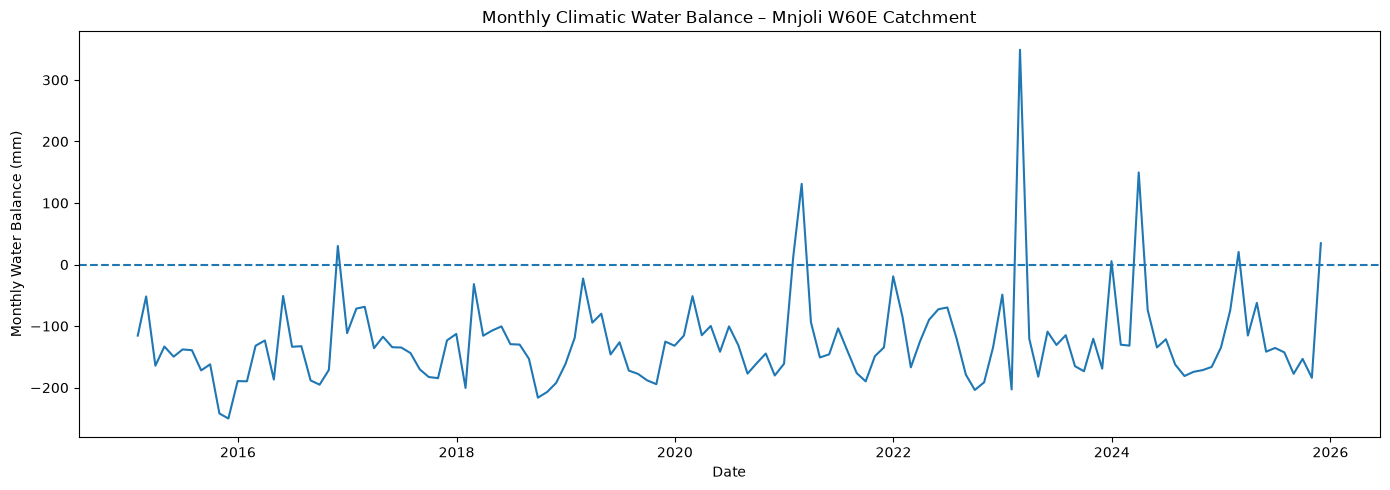

In [163]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_df["date"],
    monthly_df["water_balance_mm"]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Date")
plt.ylabel("Monthly Water Balance (mm)")
plt.title(
    "Monthly Climatic Water Balance – "
    "Mnjoli W60E Catchment"
)

plt.tight_layout()
plt.show()

In [164]:
# SPEI INPUT PREPARATION

spei_df = monthly_df[
    ["date", "precipitation_mm", "pet_mm", "water_balance_mm"]
].copy()

spei_df = spei_df.sort_values("date").reset_index(drop=True)

# Check chronological order
print("Chronological:", spei_df["date"].is_monotonic_increasing)

# Check missing values
print("\nMissing values:")
print(spei_df.isna().sum())

# Check duplicate months
print("\nDuplicate dates:", spei_df["date"].duplicated().sum())

# Display the first and last observations
print("\nFirst observations:")
print(spei_df.head())

print("\nLast observations:")
print(spei_df.tail())

Chronological: True

Missing values:
date                0
precipitation_mm    0
pet_mm              0
water_balance_mm    0
dtype: int64

Duplicate dates: 0

First observations:
        date  precipitation_mm      pet_mm  water_balance_mm
0 2015-01-31        108.399174  223.820343       -115.421169
1 2015-02-28        153.429877  205.196632        -51.766755
2 2015-03-31         66.667655  230.976277       -164.308621
3 2015-04-30         25.722274  158.938783       -133.216509
4 2015-05-31          6.401154  156.063646       -149.662492

Last observations:
          date  precipitation_mm      pet_mm  water_balance_mm
126 2025-07-31          8.930758  151.658285       -142.727527
127 2025-08-31          8.244601  185.756645       -177.512045
128 2025-09-30         47.746935  201.017186       -153.270251
129 2025-10-31         31.915177  215.955591       -184.040415
130 2025-11-30        219.932661  185.266684         34.665977


In [165]:
# MONTHLY CLIMATOLOGY OF WATER BALANCE

spei_df["month"] = spei_df["date"].dt.month

monthly_climatology = (
    spei_df
    .groupby("month")["water_balance_mm"]
    .agg(["mean", "std", "min", "max"])
)

print(monthly_climatology)

             mean         std         min         max
month                                                
1     -117.308247   64.631504 -202.942100   13.466524
2      -14.194181  145.388757 -167.005880  348.998877
3      -95.709437   83.598208 -164.308621  149.671695
4     -116.650619   42.330146 -186.818046  -62.233827
5     -120.634880   33.282783 -149.662492  -51.015553
6     -120.298158   20.942518 -137.898216  -69.695789
7     -139.036360   16.812933 -172.310539 -114.804698
8     -174.338997    9.224206 -188.298264 -153.142782
9     -181.791933   19.313912 -216.268855 -153.270251
10    -178.187001   32.895537 -242.027753 -120.577658
11    -128.266310   87.496757 -250.151592   34.665977
12    -106.550475   64.903717 -189.381432    5.501214


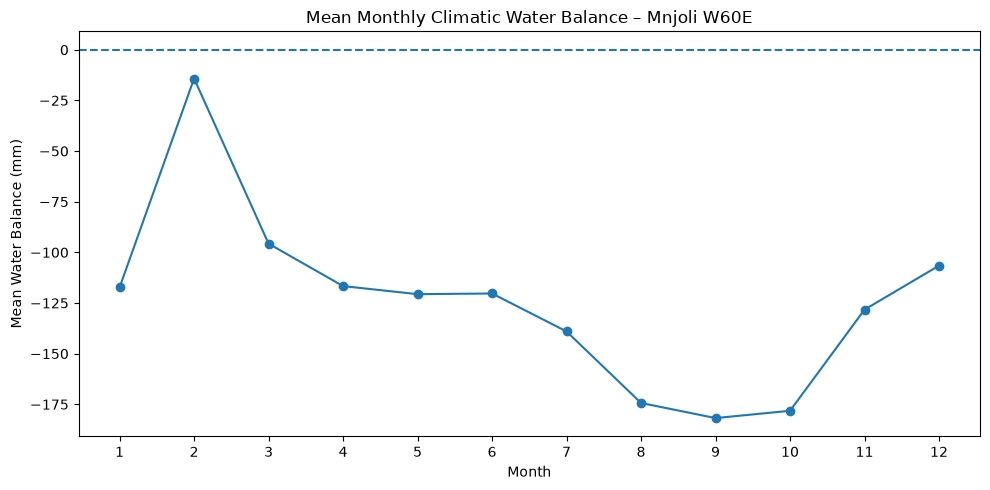

In [166]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_climatology.index,
    monthly_climatology["mean"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Mean Water Balance (mm)")
plt.title("Mean Monthly Climatic Water Balance – Mnjoli W60E")

plt.tight_layout()
plt.show()

In [167]:
# SEASONALLY STANDARDIZED WATER-BALANCE ANOMALY
# Diagnostic step before fitting the SPEI distribution

spei_df["wb_month_mean"] = (
    spei_df.groupby("month")["water_balance_mm"]
    .transform("mean")
)

spei_df["wb_month_std"] = (
    spei_df.groupby("month")["water_balance_mm"]
    .transform("std")
)

spei_df["water_balance_z"] = (
    (spei_df["water_balance_mm"] - spei_df["wb_month_mean"])
    / spei_df["wb_month_std"]
)

print(
    spei_df[
        [
            "date",
            "water_balance_mm",
            "wb_month_mean",
            "wb_month_std",
            "water_balance_z"
        ]
    ].head(12)
)

         date  water_balance_mm  wb_month_mean  wb_month_std  water_balance_z
0  2015-01-31       -115.421169    -117.308247     64.631504         0.029197
1  2015-02-28        -51.766755     -14.194181    145.388757        -0.258428
2  2015-03-31       -164.308621     -95.709437     83.598208        -0.820582
3  2015-04-30       -133.216509    -116.650619     42.330146        -0.391350
4  2015-05-31       -149.662492    -120.634880     33.282783        -0.872151
5  2015-06-30       -137.898216    -120.298158     20.942518        -0.840398
6  2015-07-31       -139.151162    -139.036360     16.812933        -0.006828
7  2015-08-31       -171.990417    -174.338997      9.224206         0.254610
8  2015-09-30       -162.089543    -181.791933     19.313912         1.020114
9  2015-10-31       -242.027753    -178.187001     32.895537        -1.940712
10 2015-11-30       -250.151592    -128.266310     87.496757        -1.393026
11 2015-12-31       -189.381432    -106.550475     64.903717    

In [168]:
print("\nStandardized anomaly statistics:")
print(spei_df["water_balance_z"].describe())

print("\nMissing values:")
print(spei_df["water_balance_z"].isna().sum())


Standardized anomaly statistics:
count    1.310000e+02
mean     2.711995e-17
std      9.567573e-01
min     -1.979082e+00
25%     -6.121718e-01
50%     -2.002913e-01
75%      4.944432e-01
max      2.935244e+00
Name: water_balance_z, dtype: float64

Missing values:
0


In [169]:
import scipy
from scipy import stats

print("SciPy:", scipy.__version__)

SciPy: 1.17.1


In [170]:
import numpy as np
from scipy import stats

def calculate_spei_1(df):
    result = df.copy()
    result["spei_1"] = np.nan

    for month in range(1, 13):

        mask = result["month"] == month
        values = result.loc[mask, "water_balance_mm"].dropna()

        # Need enough observations for a meaningful distribution
        if len(values) < 5:
            continue

        # Fit a log-logistic distribution through scipy's
        # Fisk distribution (log-logistic)
        shape, loc, scale = stats.fisk.fit(values)

        # Calculate cumulative probabilities
        cdf_values = stats.fisk.cdf(
            result.loc[mask, "water_balance_mm"],
            shape,
            loc=loc,
            scale=scale
        )

        # Avoid probabilities of exactly 0 or 1
        cdf_values = np.clip(cdf_values, 1e-6, 1 - 1e-6)

        # Convert cumulative probability to standard-normal variate
        result.loc[mask, "spei_1"] = stats.norm.ppf(cdf_values)

    return result


spei_df = calculate_spei_1(spei_df)

print(
    spei_df[
        ["date", "water_balance_mm", "spei_1"]
    ].head(12)
)

         date  water_balance_mm    spei_1
0  2015-01-31       -115.421169  0.873687
1  2015-02-28        -51.766755  1.038839
2  2015-03-31       -164.308621 -4.753424
3  2015-04-30       -133.216509  0.779035
4  2015-05-31       -149.662492 -4.753424
5  2015-06-30       -137.898216 -4.753424
6  2015-07-31       -139.151162  0.815610
7  2015-08-31       -171.990417  0.805536
8  2015-09-30       -162.089543  0.971923
9  2015-10-31       -242.027753 -4.644395
10 2015-11-30       -250.151592 -3.085244
11 2015-12-31       -189.381432 -4.409046


In [171]:
print("\nSPEI-1 statistics:")
print(spei_df["spei_1"].describe())

print("\nMissing SPEI values:")
print(spei_df["spei_1"].isna().sum())

print("\nExtreme SPEI values:")
print(
    spei_df.loc[
        spei_df["spei_1"].abs() >= 2,
        ["date", "water_balance_mm", "spei_1"]
    ]
)


SPEI-1 statistics:
count    131.000000
mean       0.349400
std        1.561356
min       -4.753424
25%        0.600027
50%        0.863885
75%        0.971252
max        1.539245
Name: spei_1, dtype: float64

Missing SPEI values:
0

Extreme SPEI values:
         date  water_balance_mm    spei_1
2  2015-03-31       -164.308621 -4.753424
4  2015-05-31       -149.662492 -4.753424
5  2015-06-30       -137.898216 -4.753424
9  2015-10-31       -242.027753 -4.644395
10 2015-11-30       -250.151592 -3.085244
11 2015-12-31       -189.381432 -4.409046
15 2016-04-30       -186.818046 -4.344259
19 2016-08-31       -188.298264 -4.753424
44 2018-09-30       -216.268855 -4.753424
54 2019-07-31       -172.310539 -4.741921
85 2022-02-28       -167.005880 -4.516919
96 2023-01-31       -202.942100 -4.141042


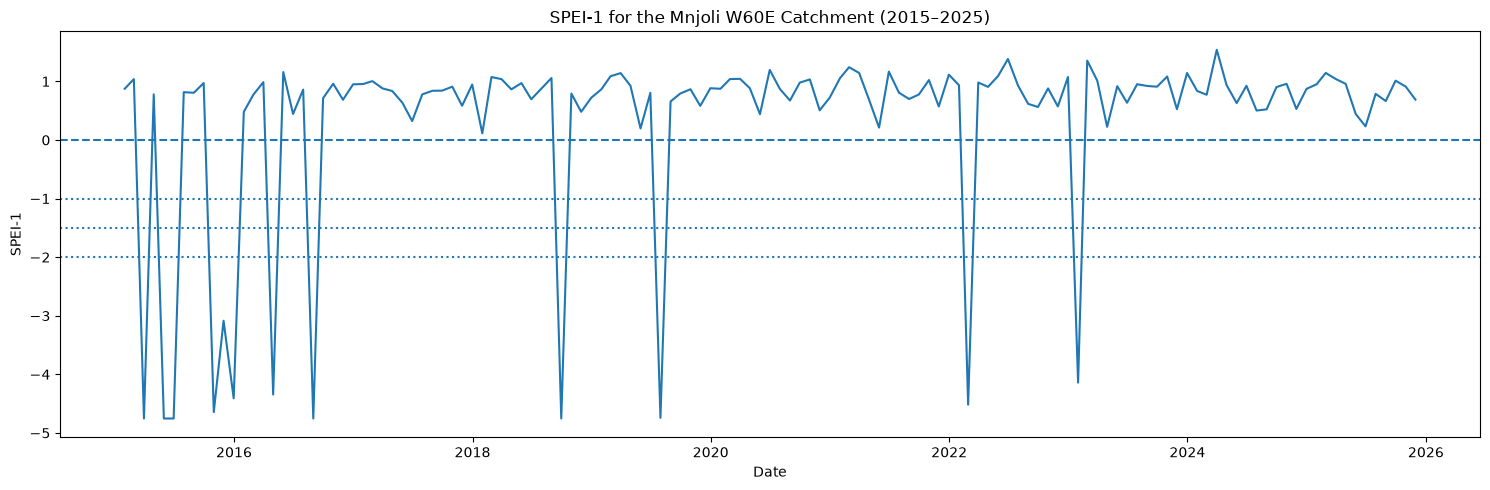

In [172]:
plt.figure(figsize=(15, 5))

plt.plot(
    spei_df["date"],
    spei_df["spei_1"]
)

plt.axhline(0, linestyle="--")
plt.axhline(-1, linestyle=":")
plt.axhline(-1.5, linestyle=":")
plt.axhline(-2, linestyle=":")

plt.xlabel("Date")
plt.ylabel("SPEI-1")
plt.title(
    "SPEI-1 for the Mnjoli W60E Catchment "
    "(2015–2025)"
)

plt.tight_layout()
plt.show()

In [173]:
# Diagnose the suspicious SPEI values

print(
    spei_df[
        ["date", "month", "water_balance_mm", "spei_1"]
    ].sort_values("spei_1").head(20)
)

          date  month  water_balance_mm    spei_1
2   2015-03-31      3       -164.308621 -4.753424
4   2015-05-31      5       -149.662492 -4.753424
5   2015-06-30      6       -137.898216 -4.753424
19  2016-08-31      8       -188.298264 -4.753424
44  2018-09-30      9       -216.268855 -4.753424
54  2019-07-31      7       -172.310539 -4.741921
9   2015-10-31     10       -242.027753 -4.644395
85  2022-02-28      2       -167.005880 -4.516919
11  2015-12-31     12       -189.381432 -4.409046
15  2016-04-30      4       -186.818046 -4.344259
96  2023-01-31      1       -202.942100 -4.141042
10  2015-11-30     11       -250.151592 -3.085244
36  2018-01-31      1       -200.448792  0.112764
52  2019-05-31      5       -146.027673  0.197153
76  2021-05-31      5       -145.862570  0.210968
99  2023-04-30      4       -182.229221  0.224217
125 2025-06-30      6       -135.463583  0.231872
29  2017-06-30      6       -134.803157  0.322279
64  2020-05-31      5       -141.673269  0.439935


In [174]:
print("\nSPEI values by calendar month:")

print(
    spei_df.groupby("month")["spei_1"]
    .agg(["count", "mean", "std", "min", "max"])
)


SPEI values by calendar month:
       count      mean       std       min       max
month                                               
1         11  0.344640  1.511717 -4.141042  1.052373
2         11  0.546281  1.688129 -4.516919  1.354094
3         11  0.549701  1.766983 -4.753424  1.539245
4         11  0.332739  1.564891 -4.344259  0.958147
5         11  0.176696  1.668788 -4.753424  1.159245
6         11  0.277007  1.708587 -4.753424  1.381739
7         11  0.312061  1.680395 -4.741921  0.951320
8         11  0.245763  1.664928 -4.753424  1.057346
9         11  0.337188  1.693500 -4.753424  1.011993
10        11  0.433703  1.686279 -4.644395  1.083251
11        11  0.239989  1.104826 -3.085244  0.688281
12        10  0.401802  1.696659 -4.409046  1.142554


In [175]:
print("\nUnique extreme lower-tail values:")

print(
    spei_df.loc[
        spei_df["spei_1"] < -4,
        ["date", "month", "water_balance_mm", "spei_1"]
    ]
)


Unique extreme lower-tail values:
         date  month  water_balance_mm    spei_1
2  2015-03-31      3       -164.308621 -4.753424
4  2015-05-31      5       -149.662492 -4.753424
5  2015-06-30      6       -137.898216 -4.753424
9  2015-10-31     10       -242.027753 -4.644395
11 2015-12-31     12       -189.381432 -4.409046
15 2016-04-30      4       -186.818046 -4.344259
19 2016-08-31      8       -188.298264 -4.753424
44 2018-09-30      9       -216.268855 -4.753424
54 2019-07-31      7       -172.310539 -4.741921
85 2022-02-28      2       -167.005880 -4.516919
96 2023-01-31      1       -202.942100 -4.141042


In [176]:
import numpy as np
import pandas as pd
from scipy.stats import norm

spei_df = spei_df.sort_values("date").copy()

# Calculate empirical percentile within the complete historical
# water-balance series
n = spei_df["water_balance_mm"].notna().sum()

spei_df["water_balance_rank"] = (
    spei_df["water_balance_mm"]
    .rank(method="average")
)

# Plotting-position adjustment
spei_df["water_balance_probability"] = (
    spei_df["water_balance_rank"] - 0.44
) / (n + 0.12)

# Keep probabilities safely away from 0 and 1
spei_df["water_balance_probability"] = (
    spei_df["water_balance_probability"]
    .clip(0.001, 0.999)
)

# Convert probability to standard-normal score
spei_df["spei_1_empirical"] = norm.ppf(
    spei_df["water_balance_probability"]
)

print(
    spei_df[
        ["date", "water_balance_mm", "spei_1_empirical"]
    ].head(12)
)

         date  water_balance_mm  spei_1_empirical
0  2015-01-31       -115.421169          0.541499
1  2015-02-28        -51.766755          1.220998
2  2015-03-31       -164.308621         -0.519493
3  2015-04-30       -133.216509          0.076543
4  2015-05-31       -149.662492         -0.330932
5  2015-06-30       -137.898216         -0.114955
6  2015-07-31       -139.151162         -0.134221
7  2015-08-31       -171.990417         -0.704067
8  2015-09-30       -162.089543         -0.476212
9  2015-10-31       -242.027753         -2.260423
10 2015-11-30       -250.151592         -2.629868
11 2015-12-31       -189.381432         -1.262321


In [177]:
print("\nEmpirical SPEI-1 statistics:")

print(
    spei_df["spei_1_empirical"].describe()
)

print("\nMissing values:")

print(
    spei_df["spei_1_empirical"].isna().sum()
)


Empirical SPEI-1 statistics:
count    1.310000e+02
mean    -6.779988e-17
std      9.951713e-01
min     -2.629868e+00
25%     -6.678326e-01
50%      0.000000e+00
75%      6.678326e-01
max      2.629868e+00
Name: spei_1_empirical, dtype: float64

Missing values:
0


In [178]:
print(
    spei_df[
        ["date", "water_balance_mm", "spei_1_empirical"]
    ]
    .sort_values("spei_1_empirical")
    .head(10)
)

         date  water_balance_mm  spei_1_empirical
10 2015-11-30       -250.151592         -2.629868
9  2015-10-31       -242.027753         -2.260423
44 2018-09-30       -216.268855         -2.063679
45 2018-10-31       -206.992009         -1.924424
92 2022-09-30       -203.800515         -1.814800
96 2023-01-31       -202.942100         -1.723447
36 2018-01-31       -200.448792         -1.644558
20 2016-09-30       -195.175005         -1.574750
57 2019-10-31       -194.356857         -1.511868
46 2018-11-30       -192.340841         -1.454453


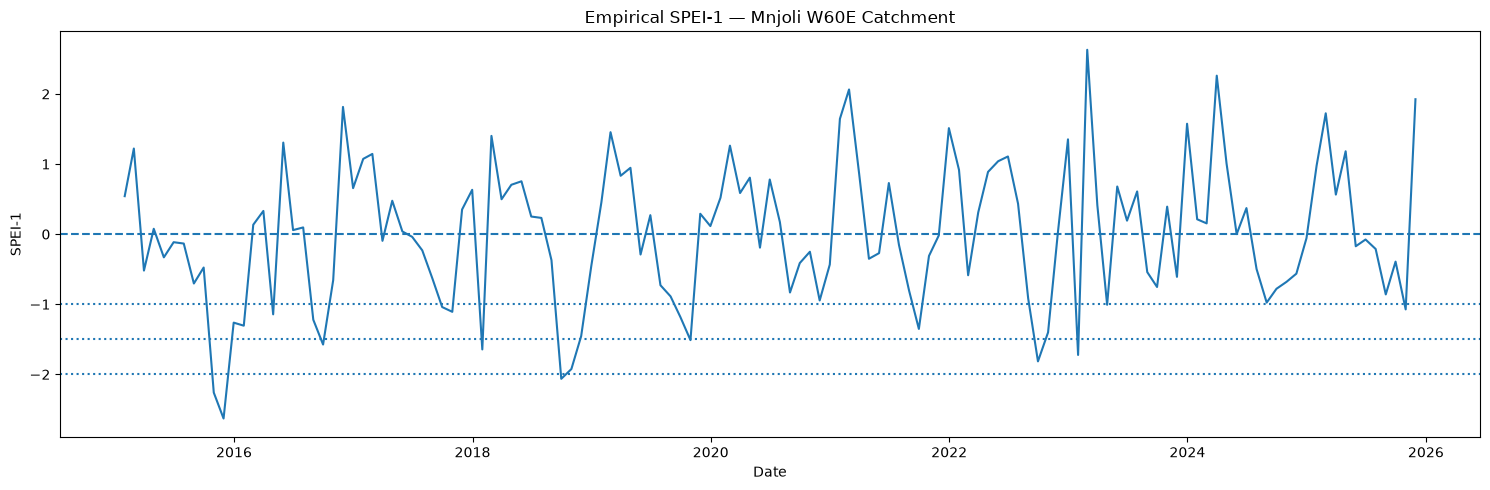

In [179]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    spei_df["date"],
    spei_df["spei_1_empirical"]
)

plt.axhline(0, linestyle="--")
plt.axhline(-1, linestyle=":")
plt.axhline(-1.5, linestyle=":")
plt.axhline(-2, linestyle=":")

plt.xlabel("Date")
plt.ylabel("SPEI-1")
plt.title(
    "Empirical SPEI-1 — Mnjoli W60E Catchment"
)

plt.tight_layout()
plt.show()

In [180]:
# Create 3-month accumulated water balance

spei_df = spei_df.sort_values("date").copy()

spei_df["water_balance_3month"] = (
    spei_df["water_balance_mm"]
    .rolling(window=3, min_periods=3)
    .sum()
)

print(
    spei_df[
        [
            "date",
            "water_balance_mm",
            "water_balance_3month"
        ]
    ].head(15)
)

         date  water_balance_mm  water_balance_3month
0  2015-01-31       -115.421169                   NaN
1  2015-02-28        -51.766755                   NaN
2  2015-03-31       -164.308621           -331.496546
3  2015-04-30       -133.216509           -349.291885
4  2015-05-31       -149.662492           -447.187622
5  2015-06-30       -137.898216           -420.777217
6  2015-07-31       -139.151162           -426.711869
7  2015-08-31       -171.990417           -449.039795
8  2015-09-30       -162.089543           -473.231122
9  2015-10-31       -242.027753           -576.107714
10 2015-11-30       -250.151592           -654.268889
11 2015-12-31       -189.381432           -681.560778
12 2016-01-31       -189.695337           -629.228362
13 2016-02-29       -131.893954           -510.970724
14 2016-03-31       -123.428343           -445.017634


In [181]:
print("\nSPEI-3 input statistics:")

print(
    spei_df["water_balance_3month"].describe()
)

print("\nMissing 3-month values:")

print(
    spei_df["water_balance_3month"].isna().sum()
)


SPEI-3 input statistics:
count    129.000000
mean    -376.363789
std      145.164816
min     -681.560778
25%     -473.231122
50%     -389.838922
75%     -303.268801
max       97.232377
Name: water_balance_3month, dtype: float64

Missing 3-month values:
2


In [182]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nContents of current directory:")
print(os.listdir())

Current working directory:
c:\Users\Para\Desktop\Eswatini_Water_Stress_ML\notebooks

Contents of current directory:
['01_data_acquisition.ipynb']


In [183]:
import os

project = r"C:\Users\Para\Desktop\Eswatini_Water_Stress_ML"

print("Project exists:", os.path.exists(project))
print("\nProject contents:")

for item in os.listdir(project):
    print(item)

Project exists: True

Project contents:
.ipynb_checkpoints
.kilo
.venv
data
models
notebooks
results
src
Untitled.ipynb


In [184]:
data_path = r"C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data"

print("Data folder exists:", os.path.exists(data_path))

if os.path.exists(data_path):
    print("\nData contents:")
    for item in os.listdir(data_path):
        print(item)

Data folder exists: True

Data contents:
external
processed
raw


In [185]:
import os

project = r"C:\Users\Para\Desktop\Eswatini_Water_Stress_ML"

print("CSV files found:\n")

for root, dirs, files in os.walk(project):
    for file in files:
        if file.lower().endswith(".csv"):
            print(os.path.join(root, file))

CSV files found:

C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\.venv\Lib\site-packages\fiona\gdal_data\grib2_center.csv
C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\.venv\Lib\site-packages\fiona\gdal_data\grib2_process.csv
C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\.venv\Lib\site-packages\fiona\gdal_data\grib2_subcenter.csv
C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\.venv\Lib\site-packages\fiona\gdal_data\grib2_table_4_2_0_0.csv
C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\.venv\Lib\site-packages\fiona\gdal_data\grib2_table_4_2_0_1.csv
C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\.venv\Lib\site-packages\fiona\gdal_data\grib2_table_4_2_0_13.csv
C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\.venv\Lib\site-packages\fiona\gdal_data\grib2_table_4_2_0_14.csv
C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\.venv\Lib\site-packages\fiona\gdal_data\grib2_table_4_2_0_15.csv
C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\.venv\Lib\site-packages\fiona\gdal_data\grib2_table_4_2_0_16.

In [186]:
import pandas as pd
import numpy as np

project = r"C:\Users\Para\Desktop\Eswatini_Water_Stress_ML"

chirps_path = project + r"\data\external\mnjoli_chirps_daily_2015_2025.csv"
era5_path = project + r"\data\external\mnjoli_era5_land_daily_2015_2025_processed.csv"

df_chirps = pd.read_csv(chirps_path, parse_dates=["date"])
df_era5 = pd.read_csv(era5_path, parse_dates=["date"])

print("CHIRPS:", df_chirps.shape)
print("ERA5:", df_era5.shape)

print("\nCHIRPS columns:")
print(df_chirps.columns.tolist())

print("\nERA5 columns:")
print(df_era5.columns.tolist())

CHIRPS: (4017, 2)
ERA5: (4017, 16)

CHIRPS columns:
['date', 'precipitation_mm']

ERA5 columns:
['date', 'dewpoint_temperature_2m', 'potential_evaporation_sum', 'runoff_sum', 'surface_pressure', 'surface_runoff_sum', 'surface_solar_radiation_downwards_sum', 'temperature_2m', 'temperature_2m_max', 'temperature_2m_min', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2', 'pet_m', 'pet_mm']


In [187]:
import pandas as pd
from pathlib import Path

# Project root = one level above notebooks/
PROJECT_ROOT = Path.cwd().parent

# Correct data paths
chirps_path = PROJECT_ROOT / "data" / "external" / "mnjoli_chirps_daily_2015_2025.csv"
era5_path = PROJECT_ROOT / "data" / "external" / "mnjoli_era5_land_daily_2015_2025_processed.csv"

print("Project root:", PROJECT_ROOT)
print("CHIRPS:", chirps_path)
print("ERA5:", era5_path)

# Check that files exist
print("\nCHIRPS exists:", chirps_path.exists())
print("ERA5 exists:", era5_path.exists())

# Load data
df_chirps = pd.read_csv(chirps_path)
df_era5 = pd.read_csv(era5_path)

# Convert dates
df_chirps["date"] = pd.to_datetime(df_chirps["date"])
df_era5["date"] = pd.to_datetime(df_era5["date"])

print("\nCHIRPS:", df_chirps.shape)
print("ERA5:", df_era5.shape)

print("\nCHIRPS columns:")
print(df_chirps.columns.tolist())

print("\nERA5 columns:")
print(df_era5.columns.tolist())

Project root: c:\Users\Para\Desktop\Eswatini_Water_Stress_ML
CHIRPS: c:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data\external\mnjoli_chirps_daily_2015_2025.csv
ERA5: c:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data\external\mnjoli_era5_land_daily_2015_2025_processed.csv

CHIRPS exists: True
ERA5 exists: True

CHIRPS: (4017, 2)
ERA5: (4017, 16)

CHIRPS columns:
['date', 'precipitation_mm']

ERA5 columns:
['date', 'dewpoint_temperature_2m', 'potential_evaporation_sum', 'runoff_sum', 'surface_pressure', 'surface_runoff_sum', 'surface_solar_radiation_downwards_sum', 'temperature_2m', 'temperature_2m_max', 'temperature_2m_min', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2', 'pet_m', 'pet_mm']


In [188]:
import pandas as pd
from pathlib import Path

# ============================================================
# LOAD CHIRPS + ERA5
# ============================================================

PROJECT_ROOT = Path(r"C:\Users\Para\Desktop\Eswatini_Water_Stress_ML")

chirps_path = PROJECT_ROOT / "data" / "external" / "mnjoli_chirps_daily_2015_2025.csv"
era5_path = PROJECT_ROOT / "data" / "external" / "mnjoli_era5_land_daily_2015_2025_processed.csv"

df_chirps = pd.read_csv(chirps_path)
df_era5 = pd.read_csv(era5_path)

# Convert dates
df_chirps["date"] = pd.to_datetime(df_chirps["date"])
df_era5["date"] = pd.to_datetime(df_era5["date"])

# ============================================================
# MERGE
# ============================================================

df_daily = pd.merge(
    df_chirps,
    df_era5,
    on="date",
    how="inner"
)

# Sort chronologically
df_daily = df_daily.sort_values("date").reset_index(drop=True)

print("Combined dataset shape:", df_daily.shape)

print("\nDate range:")
print(df_daily["date"].min(), "to", df_daily["date"].max())

print("\nColumns:")
print(df_daily.columns.tolist())

print("\nMissing values:")
print(df_daily.isna().sum())

Combined dataset shape: (4017, 17)

Date range:
2015-01-01 00:00:00 to 2025-12-30 00:00:00

Columns:
['date', 'precipitation_mm', 'dewpoint_temperature_2m', 'potential_evaporation_sum', 'runoff_sum', 'surface_pressure', 'surface_runoff_sum', 'surface_solar_radiation_downwards_sum', 'temperature_2m', 'temperature_2m_max', 'temperature_2m_min', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2', 'pet_m', 'pet_mm']

Missing values:
date                                     0
precipitation_mm                         0
dewpoint_temperature_2m                  0
potential_evaporation_sum                0
runoff_sum                               0
surface_pressure                         0
surface_runoff_sum                       0
surface_solar_radiation_downwards_sum    0
temperature_2m                           0
temperature_2m_max                       0
temperature_2m_min                       0
u_component_of_wind_10m   

In [189]:
# ============================================================
# CREATE HYDROCLIMATIC FEATURES
# ============================================================

df_daily["year"] = df_daily["date"].dt.year
df_daily["month"] = df_daily["date"].dt.month
df_daily["day_of_year"] = df_daily["date"].dt.dayofyear

# Temperature in Celsius
df_daily["temperature_c"] = df_daily["temperature_2m"] - 273.15
df_daily["temperature_min_c"] = df_daily["temperature_2m_min"] - 273.15
df_daily["temperature_max_c"] = df_daily["temperature_2m_max"] - 273.15
df_daily["dewpoint_c"] = df_daily["dewpoint_temperature_2m"] - 273.15

# Wind speed
df_daily["wind_speed"] = (
    df_daily["u_component_of_wind_10m"]**2 +
    df_daily["v_component_of_wind_10m"]**2
)**0.5

# Pressure in kPa
df_daily["surface_pressure_kpa"] = (
    df_daily["surface_pressure"] / 1000
)

print(df_daily.head())

print("\nFeature dataset shape:", df_daily.shape)

        date  precipitation_mm  dewpoint_temperature_2m  \
0 2015-01-01               0.0               291.253237   
1 2015-01-02               0.0               292.773722   
2 2015-01-03               0.0               293.917622   
3 2015-01-04               0.0               293.504903   
4 2015-01-05               0.0               292.642278   

   potential_evaporation_sum    runoff_sum  surface_pressure  \
0                  -0.005317  1.095235e-05      96857.947005   
1                  -0.006181  1.488502e-06      96789.007270   
2                  -0.006040  1.264124e-06      96780.185422   
3                  -0.007706  7.396248e-07      96754.536558   
4                  -0.009745  4.335323e-07      96622.785307   

   surface_runoff_sum  surface_solar_radiation_downwards_sum  temperature_2m  \
0        1.056180e-05                           1.638664e+07      295.476449   
1        1.092895e-06                           1.877256e+07      296.835059   
2        8.603941e-0

In [190]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# REBUILD DAILY FEATURE DATASET
# ============================================================

project_root = Path(r"C:\Users\Para\Desktop\Eswatini_Water_Stress_ML")

chirps_path = project_root / "data" / "external" / "mnjoli_chirps_daily_2015_2025.csv"
era5_path = project_root / "data" / "external" / "mnjoli_era5_land_daily_2015_2025_processed.csv"

# Load datasets
df_chirps = pd.read_csv(chirps_path)
df_era5 = pd.read_csv(era5_path)

# Convert dates
df_chirps["date"] = pd.to_datetime(df_chirps["date"])
df_era5["date"] = pd.to_datetime(df_era5["date"])

# Merge
df_features = pd.merge(
    df_chirps,
    df_era5,
    on="date",
    how="inner"
)

# ============================================================
# ADD DERIVED FEATURES
# ============================================================

# Calendar features
df_features["year"] = df_features["date"].dt.year
df_features["month"] = df_features["date"].dt.month
df_features["day_of_year"] = df_features["date"].dt.dayofyear

# Temperature conversions
df_features["temperature_c"] = (
    df_features["temperature_2m"] - 273.15
)

df_features["temperature_min_c"] = (
    df_features["temperature_2m_min"] - 273.15
)

df_features["temperature_max_c"] = (
    df_features["temperature_2m_max"] - 273.15
)

df_features["dewpoint_c"] = (
    df_features["dewpoint_temperature_2m"] - 273.15
)

# Wind speed
df_features["wind_speed"] = np.sqrt(
    df_features["u_component_of_wind_10m"]**2 +
    df_features["v_component_of_wind_10m"]**2
)

# Pressure in kPa
df_features["surface_pressure_kpa"] = (
    df_features["surface_pressure"] / 1000
)

# ============================================================
# CHECK
# ============================================================

print("Feature dataset shape:", df_features.shape)

print("\nColumns:")
print(df_features.columns.tolist())

print("\nMissing values:")
print(df_features.isna().sum().sum())

display(df_features.head())

Feature dataset shape: (4017, 26)

Columns:
['date', 'precipitation_mm', 'dewpoint_temperature_2m', 'potential_evaporation_sum', 'runoff_sum', 'surface_pressure', 'surface_runoff_sum', 'surface_solar_radiation_downwards_sum', 'temperature_2m', 'temperature_2m_max', 'temperature_2m_min', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2', 'pet_m', 'pet_mm', 'year', 'month', 'day_of_year', 'temperature_c', 'temperature_min_c', 'temperature_max_c', 'dewpoint_c', 'wind_speed', 'surface_pressure_kpa']

Missing values:
0


,date,precipitation_mm,dewpoint_temperature_2m,potential_evaporation_sum,runoff_sum,surface_pressure,surface_runoff_sum,surface_solar_radiation_downwards_sum,temperature_2m,temperature_2m_max,...,pet_mm,year,month,day_of_year,temperature_c,temperature_min_c,temperature_max_c,dewpoint_c,wind_speed,surface_pressure_kpa
0,2015-01-01,0.0,291.253237,-0.005317,1.095235e-05,96857.947005,1.056180e-05,1.638664e+07,295.476449,299.686881,...,5.316992,2015,1,1,22.326449,19.471557,26.536881,18.103237,1.803615,96.857947
1,2015-01-02,0.0,292.773722,-0.006181,1.488502e-06,96789.007270,1.092895e-06,1.877256e+07,296.835059,301.037762,...,6.180669,2015,1,2,23.685059,19.882143,27.887762,19.623722,2.106165,96.789007
2,2015-01-03,0.0,293.917622,-0.006040,1.264124e-06,96780.185422,8.603941e-07,1.943779e+07,297.639751,302.467197,...,6.040124,2015,1,3,24.489751,20.370614,29.317197,20.767622,1.825774,96.780185
3,2015-01-04,0.0,293.504903,-0.007706,7.396248e-07,96754.536558,3.278793e-07,2.593199e+07,298.456794,303.712293,...,7.706183,2015,1,4,25.306794,21.499785,30.562293,20.354903,1.400170,96.754537
4,2015-01-05,0.0,292.642278,-0.009745,4.335323e-07,96622.785307,3.502042e-08,2.949817e+07,299.187555,305.122049,...,9.745081,2015,1,5,26.037555,21.028642,31.972049,19.492278,1.727800,96.622785


In [191]:
# ============================================================
# SAVE DAILY FEATURE DATASET
# ============================================================

output_path = (
    project_root
    / "data"
    / "processed"
    / "mnjoli_water_stress_features_daily.csv"
)

output_path.parent.mkdir(parents=True, exist_ok=True)

df_features.to_csv(output_path, index=False)

print("Saved successfully!")
print("File:", output_path)
print("Shape:", df_features.shape)

Saved successfully!
File: C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data\processed\mnjoli_water_stress_features_daily.csv
Shape: (4017, 26)


In [192]:
# ============================================================
# LOAD DAILY FEATURE DATASET
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

project_root = Path(r"C:\Users\Para\Desktop\Eswatini_Water_Stress_ML")

features_path = (
    project_root
    / "data"
    / "processed"
    / "mnjoli_water_stress_features_daily.csv"
)

df = pd.read_csv(features_path, parse_dates=["date"])

print("Loaded:", features_path)
print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

Loaded: C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data\processed\mnjoli_water_stress_features_daily.csv
Shape: (4017, 26)
Date range: 2015-01-01 00:00:00 to 2025-12-30 00:00:00


In [193]:
# ============================================================
# RECREATE MONTHLY WATER BALANCE
# ============================================================

df_monthly = (
    df.set_index("date")
      .resample("ME")
      .agg({
          "precipitation_mm": "sum",
          "pet_mm": "sum"
      })
      .reset_index()
)

df_monthly["water_balance_mm"] = (
    df_monthly["precipitation_mm"]
    - df_monthly["pet_mm"]
)

print("Monthly observations:", len(df_monthly))
display(df_monthly.head(12))

Monthly observations: 132


,date,precipitation_mm,pet_mm,water_balance_mm
0,2015-01-31,108.399174,223.820343,-115.421169
1,2015-02-28,153.429877,205.196632,-51.766755
2,2015-03-31,66.667655,230.976277,-164.308621
3,2015-04-30,25.722274,158.938783,-133.216509
4,2015-05-31,6.401154,156.063646,-149.662492
5,2015-06-30,6.331618,144.229834,-137.898216
6,2015-07-31,10.037668,149.188829,-139.151162
7,2015-08-31,8.076374,180.066791,-171.990417
8,2015-09-30,33.993718,196.083262,-162.089543
9,2015-10-31,33.239156,275.266909,-242.027753


In [194]:
print("\nWater balance statistics:")
print(df_monthly["water_balance_mm"].describe())

print("\nMissing values:")
print(df_monthly["water_balance_mm"].isna().sum())


Water balance statistics:
count    132.000000
mean    -123.957891
std       75.188612
min     -250.151592
25%     -171.233537
50%     -134.557556
75%     -108.552058
max      348.998877
Name: water_balance_mm, dtype: float64

Missing values:
0


In [195]:
# ============================================================
# CREATE MONTHLY WATER-STRESS DATASET
# ============================================================

import pandas as pd
from pathlib import Path

project_root = Path(r"C:\Users\Para\Desktop\Eswatini_Water_Stress_ML")

daily_path = (
    project_root
    / "data"
    / "processed"
    / "mnjoli_water_stress_features_daily.csv"
)

monthly_output = (
    project_root
    / "data"
    / "processed"
    / "mnjoli_water_stress_monthly.csv"
)

# Load daily features
df = pd.read_csv(daily_path)

df["date"] = pd.to_datetime(df["date"])

# Sort chronologically
df = df.sort_values("date").reset_index(drop=True)

# Create monthly period
df["month_date"] = df["date"].dt.to_period("M").dt.to_timestamp()

# ============================================================
# MONTHLY AGGREGATION
# ============================================================

monthly = (
    df.groupby("month_date")
    .agg(
        precipitation_mm=("precipitation_mm", "sum"),
        pet_mm=("pet_mm", "sum"),

        temperature_mean_c=("temperature_c", "mean"),
        temperature_min_c=("temperature_min_c", "mean"),
        temperature_max_c=("temperature_max_c", "mean"),

        dewpoint_c=("dewpoint_c", "mean"),

        soil_moisture_layer1=(
            "volumetric_soil_water_layer_1",
            "mean"
        ),

        soil_moisture_layer2=(
            "volumetric_soil_water_layer_2",
            "mean"
        ),

        runoff_mm=("runoff_sum", "sum"),
        surface_runoff_mm=("surface_runoff_sum", "sum"),

        solar_radiation=(
            "surface_solar_radiation_downwards_sum",
            "mean"
        ),

        wind_speed=("wind_speed", "mean"),

        surface_pressure_kpa=(
            "surface_pressure_kpa",
            "mean"
        )
    )
    .reset_index()
)

# ============================================================
# WATER BALANCE
# ============================================================

monthly["water_balance_mm"] = (
    monthly["precipitation_mm"]
    - monthly["pet_mm"]
)

# ============================================================
# 3-MONTH WATER BALANCE
# ============================================================

monthly["water_balance_3month"] = (
    monthly["water_balance_mm"]
    .rolling(window=3)
    .sum()
)

# ============================================================
# 6-MONTH WATER BALANCE
# ============================================================

monthly["water_balance_6month"] = (
    monthly["water_balance_mm"]
    .rolling(window=6)
    .sum()
)

# ============================================================
# CALENDAR FEATURES
# ============================================================

monthly["year"] = monthly["month_date"].dt.year
monthly["month"] = monthly["month_date"].dt.month

# Season in Eswatini
def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

monthly["season"] = monthly["month"].apply(get_season)

# ============================================================
# CHECK
# ============================================================

print("Monthly dataset shape:", monthly.shape)

print("\nDate range:")
print(monthly["month_date"].min(), "to", monthly["month_date"].max())

print("\nMissing values:")
print(monthly.isna().sum())

print("\nFirst observations:")
display(monthly.head())

# ============================================================
# SAVE
# ============================================================

monthly_output.parent.mkdir(parents=True, exist_ok=True)

monthly.to_csv(monthly_output, index=False)

print("\nSaved successfully:")
print(monthly_output)

Monthly dataset shape: (132, 20)

Date range:
2015-01-01 00:00:00 to 2025-12-01 00:00:00

Missing values:
month_date              0
precipitation_mm        0
pet_mm                  0
temperature_mean_c      0
temperature_min_c       0
temperature_max_c       0
dewpoint_c              0
soil_moisture_layer1    0
soil_moisture_layer2    0
runoff_mm               0
surface_runoff_mm       0
solar_radiation         0
wind_speed              0
surface_pressure_kpa    0
water_balance_mm        0
water_balance_3month    2
water_balance_6month    5
year                    0
month                   0
season                  0
dtype: int64

First observations:


,month_date,precipitation_mm,pet_mm,temperature_mean_c,temperature_min_c,temperature_max_c,dewpoint_c,soil_moisture_layer1,soil_moisture_layer2,runoff_mm,surface_runoff_mm,solar_radiation,wind_speed,surface_pressure_kpa,water_balance_mm,water_balance_3month,water_balance_6month,year,month,season
0,2015-01-01,108.399174,223.820343,24.244754,20.536907,29.074656,19.159322,0.254893,0.247987,0.000448,0.000436,2.080123e+07,1.792599,97.009791,-115.421169,NaN,NaN,2015,1,Summer
1,2015-02-01,153.429877,205.196632,24.368461,19.930770,29.984754,18.570688,0.224155,0.216465,0.001506,0.001496,1.991791e+07,1.525280,96.886179,-51.766755,NaN,NaN,2015,2,Summer
2,2015-03-01,66.667655,230.976277,24.528914,19.785820,30.321264,16.856486,0.150096,0.165199,0.000093,0.000083,1.899828e+07,1.499579,97.252747,-164.308621,-331.496546,NaN,2015,3,Autumn
3,2015-04-01,25.722274,158.938783,21.506630,17.276988,26.593867,15.441193,0.193402,0.175428,0.001043,0.001034,1.379342e+07,1.319609,97.352107,-133.216509,-349.291885,NaN,2015,4,Autumn
4,2015-05-01,6.401154,156.063646,20.217188,14.224896,26.989467,13.045341,0.155295,0.184315,0.000055,0.000046,1.443251e+07,1.215148,97.510695,-149.662492,-447.187622,NaN,2015,5,Autumn



Saved successfully:
C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data\processed\mnjoli_water_stress_monthly.csv


In [196]:
# ============================================================
# WATER-STRESS INDEX — 3-MONTH STANDARDIZED WATER BALANCE
# ============================================================

import numpy as np
import pandas as pd

# Load monthly dataset
monthly_path = (
    project_root
    / "data"
    / "processed"
    / "mnjoli_water_stress_monthly.csv"
)

df_monthly = pd.read_csv(monthly_path)

df_monthly["month_date"] = pd.to_datetime(df_monthly["month_date"])

# Make sure chronological
df_monthly = (
    df_monthly
    .sort_values("month_date")
    .reset_index(drop=True)
)

# ============================================================
# CALCULATE 3-MONTH WATER BALANCE
# ============================================================

df_monthly["water_balance_3month"] = (
    df_monthly["water_balance_mm"]
    .rolling(window=3)
    .sum()
)

# ============================================================
# STANDARDIZE BY CALENDAR MONTH
# ============================================================

df_monthly["calendar_month"] = (
    df_monthly["month_date"].dt.month
)

monthly_stats = (
    df_monthly
    .groupby("calendar_month")["water_balance_3month"]
    .agg(["mean", "std"])
    .reset_index()
)

monthly_stats = monthly_stats.rename(
    columns={
        "mean": "wb3_mean",
        "std": "wb3_std"
    }
)

df_monthly = df_monthly.merge(
    monthly_stats,
    on="calendar_month",
    how="left"
)

# ============================================================
# STANDARDIZED WATER-STRESS INDEX
# ============================================================

df_monthly["water_stress_index"] = (
    df_monthly["water_balance_3month"]
    - df_monthly["wb3_mean"]
) / df_monthly["wb3_std"]

# ============================================================
# CLASSIFY WATER STRESS
# ============================================================

def classify_stress(x):

    if pd.isna(x):
        return "Insufficient data"

    elif x <= -2:
        return "Extreme stress"

    elif x <= -1.5:
        return "Severe stress"

    elif x <= -1:
        return "Moderate stress"

    elif x < 0:
        return "Mild stress"

    elif x < 1:
        return "Normal"

    else:
        return "Above normal"

df_monthly["water_stress_class"] = (
    df_monthly["water_stress_index"]
    .apply(classify_stress)
)

# ============================================================
# VALIDATION
# ============================================================

print("Water-stress dataset shape:")
print(df_monthly.shape)

print("\nMissing water-stress index:")
print(df_monthly["water_stress_index"].isna().sum())

print("\nWater-stress index statistics:")
print(df_monthly["water_stress_index"].describe())

print("\nWater-stress classification:")
print(
    df_monthly["water_stress_class"]
    .value_counts()
)

print("\nMost severe water-stress months:")

display(
    df_monthly[
        [
            "month_date",
            "water_balance_mm",
            "water_balance_3month",
            "water_stress_index",
            "water_stress_class"
        ]
    ]
    .sort_values(
        "water_stress_index",
        ascending=True
    )
    .head(15)
)

Water-stress dataset shape:
(132, 25)

Missing water-stress index:
2

Water-stress index statistics:
count    1.300000e+02
mean     8.198570e-17
std      9.564145e-01
min     -1.988684e+00
25%     -6.532697e-01
50%     -1.319995e-01
75%      4.965760e-01
max      2.680300e+00
Name: water_stress_index, dtype: float64

Water-stress classification:
water_stress_class
Mild stress          56
Normal               36
Above normal         20
Moderate stress      13
Severe stress         5
Insufficient data     2
Name: count, dtype: int64

Most severe water-stress months:


,month_date,water_balance_mm,water_balance_3month,water_stress_index,water_stress_class
12,2016-01-01,-189.695337,-629.228362,-1.988684,Severe stress
11,2015-12-01,-189.381432,-681.560778,-1.903005,Severe stress
56,2019-09-01,-188.113674,-538.159080,-1.698559,Severe stress
13,2016-02-01,-131.893954,-510.970724,-1.629195,Severe stress
10,2015-11-01,-250.151592,-654.268889,-1.620969,Severe stress
15,2016-04-01,-186.818046,-442.140343,-1.457326,Moderate stress
14,2016-03-01,-123.428343,-445.017634,-1.355397,Moderate stress
55,2019-08-01,-177.734867,-476.324141,-1.336650,Moderate stress
46,2018-11-01,-192.340841,-615.601705,-1.243442,Moderate stress
101,2023-06-01,-130.664290,-421.892657,-1.203604,Moderate stress


In [197]:
# ============================================================
# INSPECT EXTREME WATER-STRESS PERIODS
# ============================================================

extreme_periods = (
    df_monthly[
        df_monthly["water_stress_index"].notna()
    ][
        [
            "month_date",
            "water_balance_mm",
            "water_balance_3month",
            "water_stress_index",
            "water_stress_class"
        ]
    ]
    .sort_values(
        "water_stress_index",
        ascending=True
    )
)

print("10 MOST SEVERE WATER-STRESS MONTHS")
print("=" * 70)

display(extreme_periods.head(10))

print("\n10 WETTEST / ABOVE-NORMAL MONTHS")
print("=" * 70)

display(
    extreme_periods
    .sort_values("water_stress_index", ascending=False)
    .head(10)
)

10 MOST SEVERE WATER-STRESS MONTHS


,month_date,water_balance_mm,water_balance_3month,water_stress_index,water_stress_class
12,2016-01-01,-189.695337,-629.228362,-1.988684,Severe stress
11,2015-12-01,-189.381432,-681.560778,-1.903005,Severe stress
56,2019-09-01,-188.113674,-538.159080,-1.698559,Severe stress
13,2016-02-01,-131.893954,-510.970724,-1.629195,Severe stress
10,2015-11-01,-250.151592,-654.268889,-1.620969,Severe stress
15,2016-04-01,-186.818046,-442.140343,-1.457326,Moderate stress
14,2016-03-01,-123.428343,-445.017634,-1.355397,Moderate stress
55,2019-08-01,-177.734867,-476.324141,-1.336650,Moderate stress
46,2018-11-01,-192.340841,-615.601705,-1.243442,Moderate stress
101,2023-06-01,-130.664290,-421.892657,-1.203604,Moderate stress



10 WETTEST / ABOVE-NORMAL MONTHS


,month_date,water_balance_mm,water_balance_3month,water_stress_index,water_stress_class
112,2024-05-01,-134.657919,-58.962463,2.680300,Above normal
89,2022-06-01,-69.695789,-232.018924,2.350063,Above normal
90,2022-07-01,-120.189207,-262.562736,2.163788,Above normal
91,2022-08-01,-178.910447,-368.795443,2.033248,Above normal
97,2023-02-01,348.998877,97.232377,1.954639,Above normal
105,2023-10-01,-120.577658,-459.147593,1.919502,Above normal
99,2023-04-01,-182.229221,46.377226,1.844971,Above normal
130,2025-11-01,34.665977,-302.644689,1.812108,Above normal
74,2021-03-01,-93.840289,50.739020,1.729678,Above normal
104,2023-09-01,-173.383764,-453.374633,1.651182,Above normal


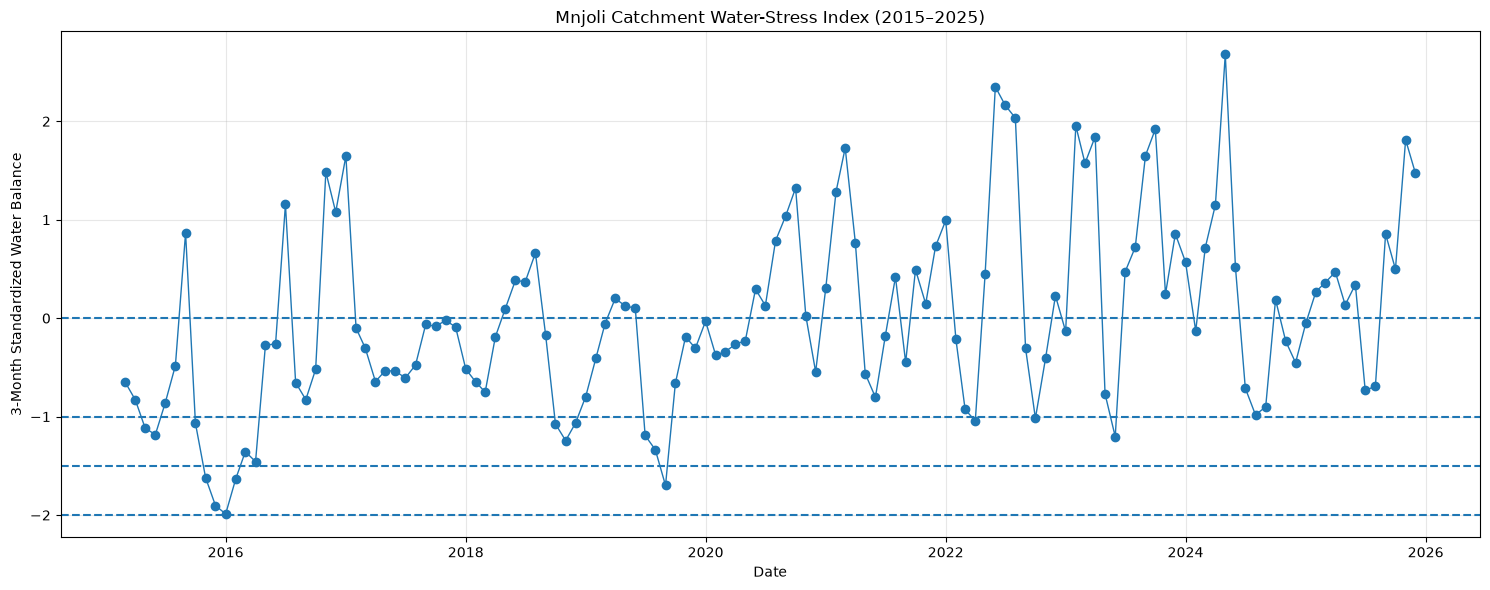

In [198]:
# ============================================================
# WATER-STRESS TIMELINE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    df_monthly["month_date"],
    df_monthly["water_stress_index"],
    marker="o",
    linewidth=1
)

plt.axhline(0, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.axhline(-1.5, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.title(
    "Mnjoli Catchment Water-Stress Index (2015–2025)"
)

plt.xlabel("Date")
plt.ylabel("3-Month Standardized Water Balance")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [199]:
# ============================================================
# ML FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np

# Make sure data is chronological
df_ml = (
    df_monthly
    .sort_values("month_date")
    .reset_index(drop=True)
)

# ============================================================
# TARGET
# ============================================================

target = "water_stress_index"

# ============================================================
# VARIABLES TO LAG
# ============================================================

lag_variables = [
    "precipitation_mm",
    "pet_mm",
    "water_balance_mm",
    "water_balance_3month",
    "temperature_mean_c",
    "temperature_min_c",
    "temperature_max_c",
    "dewpoint_c",
    "soil_moisture_layer1",
    "soil_moisture_layer2",
    "runoff_mm",
    "surface_runoff_mm",
    "solar_radiation",
    "wind_speed",
    "surface_pressure_kpa"
]

# ============================================================
# CREATE LAGS
# ============================================================

for variable in lag_variables:

    for lag in [1, 2, 3]:

        df_ml[f"{variable}_lag{lag}"] = (
            df_ml[variable].shift(lag)
        )

# ============================================================
# ADD ROLLING PRECIPITATION
# ============================================================

df_ml["precipitation_3month"] = (
    df_ml["precipitation_mm"]
    .shift(1)
    .rolling(3)
    .sum()
)

df_ml["precipitation_6month"] = (
    df_ml["precipitation_mm"]
    .shift(1)
    .rolling(6)
    .sum()
)

# ============================================================
# ADD ROLLING PET
# ============================================================

df_ml["pet_3month"] = (
    df_ml["pet_mm"]
    .shift(1)
    .rolling(3)
    .sum()
)

df_ml["pet_6month"] = (
    df_ml["pet_mm"]
    .shift(1)
    .rolling(6)
    .sum()
)

# ============================================================
# MONTH / SEASON
# ============================================================

df_ml["month_sin"] = np.sin(
    2 * np.pi * df_ml["month"] / 12
)

df_ml["month_cos"] = np.cos(
    2 * np.pi * df_ml["month"] / 12
)

# ============================================================
# CHECK
# ============================================================

print("ML dataset shape:", df_ml.shape)

print("\nTarget:")
print(target)

print("\nMissing target:")
print(df_ml[target].isna().sum())

print("\nFirst 10 rows of target + selected predictors:")

display(
    df_ml[
        [
            "month_date",
            target,
            "precipitation_mm_lag1",
            "precipitation_mm_lag2",
            "precipitation_mm_lag3",
            "pet_mm_lag1",
            "water_balance_mm_lag1",
            "soil_moisture_layer1_lag1"
        ]
    ].head(10)
)

ML dataset shape: (132, 76)

Target:
water_stress_index

Missing target:
2

First 10 rows of target + selected predictors:


,month_date,water_stress_index,precipitation_mm_lag1,precipitation_mm_lag2,precipitation_mm_lag3,pet_mm_lag1,water_balance_mm_lag1,soil_moisture_layer1_lag1
0,2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-02-01,NaN,108.399174,NaN,NaN,223.820343,-115.421169,0.254893
2,2015-03-01,-0.648960,153.429877,108.399174,NaN,205.196632,-51.766755,0.224155
3,2015-04-01,-0.829686,66.667655,153.429877,108.399174,230.976277,-164.308621,0.150096
4,2015-05-01,-1.116914,25.722274,66.667655,153.429877,158.938783,-133.216509,0.193402
5,2015-06-01,-1.182728,6.401154,25.722274,66.667655,156.063646,-149.662492,0.155295
6,2015-07-01,-0.861457,6.331618,6.401154,25.722274,144.229834,-137.898216,0.108327
7,2015-08-01,-0.481572,10.037668,6.331618,6.401154,149.188829,-139.151162,0.145413
8,2015-09-01,0.866674,8.076374,10.037668,6.331618,180.066791,-171.990417,0.130632
9,2015-10-01,-1.067118,33.993718,8.076374,10.037668,196.083262,-162.089543,0.175080


In [244]:
# ============================================================
# PREPARE CHRONOLOGICAL ML DATASET
# ============================================================

# Remove observations where the target cannot be calculated
df_model = (
    df_ml[
        df_ml["water_stress_index"].notna()
    ]
    .copy()
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Remove rows with missing predictor values
# ------------------------------------------------------------

# These occur naturally because lagged variables require
# previous months of observations.

df_model = df_model.dropna().reset_index(drop=True)

print("Final modelling dataset:", df_model.shape)

print("\nDate range:")
print(
    df_model["month_date"].min(),
    "to",
    df_model["month_date"].max()
)

# ============================================================
# CHRONOLOGICAL SPLIT
# ============================================================

train = df_model[
    df_model["month_date"] < "2022-01-01"
].copy()

validation = df_model[
    (df_model["month_date"] >= "2022-01-01") &
    (df_model["month_date"] < "2024-01-01")
].copy()

test = df_model[
    df_model["month_date"] >= "2024-01-01"
].copy()

print("\nDataset sizes:")
print("Training:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

print("\nTraining period:")
print(train["month_date"].min(), "to", train["month_date"].max())

print("\nValidation period:")
print(
    validation["month_date"].min(),
    "to",
    validation["month_date"].max()
)

print("\nTest period:")
print(test["month_date"].min(), "to", test["month_date"].max())

Final modelling dataset: (127, 63)

Date range:
2015-06-01 00:00:00 to 2025-12-01 00:00:00

Dataset sizes:
Training: (79, 63)
Validation: (24, 63)
Test: (24, 63)

Training period:
2015-06-01 00:00:00 to 2021-12-01 00:00:00

Validation period:
2022-01-01 00:00:00 to 2023-12-01 00:00:00

Test period:
2024-01-01 00:00:00 to 2025-12-01 00:00:00


In [201]:
# ============================================================
# STEP 1: ML PREDICTOR / TARGET LEAKAGE AUDIT
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("ML PREDICTOR / TARGET LEAKAGE AUDIT")
print("=" * 60)

# Target
target = "water_stress_index"

# Confirm target exists
print("\nTarget:", target)
print("Target exists:", target in df_ml.columns)

# Show all columns
print("\nAll ML columns:")
for i, col in enumerate(df_ml.columns, 1):
    print(f"{i:02d}. {col}")

# ------------------------------------------------------------
# Identify variables directly related to target construction
# ------------------------------------------------------------

potential_leakage = [
    "water_balance_mm",
    "water_balance_3month",
    "water_balance_6month",
    "water_balance_z",
    "wb_month_mean",
    "wb_month_std",
    "spei_1",
    "spei_3",
    "spei_6",
]

print("\n" + "=" * 60)
print("POTENTIAL LEAKAGE VARIABLES")
print("=" * 60)

found_leakage = []

for col in potential_leakage:
    if col in df_ml.columns:
        found_leakage.append(col)
        print("FOUND:", col)

if not found_leakage:
    print("No obvious leakage variables found.")

# ------------------------------------------------------------
# Check target correlations
# ------------------------------------------------------------

numeric_cols = df_ml.select_dtypes(include=np.number).columns

correlations = (
    df_ml[numeric_cols]
    .corr()[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False)
)

print("\n" + "=" * 60)
print("TOP 20 ABSOLUTE CORRELATIONS WITH TARGET")
print("=" * 60)

print(correlations.head(20))

# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = df_ml.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("No missing values.")
else:
    print(missing)

# ------------------------------------------------------------
# Dataset summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print("Shape:", df_ml.shape)
print("Target missing:", df_ml[target].isna().sum())
print("Predictors:", len(df_ml.columns) - 2)  # excluding date + target

print("\nAudit complete.")

ML PREDICTOR / TARGET LEAKAGE AUDIT

Target: water_stress_index
Target exists: True

All ML columns:
01. month_date
02. precipitation_mm
03. pet_mm
04. temperature_mean_c
05. temperature_min_c
06. temperature_max_c
07. dewpoint_c
08. soil_moisture_layer1
09. soil_moisture_layer2
10. runoff_mm
11. surface_runoff_mm
12. solar_radiation
13. wind_speed
14. surface_pressure_kpa
15. water_balance_mm
16. water_balance_3month
17. water_balance_6month
18. year
19. month
20. season
21. calendar_month
22. wb3_mean
23. wb3_std
24. water_stress_index
25. water_stress_class
26. precipitation_mm_lag1
27. precipitation_mm_lag2
28. precipitation_mm_lag3
29. pet_mm_lag1
30. pet_mm_lag2
31. pet_mm_lag3
32. water_balance_mm_lag1
33. water_balance_mm_lag2
34. water_balance_mm_lag3
35. water_balance_3month_lag1
36. water_balance_3month_lag2
37. water_balance_3month_lag3
38. temperature_mean_c_lag1
39. temperature_mean_c_lag2
40. temperature_mean_c_lag3
41. temperature_min_c_lag1
42. temperature_min_c_lag2
4

In [202]:
# ============================================================
# STEP 2: BUILD LEAKAGE-FREE ML DATASET
# ============================================================

import pandas as pd
import numpy as np

target = "water_stress_index"

# ------------------------------------------------------------
# Variables that must NOT be used as predictors
# ------------------------------------------------------------

leakage_columns = [
    # Direct components of target construction
    "water_balance_mm",
    "water_balance_3month",
    "water_balance_6month",

    # Lagged water balance variables
    "water_balance_mm_lag1",
    "water_balance_mm_lag2",
    "water_balance_mm_lag3",

    "water_balance_3month_lag1",
    "water_balance_3month_lag2",
    "water_balance_3month_lag3",

    # Components/statistics used in target construction
    "wb3_mean",
    "wb3_std",

    # Derived directly from target
    "water_stress_class",

    # Avoid using calendar year as a predictor initially
    "year",
]

# Keep only columns that actually exist
leakage_columns = [
    col for col in leakage_columns
    if col in df_ml.columns
]

print("Columns being excluded:")
for col in leakage_columns:
    print(" -", col)

# ------------------------------------------------------------
# Remove excluded variables
# ------------------------------------------------------------

df_clean = df_ml.drop(columns=leakage_columns)

# ------------------------------------------------------------
# Remove rows where target is missing
# ------------------------------------------------------------

df_clean = df_clean.dropna(subset=[target]).copy()

print("\nAfter removing missing target rows:")
print("Shape:", df_clean.shape)

# ------------------------------------------------------------
# Separate date, predictors and target
# ------------------------------------------------------------

X = df_clean.drop(columns=[target, "month_date"])
y = df_clean[target]

print("\nPredictor matrix:")
print("X shape:", X.shape)

print("\nTarget:")
print("y shape:", y.shape)

# ------------------------------------------------------------
# Check remaining missing values
# ------------------------------------------------------------

missing = X.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nRemaining missing predictor values:")

if len(missing) == 0:
    print("None")
else:
    print(missing)

# ------------------------------------------------------------
# Final predictor list
# ------------------------------------------------------------

print("\nNumber of predictors:", X.shape[1])

print("\nFinal predictors:")

for i, col in enumerate(X.columns, 1):
    print(f"{i:02d}. {col}")

Columns being excluded:
 - water_balance_mm
 - water_balance_3month
 - water_balance_6month
 - water_balance_mm_lag1
 - water_balance_mm_lag2
 - water_balance_mm_lag3
 - water_balance_3month_lag1
 - water_balance_3month_lag2
 - water_balance_3month_lag3
 - wb3_mean
 - wb3_std
 - water_stress_class
 - year

After removing missing target rows:
Shape: (130, 63)

Predictor matrix:
X shape: (130, 61)

Target:
y shape: (130,)

Remaining missing predictor values:
precipitation_6month         4
pet_6month                   4
precipitation_mm_lag3        1
pet_mm_lag3                  1
temperature_mean_c_lag3      1
dewpoint_c_lag3              1
soil_moisture_layer1_lag3    1
temperature_min_c_lag3       1
temperature_max_c_lag3       1
runoff_mm_lag3               1
soil_moisture_layer2_lag3    1
surface_runoff_mm_lag3       1
solar_radiation_lag3         1
surface_pressure_kpa_lag3    1
wind_speed_lag3              1
precipitation_3month         1
pet_3month                   1
dtype: int64

In [203]:
# ============================================================
# STEP 3: FINALIZE COMPLETE ML DATASET
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("FINALIZING COMPLETE ML DATASET")
print("=" * 60)

# Work from the leakage-controlled dataset
df_model = df_clean.copy()

# ------------------------------------------------------------
# Remove rows with missing predictor values
# ------------------------------------------------------------

predictor_columns = [
    col for col in df_model.columns
    if col not in ["month_date", "water_stress_index"]
]

before = len(df_model)

df_model = df_model.dropna(
    subset=predictor_columns
).copy()

after = len(df_model)

print("\nRows before removing incomplete predictors:", before)
print("Rows after removing incomplete predictors:", after)
print("Rows removed:", before - after)

# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

missing = df_model.isna().sum()
missing = missing[missing > 0]

print("\nRemaining missing values:")

if len(missing) == 0:
    print("NONE")
else:
    print(missing)

# ------------------------------------------------------------
# Separate X and y
# ------------------------------------------------------------

X = df_model[predictor_columns].copy()
y = df_model["water_stress_index"].copy()

print("\n" + "=" * 60)
print("FINAL DATASET")
print("=" * 60)

print("Dataset shape:", df_model.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nDate range:")
print(df_model["month_date"].min())
print("to")
print(df_model["month_date"].max())

print("\nTarget statistics:")
print(y.describe())

# ------------------------------------------------------------
# Verify chronological order
# ------------------------------------------------------------

is_sorted = df_model["month_date"].is_monotonic_increasing

print("\nChronologically sorted:", is_sorted)

# ------------------------------------------------------------
# Display first and last observations
# ------------------------------------------------------------

print("\nFirst 5 observations:")
print(
    df_model[
        ["month_date", "water_stress_index"]
    ].head()
)

print("\nLast 5 observations:")
print(
    df_model[
        ["month_date", "water_stress_index"]
    ].tail()
)

FINALIZING COMPLETE ML DATASET

Rows before removing incomplete predictors: 130
Rows after removing incomplete predictors: 126
Rows removed: 4

Remaining missing values:
NONE

FINAL DATASET
Dataset shape: (126, 63)
X shape: (126, 61)
y shape: (126,)

Date range:
2015-07-01 00:00:00
to
2025-12-01 00:00:00

Target statistics:
count    126.000000
mean       0.029986
std        0.955535
min       -1.988684
25%       -0.634538
50%       -0.095434
75%        0.511074
max        2.680300
Name: water_stress_index, dtype: float64

Chronologically sorted: True

First 5 observations:
   month_date  water_stress_index
6  2015-07-01           -0.861457
7  2015-08-01           -0.481572
8  2015-09-01            0.866674
9  2015-10-01           -1.067118
10 2015-11-01           -1.620969

Last 5 observations:
    month_date  water_stress_index
127 2025-08-01           -0.690398
128 2025-09-01            0.855663
129 2025-10-01            0.497818
130 2025-11-01            1.812108
131 2025-12-01     

In [204]:
# ============================================================
# STEP 4: FINAL TEMPORAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Define periods
# ------------------------------------------------------------

train_end = "2021-12-01"
validation_end = "2023-12-01"

# Training
train = df_model[
    df_model["month_date"] <= train_end
].copy()

# Validation
validation = df_model[
    (df_model["month_date"] > train_end) &
    (df_model["month_date"] <= validation_end)
].copy()

# Test
test = df_model[
    df_model["month_date"] > validation_end
].copy()

# ------------------------------------------------------------
# Define predictors and target
# ------------------------------------------------------------

feature_columns = [
    col for col in df_model.columns
    if col not in ["month_date", "water_stress_index"]
]

X_train = train[feature_columns].copy()
y_train = train["water_stress_index"].copy()

X_val = validation[feature_columns].copy()
y_val = validation["water_stress_index"].copy()

X_test = test[feature_columns].copy()
y_test = test["water_stress_index"].copy()

# ------------------------------------------------------------
# Report dataset sizes
# ------------------------------------------------------------

print("=" * 60)
print("FINAL TEMPORAL DATA SPLIT")
print("=" * 60)

print("\nTraining:")
print("Shape:", train.shape)
print("Period:", train["month_date"].min(), "to", train["month_date"].max())

print("\nValidation:")
print("Shape:", validation.shape)
print("Period:", validation["month_date"].min(), "to", validation["month_date"].max())

print("\nTest:")
print("Shape:", test.shape)
print("Period:", test["month_date"].min(), "to", test["month_date"].max())

print("\nPredictor count:", len(feature_columns))

# ------------------------------------------------------------
# Check that there is no overlap
# ------------------------------------------------------------

train_dates = set(train["month_date"])
val_dates = set(validation["month_date"])
test_dates = set(test["month_date"])

print("\nDate overlap checks:")
print("Train ∩ Validation:", len(train_dates & val_dates))
print("Train ∩ Test:", len(train_dates & test_dates))
print("Validation ∩ Test:", len(val_dates & test_dates))

# ------------------------------------------------------------
# Target distributions
# ------------------------------------------------------------

print("\nTarget means:")
print("Training:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

print("\nTarget standard deviations:")
print("Training:", y_train.std())
print("Validation:", y_val.std())
print("Test:", y_test.std())

FINAL TEMPORAL DATA SPLIT

Training:
Shape: (78, 63)
Period: 2015-07-01 00:00:00 to 2021-12-01 00:00:00

Validation:
Shape: (24, 63)
Period: 2022-01-01 00:00:00 to 2023-12-01 00:00:00

Test:
Shape: (24, 63)
Period: 2024-01-01 00:00:00 to 2025-12-01 00:00:00

Predictor count: 61

Date overlap checks:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Target means:
Training: -0.21549521678322883
Validation: 0.5599237089163904
Test: 0.297864374367375

Target standard deviations:
Training: 0.8204889587921346
Validation: 1.1618653265871772
Test: 0.8866955997802346


In [205]:
# ============================================================
# STEP 5: NAIVE PERSISTENCE BASELINE
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ------------------------------------------------------------
# Persistence forecast
#
# Predict current month's stress using previous month's
# observed water-stress index.
# ------------------------------------------------------------

df_baseline = df_model[
    ["month_date", "water_stress_index"]
].copy()

df_baseline["prediction"] = (
    df_baseline["water_stress_index"]
    .shift(1)
)

# Only evaluate where a previous observation exists
df_baseline = df_baseline.dropna().copy()

# ------------------------------------------------------------
# Evaluate separately for validation and test
# ------------------------------------------------------------

validation_baseline = df_baseline[
    (df_baseline["month_date"] > train_end) &
    (df_baseline["month_date"] <= validation_end)
].copy()

test_baseline = df_baseline[
    df_baseline["month_date"] > validation_end
].copy()

def evaluate_model(y_true, y_pred, model_name):
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

baseline_results = []

baseline_results.append(
    evaluate_model(
        validation_baseline["water_stress_index"],
        validation_baseline["prediction"],
        "Persistence"
    )
)

print("=" * 60)
print("PERSISTENCE BASELINE — VALIDATION")
print("=" * 60)

print(pd.DataFrame(baseline_results))

# ------------------------------------------------------------
# Test baseline
# ------------------------------------------------------------

test_result = evaluate_model(
    test_baseline["water_stress_index"],
    test_baseline["prediction"],
    "Persistence"
)

print("\n" + "=" * 60)
print("PERSISTENCE BASELINE — TEST")
print("=" * 60)

print(pd.DataFrame([test_result]))

PERSISTENCE BASELINE — VALIDATION
         Model       MAE      RMSE        R2
0  Persistence  0.911213  1.179793 -0.075929

PERSISTENCE BASELINE — TEST
         Model       MAE      RMSE        R2
0  Persistence  0.642216  0.852831  0.034706


In [206]:
# ============================================================
# RELOAD FINAL ML DATASET
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# Project root
project_root = Path(r"C:\Users\Para\Desktop\Eswatini_Water_Stress_ML")

# Saved water-stress ML dataset
input_path = (
    project_root
    / "data"
    / "processed"
    / "mnjoli_water_stress_ml_dataset.csv"
)

print("Looking for:", input_path)
print("Exists:", input_path.exists())

Looking for: C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data\processed\mnjoli_water_stress_ml_dataset.csv
Exists: False


In [207]:
from pathlib import Path

project_root = Path(r"C:\Users\Para\Desktop\Eswatini_Water_Stress_ML")
processed_dir = project_root / "data" / "processed"

print("Processed directory:")
print(processed_dir)
print("\nExists:", processed_dir.exists())

print("\nCSV files:")
for f in processed_dir.glob("*.csv"):
    print(" -", f.name)

Processed directory:
C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data\processed

Exists: True

CSV files:
 - mnjoli_water_stress_features_daily.csv
 - mnjoli_water_stress_monthly.csv


In [208]:
# ============================================================
# RECONSTRUCT FINAL ML DATASET
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. PROJECT PATH
# ------------------------------------------------------------

project_root = Path(r"C:\Users\Para\Desktop\Eswatini_Water_Stress_ML")
monthly_path = (
    project_root
    / "data"
    / "processed"
    / "mnjoli_water_stress_monthly.csv"
)

print("=" * 60)
print("LOADING MONTHLY WATER-STRESS DATA")
print("=" * 60)

print("File:", monthly_path)
print("Exists:", monthly_path.exists())

# ------------------------------------------------------------
# 2. LOAD
# ------------------------------------------------------------

df = pd.read_csv(monthly_path, parse_dates=["month_date"])

df = df.sort_values("month_date").reset_index(drop=True)

print("\nLoaded shape:", df.shape)
print("Date range:", df["month_date"].min(), "to", df["month_date"].max())

# ------------------------------------------------------------
# 3. CREATE LAG FEATURES
# ------------------------------------------------------------

lag_variables = [
    "precipitation_mm",
    "pet_mm",
    "temperature_mean_c",
    "temperature_min_c",
    "temperature_max_c",
    "dewpoint_c",
    "soil_moisture_layer1",
    "soil_moisture_layer2",
    "runoff_mm",
    "surface_runoff_mm",
    "solar_radiation",
    "wind_speed",
    "surface_pressure_kpa",
    "water_balance_mm",
    "water_balance_3month",
]

for variable in lag_variables:
    for lag in [1, 2, 3]:
        df[f"{variable}_lag{lag}"] = df[variable].shift(lag)

# ------------------------------------------------------------
# 4. CUMULATIVE PRECIPITATION AND PET
# ------------------------------------------------------------

df["precipitation_3month"] = (
    df["precipitation_mm"]
    .rolling(window=3)
    .sum()
)

df["precipitation_6month"] = (
    df["precipitation_mm"]
    .rolling(window=6)
    .sum()
)

df["pet_3month"] = (
    df["pet_mm"]
    .rolling(window=3)
    .sum()
)

df["pet_6month"] = (
    df["pet_mm"]
    .rolling(window=6)
    .sum()
)

# ------------------------------------------------------------
# 5. SEASONAL CYCLICAL FEATURES
# ------------------------------------------------------------

df["calendar_month"] = df["month"]

df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

# ------------------------------------------------------------
# 6. MONTHLY WATER-BALANCE CLIMATOLOGY
# ------------------------------------------------------------

df["wb3_mean"] = (
    df.groupby("month")["water_balance_3month"]
    .transform("mean")
)

df["wb3_std"] = (
    df.groupby("month")["water_balance_3month"]
    .transform("std")
)

# ------------------------------------------------------------
# 7. WATER-STRESS INDEX
# ------------------------------------------------------------

df["water_stress_index"] = (
    df["water_balance_3month"] - df["wb3_mean"]
) / df["wb3_std"]

# ------------------------------------------------------------
# 8. WATER-STRESS CLASS
# ------------------------------------------------------------

def classify_water_stress(x):

    if pd.isna(x):
        return "Insufficient data"

    elif x <= -1.5:
        return "Severe stress"

    elif x <= -1.0:
        return "Moderate stress"

    elif x <= -0.5:
        return "Mild stress"

    elif x <= 1.0:
        return "Normal"

    else:
        return "Above normal"


df["water_stress_class"] = (
    df["water_stress_index"]
    .apply(classify_water_stress)
)

# ------------------------------------------------------------
# 9. CHECK RECONSTRUCTED DATASET
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RECONSTRUCTED ML DATASET")
print("=" * 60)

print("Shape:", df.shape)

print("\nTarget:")
print(df["water_stress_index"].describe())

print("\nMissing target:")
print(df["water_stress_index"].isna().sum())

LOADING MONTHLY WATER-STRESS DATA
File: C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data\processed\mnjoli_water_stress_monthly.csv
Exists: True

Loaded shape: (132, 20)
Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00

RECONSTRUCTED ML DATASET
Shape: (132, 76)

Target:
count    1.300000e+02
mean     2.459571e-16
std      9.564145e-01
min     -1.988684e+00
25%     -6.532697e-01
50%     -1.319995e-01
75%      4.965760e-01
max      2.680300e+00
Name: water_stress_index, dtype: float64

Missing target:
2


In [209]:
# ============================================================
# FINAL LEAKAGE-CONTROLLED ML DATASET
# ============================================================

# Variables that directly contain or derive the target
leakage_columns = [
    "water_balance_mm",
    "water_balance_3month",
    "water_balance_6month",

    "water_balance_mm_lag1",
    "water_balance_mm_lag2",
    "water_balance_mm_lag3",

    "water_balance_3month_lag1",
    "water_balance_3month_lag2",
    "water_balance_3month_lag3",

    "wb3_mean",
    "wb3_std",

    "water_stress_class",

    "year"
]

# Remove leakage variables
df_ml = df.drop(
    columns=leakage_columns,
    errors="ignore"
).copy()

# Remove rows where target is missing
df_ml = df_ml.dropna(
    subset=["water_stress_index"]
).copy()

# Identify predictors
predictor_columns = [
    col for col in df_ml.columns
    if col not in ["month_date", "water_stress_index"]
]

# Remove rows with incomplete predictors
df_final = df_ml.dropna(
    subset=predictor_columns
).copy()

# Sort chronologically
df_final = (
    df_final
    .sort_values("month_date")
    .reset_index(drop=True)
)

# X and y
X = df_final[predictor_columns].copy()
y = df_final["water_stress_index"].copy()

print("=" * 60)
print("FINAL ML DATASET")
print("=" * 60)

print("Dataset shape:", df_final.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nDate range:")
print(df_final["month_date"].min())
print("to")
print(df_final["month_date"].max())

print("\nMissing values:")
print(df_final.isna().sum().sum())

print("\nTarget statistics:")
print(y.describe())

print("\nPredictors:", len(predictor_columns))

FINAL ML DATASET
Dataset shape: (127, 63)
X shape: (127, 61)
y shape: (127,)

Date range:
2015-06-01 00:00:00
to
2025-12-01 00:00:00

Missing values:
0

Target statistics:
count    127.000000
mean       0.020437
std        0.957800
min       -1.988684
25%       -0.647308
50%       -0.100686
75%        0.506655
max        2.680300
Name: water_stress_index, dtype: float64

Predictors: 61


In [210]:
# ============================================================
# SAVE FINAL ML DATASET
# ============================================================

final_path = (
    project_root
    / "data"
    / "processed"
    / "mnjoli_water_stress_ml_dataset.csv"
)

df_final.to_csv(
    final_path,
    index=False
)

print("Saved successfully!")
print("File:", final_path)
print("Exists:", final_path.exists())
print("Shape:", df_final.shape)

Saved successfully!
File: C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data\processed\mnjoli_water_stress_ml_dataset.csv
Exists: True
Shape: (127, 63)


In [211]:
# ============================================================
# FIND THE EXTRA 127th ROW
# ============================================================

print("Current final shape:", df_final.shape)

# Show all rows and their dates
print("\nFirst/last dates:")
print(df_final["month_date"].head(10).to_string(index=False))
print(df_final["month_date"].tail(10).to_string(index=False))

# Check missing values in the ORIGINAL 132-row dataset
print("\nMissing values before final filtering:")
missing_summary = df.isna().sum()
print(missing_summary[missing_summary > 0])

# Check which rows contain missing predictors
rows_with_missing = df_ml[
    df_ml[predictor_columns].isna().any(axis=1)
]

print("\nRows with incomplete predictors:")
print(
    rows_with_missing[
        ["month_date", "water_stress_index"]
    ].to_string(index=False)
)

print("\nNumber of incomplete rows:", len(rows_with_missing))

Current final shape: (127, 63)

First/last dates:
2015-06-01
2015-07-01
2015-08-01
2015-09-01
2015-10-01
2015-11-01
2015-12-01
2016-01-01
2016-02-01
2016-03-01
2025-03-01
2025-04-01
2025-05-01
2025-06-01
2025-07-01
2025-08-01
2025-09-01
2025-10-01
2025-11-01
2025-12-01

Missing values before final filtering:
water_balance_3month         2
water_balance_6month         5
precipitation_mm_lag1        1
precipitation_mm_lag2        2
precipitation_mm_lag3        3
pet_mm_lag1                  1
pet_mm_lag2                  2
pet_mm_lag3                  3
temperature_mean_c_lag1      1
temperature_mean_c_lag2      2
temperature_mean_c_lag3      3
temperature_min_c_lag1       1
temperature_min_c_lag2       2
temperature_min_c_lag3       3
temperature_max_c_lag1       1
temperature_max_c_lag2       2
temperature_max_c_lag3       3
dewpoint_c_lag1              1
dewpoint_c_lag2              2
dewpoint_c_lag3              3
soil_moisture_layer1_lag1    1
soil_moisture_layer1_lag2    2
soil_moi

In [212]:
# ============================================================
# EXACT ROW-REMOVAL AUDIT
# ============================================================

valid_target = df_ml["water_stress_index"].notna()

complete_predictors = (
    df_ml[predictor_columns]
    .notna()
    .all(axis=1)
)

print("Rows with valid target:", valid_target.sum())
print("Rows with complete predictors:", complete_predictors.sum())

print("\nRows removed because of missing predictors:")

removed = df_ml[
    valid_target & ~complete_predictors
]

print(
    removed[
        ["month_date", "water_stress_index"]
    ].to_string(index=False)
)

print("\nNumber removed:", len(removed))

Rows with valid target: 130
Rows with complete predictors: 127

Rows removed because of missing predictors:
month_date  water_stress_index
2015-03-01           -0.648960
2015-04-01           -0.829686
2015-05-01           -1.116914

Number removed: 3


In [213]:
# ============================================================
# FINAL MODELLING DATASET — 3-MONTH WARM-UP PERIOD
# ============================================================

# Start after the 3-month feature warm-up period
df_final = df_ml[
    df_ml["month_date"] >= pd.Timestamp("2015-07-01")
].copy()

# Remove any remaining incomplete predictor rows
df_final = df_final.dropna(
    subset=predictor_columns
).copy()

# Sort chronologically
df_final = (
    df_final
    .sort_values("month_date")
    .reset_index(drop=True)
)

# Recreate X and y
X = df_final[predictor_columns].copy()
y = df_final["water_stress_index"].copy()

print("=" * 60)
print("FINAL MODELLING DATASET")
print("=" * 60)

print("Dataset shape:", df_final.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nDate range:")
print(df_final["month_date"].min())
print("to")
print(df_final["month_date"].max())

print("\nMissing values:")
print(df_final.isna().sum().sum())

print("\nTarget statistics:")
print(y.describe())

print("\nFirst 5:")
print(
    df_final[["month_date", "water_stress_index"]]
    .head()
)

print("\nLast 5:")
print(
    df_final[["month_date", "water_stress_index"]]
    .tail()
)

FINAL MODELLING DATASET
Dataset shape: (126, 63)
X shape: (126, 61)
y shape: (126,)

Date range:
2015-07-01 00:00:00
to
2025-12-01 00:00:00

Missing values:
0

Target statistics:
count    126.000000
mean       0.029986
std        0.955535
min       -1.988684
25%       -0.634538
50%       -0.095434
75%        0.511074
max        2.680300
Name: water_stress_index, dtype: float64

First 5:
  month_date  water_stress_index
0 2015-07-01           -0.861457
1 2015-08-01           -0.481572
2 2015-09-01            0.866674
3 2015-10-01           -1.067118
4 2015-11-01           -1.620969

Last 5:
    month_date  water_stress_index
121 2025-08-01           -0.690398
122 2025-09-01            0.855663
123 2025-10-01            0.497818
124 2025-11-01            1.812108
125 2025-12-01            1.470839


In [214]:
final_path = (
    project_root
    / "data"
    / "processed"
    / "mnjoli_water_stress_ml_dataset.csv"
)

df_final.to_csv(final_path, index=False)

print("\nSaved successfully!")
print(final_path)
print("Shape:", df_final.shape)


Saved successfully!
C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data\processed\mnjoli_water_stress_ml_dataset.csv
Shape: (126, 63)


In [215]:
# ============================================================
# PREPARE FINAL CHRONOLOGICAL ML SPLIT
# ============================================================

import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. PROJECT PATH
# ------------------------------------------------------------

project_root = Path(
    r"C:\Users\Para\Desktop\Eswatini_Water_Stress_ML"
)

data_path = (
    project_root
    / "data"
    / "processed"
    / "mnjoli_water_stress_ml_dataset.csv"
)

# ------------------------------------------------------------
# 2. LOAD FINAL DATASET
# ------------------------------------------------------------

df_model = pd.read_csv(
    data_path,
    parse_dates=["month_date"]
)

df_model = (
    df_model
    .sort_values("month_date")
    .reset_index(drop=True)
)

print("=" * 60)
print("FINAL ML DATASET LOADED")
print("=" * 60)

print("Shape:", df_model.shape)
print("Date range:")
print(df_model["month_date"].min())
print("to")
print(df_model["month_date"].max())

# ------------------------------------------------------------
# 3. DEFINE TARGET
# ------------------------------------------------------------

target = "water_stress_index"

# ------------------------------------------------------------
# 4. EXCLUDE NON-PREDICTOR COLUMNS
# ------------------------------------------------------------

exclude_columns = [
    "month_date",
    target,
    "water_stress_class",

    # Target-derived / leakage variables
    "water_balance_mm",
    "water_balance_3month",
    "water_balance_6month",

    "water_balance_mm_lag1",
    "water_balance_mm_lag2",
    "water_balance_mm_lag3",

    "water_balance_3month_lag1",
    "water_balance_3month_lag2",
    "water_balance_3month_lag3",

    "wb3_mean",
    "wb3_std",

    # Time trend excluded deliberately
    "year"
]

predictor_columns = [
    col for col in df_model.columns
    if col not in exclude_columns
]

# ------------------------------------------------------------
# 5. CREATE X AND y
# ------------------------------------------------------------

X = df_model[predictor_columns].copy()
y = df_model[target].copy()

print("\nPredictor matrix:", X.shape)
print("Target:", y.shape)

print("\nNumber of predictors:", len(predictor_columns))

# ------------------------------------------------------------
# 6. VERIFY NO MISSING VALUES
# ------------------------------------------------------------

print("\nMissing predictor values:", X.isna().sum().sum())
print("Missing target values:", y.isna().sum())

assert X.isna().sum().sum() == 0
assert y.isna().sum() == 0

# ------------------------------------------------------------
# 7. CHRONOLOGICAL SPLIT
# ------------------------------------------------------------

train_mask = (
    (df_model["month_date"] >= "2015-07-01") &
    (df_model["month_date"] <= "2021-12-01")
)

validation_mask = (
    (df_model["month_date"] >= "2022-01-01") &
    (df_model["month_date"] <= "2023-12-01")
)

test_mask = (
    (df_model["month_date"] >= "2024-01-01") &
    (df_model["month_date"] <= "2025-12-01")
)

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_val = X.loc[validation_mask].copy()
y_val = y.loc[validation_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

# ------------------------------------------------------------
# 8. VERIFY SPLIT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CHRONOLOGICAL SPLIT")
print("=" * 60)

print("\nTraining:")
print("X:", X_train.shape)
print("Period:",
      df_model.loc[train_mask, "month_date"].min(),
      "to",
      df_model.loc[train_mask, "month_date"].max())

print("\nValidation:")
print("X:", X_val.shape)
print("Period:",
      df_model.loc[validation_mask, "month_date"].min(),
      "to",
      df_model.loc[validation_mask, "month_date"].max())

print("\nTest:")
print("X:", X_test.shape)
print("Period:",
      df_model.loc[test_mask, "month_date"].min(),
      "to",
      df_model.loc[test_mask, "month_date"].max())

# ------------------------------------------------------------
# 9. FINAL ASSERTIONS
# ------------------------------------------------------------

assert len(X_train) == 78
assert len(X_val) == 24
assert len(X_test) == 24

assert len(y_train) == 78
assert len(y_val) == 24
assert len(y_test) == 24

print("\n" + "=" * 60)
print("READY FOR MODEL TRAINING")
print("=" * 60)

FINAL ML DATASET LOADED
Shape: (126, 63)
Date range:
2015-07-01 00:00:00
to
2025-12-01 00:00:00

Predictor matrix: (126, 61)
Target: (126,)

Number of predictors: 61

Missing predictor values: 0
Missing target values: 0

CHRONOLOGICAL SPLIT

Training:
X: (78, 61)
Period: 2015-07-01 00:00:00 to 2021-12-01 00:00:00

Validation:
X: (24, 61)
Period: 2022-01-01 00:00:00 to 2023-12-01 00:00:00

Test:
X: (24, 61)
Period: 2024-01-01 00:00:00 to 2025-12-01 00:00:00

READY FOR MODEL TRAINING


In [217]:
# ============================================================
# BASELINE ML MODEL COMPARISON — FIXED
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. PREPARE DATA
# ============================================================

# Make copies so we don't accidentally modify the original data
X_train_model = X_train.copy()
X_val_model = X_val.copy()


# Drop categorical column
if "season" in X_train_model.columns:
    X_train_model = X_train_model.drop(columns=["season"])

if "season" in X_val_model.columns:
    X_val_model = X_val_model.drop(columns=["season"])


# Make absolutely sure everything is numeric
X_train_model = X_train_model.apply(pd.to_numeric, errors="coerce")
X_val_model = X_val_model.apply(pd.to_numeric, errors="coerce")


print("=" * 70)
print("MODEL INPUT CHECK")
print("=" * 70)

print("Training shape:", X_train_model.shape)
print("Validation shape:", X_val_model.shape)

print("\nNon-numeric training columns:")
print(
    X_train_model.select_dtypes(exclude=np.number).columns.tolist()
)

print("\nMissing training values:")
print(X_train_model.isna().sum().sum())

print("\nMissing validation values:")
print(X_val_model.isna().sum().sum())


# ============================================================
# 2. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X_train, y_train, X_eval, y_eval):

    model.fit(X_train, y_train)

    predictions = model.predict(X_eval)

    mae = mean_absolute_error(y_eval, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_eval, predictions)
    )

    r2 = r2_score(y_eval, predictions)

    return mae, rmse, r2, predictions


# ============================================================
# 3. DEFINE MODELS
# ============================================================

models = {

    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Extra Trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.03,
            max_depth=2,
            min_samples_leaf=4,
            random_state=42
        ))
    ])
}


# ============================================================
# 4. TRAIN + VALIDATE
# ============================================================

results = []

validation_predictions = {}

for name, model in models.items():

    print(f"\nTraining: {name}")

    mae, rmse, r2, predictions = evaluate_model(
        model,
        X_train_model,
        y_train,
        X_val_model,
        y_val
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    validation_predictions[name] = predictions


# ============================================================
# 5. RESULTS
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "RMSE"
).reset_index(drop=True)

print("\n")
print("=" * 70)
print("VALIDATION MODEL COMPARISON")
print("=" * 70)

print(
    results_df.to_string(index=False)
)


# ============================================================
# 6. PERSISTENCE COMPARISON
# ============================================================

print("\n")
print("=" * 70)
print("PERSISTENCE BASELINE")
print("=" * 70)

print("MAE  = 0.642216")
print("RMSE = 0.852831")
print("R2   = 0.034706")


# ============================================================
# 7. BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

print("\n")
print("=" * 70)
print("BEST VALIDATION MODEL")
print("=" * 70)

print(best_model_name)

print("\nTest set remains untouched:")
print("2024-01-01 to 2025-12-01")

MODEL INPUT CHECK
Training shape: (78, 60)
Validation shape: (24, 60)

Non-numeric training columns:
[]

Missing training values:
0

Missing validation values:
0

Training: Linear Regression

Training: Ridge

Training: Random Forest

Training: Extra Trees

Training: Gradient Boosting


VALIDATION MODEL COMPARISON
            Model      MAE     RMSE       R2
Linear Regression 0.603615 0.760163 0.553332
            Ridge 0.542042 0.767102 0.545140
Gradient Boosting 0.808720 1.000280 0.226580
    Random Forest 0.874418 1.054245 0.140878
      Extra Trees 0.884577 1.093467 0.075763


PERSISTENCE BASELINE
MAE  = 0.642216
RMSE = 0.852831
R2   = 0.034706


BEST VALIDATION MODEL
Linear Regression

Test set remains untouched:
2024-01-01 to 2025-12-01


In [218]:
# ============================================================
# FEATURE SELECTION + RIDGE REGULARIZATION EXPERIMENT
# TEST SET REMAINS UNTOUCHED
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. MAKE SURE DATA IS CHRONOLOGICAL
# ------------------------------------------------------------

df_model = df_final.sort_values("month_date").reset_index(drop=True)

# Target
target = "water_stress_index"

# Remove non-predictor columns
exclude_columns = [
    "month_date",
    target,
    "water_stress_class"
]

# Also exclude variables already identified as leakage
leakage_columns = [
    "water_balance_mm",
    "water_balance_3month",
    "water_balance_6month",
    "water_balance_mm_lag1",
    "water_balance_mm_lag2",
    "water_balance_mm_lag3",
    "water_balance_3month_lag1",
    "water_balance_3month_lag2",
    "water_balance_3month_lag3",
    "wb3_mean",
    "wb3_std",
    "year"
]

exclude_columns += leakage_columns

# Keep only columns that actually exist
exclude_columns = list(set(
    col for col in exclude_columns
    if col in df_model.columns
))

predictor_columns = [
    col for col in df_model.columns
    if col not in exclude_columns
]

print("Number of predictors:", len(predictor_columns))

# ------------------------------------------------------------
# 2. CHRONOLOGICAL SPLIT
# ------------------------------------------------------------

train_end = "2021-12-01"
validation_end = "2023-12-01"

train_mask = df_model["month_date"] <= train_end
val_mask = (
    (df_model["month_date"] > train_end) &
    (df_model["month_date"] <= validation_end)
)
test_mask = df_model["month_date"] > validation_end

X_train_full = df_model.loc[train_mask, predictor_columns].copy()
y_train = df_model.loc[train_mask, target].copy()

X_val_full = df_model.loc[val_mask, predictor_columns].copy()
y_val = df_model.loc[val_mask, target].copy()

print("\nTraining:", X_train_full.shape)
print("Validation:", X_val_full.shape)

# ------------------------------------------------------------
# 3. CALCULATE FEATURE CORRELATION USING TRAINING DATA ONLY
# ------------------------------------------------------------

train_corr = (
    pd.concat([X_train_full, y_train], axis=1)
    .corr(numeric_only=True)[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False)
)

print("\n============================================================")
print("TOP 20 FEATURES — TRAINING DATA ONLY")
print("============================================================")

print(train_corr.head(20))

# ------------------------------------------------------------
# 4. TEST DIFFERENT FEATURE COUNTS
# ------------------------------------------------------------

feature_counts = [5, 10, 15, 20, 30, 40, 50, 60]

results = []

for n_features in feature_counts:

    selected_features = train_corr.head(
        min(n_features, len(train_corr))
    ).index.tolist()

    X_train = X_train_full[selected_features]
    X_val = X_val_full[selected_features]

    # Ridge pipeline
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0))
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_val)

    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    r2 = r2_score(y_val, predictions)

    results.append({
        "Features": n_features,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

print("\n============================================================")
print("FEATURE COUNT COMPARISON")
print("============================================================")

print(
    results_df
    .sort_values("RMSE")
    .to_string(index=False)
)

# ------------------------------------------------------------
# 5. IDENTIFY BEST FEATURE COUNT
# ------------------------------------------------------------

best_row = results_df.loc[
    results_df["RMSE"].idxmin()
]

print("\n============================================================")
print("BEST FEATURE SET")
print("============================================================")

print("Features:", int(best_row["Features"]))
print("MAE:", round(best_row["MAE"], 4))
print("RMSE:", round(best_row["RMSE"], 4))
print("R2:", round(best_row["R2"], 4))

best_n = int(best_row["Features"])

best_features = train_corr.head(best_n).index.tolist()

print("\nSelected features:")

for i, feature in enumerate(best_features, 1):
    print(f"{i:02d}. {feature}")

Number of predictors: 61

Training: (78, 61)
Validation: (24, 61)

TOP 20 FEATURES — TRAINING DATA ONLY
pet_3month                   0.335883
precipitation_3month         0.332263
temperature_max_c            0.316110
pet_mm_lag1                  0.300121
soil_moisture_layer2         0.300030
pet_mm                       0.294120
pet_6month                   0.291126
precipitation_mm             0.279429
temperature_max_c_lag1       0.278813
pet_mm_lag2                  0.274141
soil_moisture_layer1         0.271332
precipitation_mm_lag1        0.270342
precipitation_mm_lag2        0.268241
solar_radiation_lag2         0.250822
solar_radiation_lag1         0.240195
temperature_max_c_lag2       0.238803
soil_moisture_layer2_lag1    0.228155
soil_moisture_layer1_lag2    0.227049
solar_radiation              0.223848
precipitation_6month         0.213432
Name: water_stress_index, dtype: float64

FEATURE COUNT COMPARISON
 Features      MAE     RMSE       R2
       50 0.529365 0.761471 0.55

In [219]:
# ============================================================
# 50-FEATURE MODEL COMPARISON
# ============================================================

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# USE THE BEST 50 FEATURES ALREADY SELECTED
# ------------------------------------------------------------

selected_features = [
    "pet_3month",
    "precipitation_3month",
    "temperature_max_c",
    "pet_mm_lag1",
    "soil_moisture_layer2",
    "pet_mm",
    "pet_6month",
    "precipitation_mm",
    "temperature_max_c_lag1",
    "pet_mm_lag2",
    "soil_moisture_layer1",
    "precipitation_mm_lag1",
    "precipitation_mm_lag2",
    "solar_radiation_lag2",
    "solar_radiation_lag1",
    "temperature_max_c_lag2",
    "soil_moisture_layer2_lag1",
    "soil_moisture_layer1_lag2",
    "solar_radiation",
    "precipitation_6month",
    "soil_moisture_layer1_lag1",
    "soil_moisture_layer2_lag2",
    "surface_runoff_mm_lag2",
    "runoff_mm_lag2",
    "surface_runoff_mm_lag1",
    "temperature_mean_c",
    "runoff_mm_lag1",
    "surface_runoff_mm",
    "temperature_mean_c_lag1",
    "runoff_mm",
    "temperature_mean_c_lag2",
    "soil_moisture_layer2_lag3",
    "pet_mm_lag3",
    "wind_speed_lag1",
    "wind_speed",
    "surface_runoff_mm_lag3",
    "temperature_max_c_lag3",
    "runoff_mm_lag3",
    "temperature_min_c",
    "temperature_min_c_lag1",
    "soil_moisture_layer1_lag3",
    "temperature_mean_c_lag3",
    "temperature_min_c_lag3",
    "solar_radiation_lag3",
    "wind_speed_lag3",
    "dewpoint_c_lag2",
    "temperature_min_c_lag2",
    "month_cos",
    "dewpoint_c_lag1",
    "dewpoint_c"
]

# ------------------------------------------------------------
# SELECT DATA
# ------------------------------------------------------------

X_train_50 = X_train[selected_features].copy()
X_val_50 = X_val[selected_features].copy()

print("Training:", X_train_50.shape)
print("Validation:", X_val_50.shape)

# ------------------------------------------------------------
# MODELS
# ------------------------------------------------------------

models_50 = {

    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Elastic Net": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
            alpha=0.01,
            l1_ratio=0.5,
            max_iter=10000,
            random_state=42
        ))
    ])
}

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

results_50 = []

for name, model in models_50.items():

    print(f"\nTraining: {name}")

    model.fit(X_train_50, y_train)

    pred = model.predict(X_val_50)

    mae = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)

    results_50.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_50_df = pd.DataFrame(results_50)

print("\n" + "=" * 60)
print("50-FEATURE MODEL COMPARISON")
print("=" * 60)

print(
    results_50_df
    .sort_values("RMSE")
    .round(4)
    .to_string(index=False)
)

Training: (78, 50)
Validation: (24, 50)

Training: Linear Regression

Training: Ridge

Training: Elastic Net

50-FEATURE MODEL COMPARISON
            Model    MAE   RMSE     R2
Linear Regression 0.5175 0.7252 0.5935
            Ridge 0.5585 0.7892 0.5186
      Elastic Net 0.5600 0.7909 0.5165


In [220]:
# ============================================================
# TIME-SERIES CROSS-VALIDATION
# LINEAR REGRESSION — 50 SELECTED FEATURES
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# ------------------------------------------------------------
# 1. USE THE 50 FEATURES SELECTED FROM TRAINING DATA
# ------------------------------------------------------------

selected_features = [
    "pet_3month",
    "precipitation_3month",
    "temperature_max_c",
    "pet_mm_lag1",
    "soil_moisture_layer2",
    "pet_mm",
    "pet_6month",
    "precipitation_mm",
    "temperature_max_c_lag1",
    "pet_mm_lag2",
    "soil_moisture_layer1",
    "precipitation_mm_lag1",
    "precipitation_mm_lag2",
    "solar_radiation_lag2",
    "solar_radiation_lag1",
    "temperature_max_c_lag2",
    "soil_moisture_layer2_lag1",
    "soil_moisture_layer1_lag2",
    "solar_radiation",
    "precipitation_6month",
    "soil_moisture_layer1_lag1",
    "soil_moisture_layer2_lag2",
    "surface_runoff_mm_lag2",
    "runoff_mm_lag2",
    "surface_runoff_mm_lag1",
    "temperature_mean_c",
    "runoff_mm_lag1",
    "surface_runoff_mm",
    "temperature_mean_c_lag1",
    "runoff_mm",
    "temperature_mean_c_lag2",
    "soil_moisture_layer2_lag3",
    "pet_mm_lag3",
    "wind_speed_lag1",
    "wind_speed",
    "surface_runoff_mm_lag3",
    "temperature_max_c_lag3",
    "runoff_mm_lag3",
    "temperature_min_c",
    "temperature_min_c_lag1",
    "soil_moisture_layer1_lag3",
    "temperature_mean_c_lag3",
    "temperature_min_c_lag3",
    "solar_radiation_lag3",
    "wind_speed_lag3",
    "dewpoint_c_lag2",
    "temperature_min_c_lag2",
    "month_cos",
    "dewpoint_c_lag1",
    "dewpoint_c"
]

# ------------------------------------------------------------
# 2. MAKE SURE DATA IS CHRONOLOGICALLY SORTED
# ------------------------------------------------------------

df_cv = df_model.sort_values("month_date").reset_index(drop=True)

X_cv = df_cv[selected_features].copy()
y_cv = df_cv["water_stress_index"].copy()

print("Dataset:", X_cv.shape)
print("Target:", y_cv.shape)

# ------------------------------------------------------------
# 3. TIME-SERIES CROSS-VALIDATION
# ------------------------------------------------------------

tscv = TimeSeriesSplit(n_splits=4)

results = []

fold = 1

for train_idx, val_idx in tscv.split(X_cv):

    X_train_cv = X_cv.iloc[train_idx]
    X_val_cv = X_cv.iloc[val_idx]

    y_train_cv = y_cv.iloc[train_idx]
    y_val_cv = y_cv.iloc[val_idx]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    model.fit(X_train_cv, y_train_cv)

    predictions = model.predict(X_val_cv)

    mae = mean_absolute_error(y_val_cv, predictions)
    rmse = np.sqrt(mean_squared_error(y_val_cv, predictions))
    r2 = r2_score(y_val_cv, predictions)

    results.append({
        "Fold": fold,
        "Training observations": len(train_idx),
        "Validation observations": len(val_idx),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"\nFold {fold}")
    print(
        "Train:",
        df_cv.iloc[train_idx]["month_date"].min(),
        "to",
        df_cv.iloc[train_idx]["month_date"].max()
    )

    print(
        "Validation:",
        df_cv.iloc[val_idx]["month_date"].min(),
        "to",
        df_cv.iloc[val_idx]["month_date"].max()
    )

    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")

    fold += 1

# ------------------------------------------------------------
# 4. RESULTS
# ------------------------------------------------------------

cv_results = pd.DataFrame(results)

print("\n" + "=" * 60)
print("TIME-SERIES CROSS-VALIDATION RESULTS")
print("=" * 60)

print(cv_results.to_string(index=False))

print("\nAverage performance:")
print(f"MAE : {cv_results['MAE'].mean():.4f}")
print(f"RMSE: {cv_results['RMSE'].mean():.4f}")
print(f"R²  : {cv_results['R2'].mean():.4f}")

print("\nStandard deviation:")
print(f"MAE : {cv_results['MAE'].std():.4f}")
print(f"RMSE: {cv_results['RMSE'].std():.4f}")
print(f"R²  : {cv_results['R2'].std():.4f}")

Dataset: (126, 50)
Target: (126,)

Fold 1
Train: 2015-07-01 00:00:00 to 2017-08-01 00:00:00
Validation: 2017-09-01 00:00:00 to 2019-09-01 00:00:00
MAE : 0.7104
RMSE: 0.8204
R²  : -0.8127

Fold 2
Train: 2015-07-01 00:00:00 to 2019-09-01 00:00:00
Validation: 2019-10-01 00:00:00 to 2021-10-01 00:00:00
MAE : 12.4487
RMSE: 25.8700
R²  : -1493.3607

Fold 3
Train: 2015-07-01 00:00:00 to 2021-10-01 00:00:00
Validation: 2021-11-01 00:00:00 to 2023-11-01 00:00:00
MAE : 0.4986
RMSE: 0.6967
R²  : 0.6104

Fold 4
Train: 2015-07-01 00:00:00 to 2023-11-01 00:00:00
Validation: 2023-12-01 00:00:00 to 2025-12-01 00:00:00
MAE : 0.4270
RMSE: 0.5324
R²  : 0.6145

TIME-SERIES CROSS-VALIDATION RESULTS
 Fold  Training observations  Validation observations       MAE      RMSE           R2
    1                     26                       25  0.710377  0.820358    -0.812680
    2                     51                       25 12.448683 25.870035 -1493.360655
    3                     76                       2

In [221]:
# ============================================================
# DIAGNOSE THE EXTREME FOLD 2 RESULT
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# RECREATE FOLD 2
# ------------------------------------------------------------

df_diag = df_model.sort_values("month_date").reset_index(drop=True)

X_diag = df_diag[selected_features].copy()
y_diag = df_diag["water_stress_index"].copy()

# Fold 2 from the previous TimeSeriesSplit
# Training = first 51 observations
# Validation = next 25 observations

X_train_f2 = X_diag.iloc[:51]
y_train_f2 = y_diag.iloc[:51]

X_val_f2 = X_diag.iloc[51:76]
y_val_f2 = y_diag.iloc[51:76]

print("=" * 60)
print("FOLD 2 DIAGNOSTIC")
print("=" * 60)

print("\nTraining period:")
print(df_diag.iloc[:51]["month_date"].min())
print("to")
print(df_diag.iloc[:51]["month_date"].max())

print("\nValidation period:")
print(df_diag.iloc[51:76]["month_date"].min())
print("to")
print(df_diag.iloc[51:76]["month_date"].max())

# ------------------------------------------------------------
# CHECK TARGET VALUES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TARGET VALUES")
print("=" * 60)

print("\nTraining target:")
print(y_train_f2.describe())

print("\nValidation target:")
print(y_val_f2.describe())

# ------------------------------------------------------------
# LINEAR REGRESSION
# ------------------------------------------------------------

linear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train_f2, y_train_f2)

linear_pred = linear_model.predict(X_val_f2)

print("\n" + "=" * 60)
print("LINEAR REGRESSION PREDICTIONS")
print("=" * 60)

comparison = pd.DataFrame({
    "date": df_diag.iloc[51:76]["month_date"].values,
    "actual": y_val_f2.values,
    "prediction": linear_pred,
    "error": linear_pred - y_val_f2.values
})

print(comparison.to_string(index=False))

print("\nPrediction statistics:")
print(pd.Series(linear_pred).describe())

print("\nMaximum absolute prediction:")
print(np.max(np.abs(linear_pred)))

# ------------------------------------------------------------
# CHECK COEFFICIENTS
# ------------------------------------------------------------

lr = linear_model.named_steps["model"]

coefficients = pd.Series(
    lr.coef_,
    index=selected_features
).sort_values(key=np.abs, ascending=False)

print("\n" + "=" * 60)
print("LARGEST LINEAR REGRESSION COEFFICIENTS")
print("=" * 60)

print(coefficients.head(20))

print("\nMaximum absolute coefficient:")
print(np.max(np.abs(lr.coef_)))

# ------------------------------------------------------------
# RIDGE COMPARISON
# ------------------------------------------------------------

ridge_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train_f2, y_train_f2)

ridge_pred = ridge_model.predict(X_val_f2)

print("\n" + "=" * 60)
print("RIDGE COMPARISON")
print("=" * 60)

ridge_comparison = pd.DataFrame({
    "date": df_diag.iloc[51:76]["month_date"].values,
    "actual": y_val_f2.values,
    "linear_prediction": linear_pred,
    "ridge_prediction": ridge_pred
})

print(ridge_comparison.to_string(index=False))

# ------------------------------------------------------------
# RIDGE COEFFICIENTS
# ------------------------------------------------------------

ridge = ridge_model.named_steps["model"]

ridge_coefficients = pd.Series(
    ridge.coef_,
    index=selected_features
).sort_values(key=np.abs, ascending=False)

print("\nLargest Ridge coefficients:")
print(ridge_coefficients.head(20))

print("\nMaximum absolute Ridge coefficient:")
print(np.max(np.abs(ridge.coef_)))

FOLD 2 DIAGNOSTIC

Training period:
2015-07-01 00:00:00
to
2019-09-01 00:00:00

Validation period:
2019-10-01 00:00:00
to
2021-10-01 00:00:00

TARGET VALUES

Training target:
count    51.000000
mean     -0.418390
std       0.827629
min      -1.988684
25%      -0.963507
50%      -0.481572
75%      -0.038604
max       1.647266
Name: water_stress_index, dtype: float64

Validation target:
count    25.000000
mean      0.146204
std       0.683020
min      -0.803087
25%      -0.338763
50%      -0.030425
75%       0.492851
max       1.729678
Name: water_stress_index, dtype: float64

LINEAR REGRESSION PREDICTIONS
      date    actual  prediction     error
2019-10-01 -0.661046    4.171074  4.832120
2019-11-01 -0.189664    1.224406  1.414070
2019-12-01 -0.305044   -2.123607 -1.818563
2020-01-01 -0.030425   67.412856 67.443281
2020-02-01 -0.378653   72.871582 73.250235
2020-03-01 -0.338763   68.418989 68.757752
2020-04-01 -0.265942   42.950222 43.216164
2020-05-01 -0.227146   -4.103758 -3.876612
2

In [222]:
# ============================================================
# RIDGE HYPERPARAMETER TUNING
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

alphas = [
    0.01,
    0.05,
    0.1,
    0.5,
    1,
    2,
    5,
    10,
    20,
    50,
    100
]

results = []

for alpha in alphas:

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)

    coef = model.named_steps["ridge"].coef_
    max_coef = np.abs(coef).max()

    results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Largest Coefficient": max_coef
    })

results = pd.DataFrame(results)

results = results.sort_values(
    by="R2",
    ascending=False
)

print("="*60)
print("RIDGE HYPERPARAMETER SEARCH")
print("="*60)

print(results.round(4))

best_alpha = results.iloc[0]["Alpha"]

print("\nBest alpha:", best_alpha)

RIDGE HYPERPARAMETER SEARCH
     Alpha     MAE    RMSE      R2  Largest Coefficient
0     0.01  0.5505  0.7366  0.5806               1.6356
1     0.05  0.5737  0.7370  0.5802               0.9755
2     0.10  0.5751  0.7418  0.5746               0.8582
3     0.50  0.5651  0.7618  0.5514               0.5422
6     5.00  0.5418  0.7638  0.5491               0.2640
7    10.00  0.5420  0.7671  0.5451               0.2321
4     1.00  0.5604  0.7677  0.5444               0.4215
5     2.00  0.5533  0.7682  0.5438               0.3179
8    20.00  0.5628  0.7891  0.5186               0.2005
9    50.00  0.6639  0.8666  0.4195               0.1477
10  100.00  0.7686  0.9638  0.2820               0.1056

Best alpha: 0.01


In [224]:
# ============================================================
# ALIGN TEST SET WITH THE 50 SELECTED FEATURES
# ============================================================

# These are the 50 features selected during our feature-selection
# experiment.

selected_features = [
    "pet_3month",
    "precipitation_3month",
    "temperature_max_c",
    "pet_mm_lag1",
    "soil_moisture_layer2",
    "pet_mm",
    "pet_6month",
    "precipitation_mm",
    "temperature_max_c_lag1",
    "pet_mm_lag2",
    "soil_moisture_layer1",
    "precipitation_mm_lag1",
    "precipitation_mm_lag2",
    "solar_radiation_lag2",
    "solar_radiation_lag1",
    "temperature_max_c_lag2",
    "soil_moisture_layer2_lag1",
    "soil_moisture_layer1_lag2",
    "solar_radiation",
    "precipitation_6month",
    "soil_moisture_layer1_lag1",
    "soil_moisture_layer2_lag2",
    "surface_runoff_mm_lag2",
    "runoff_mm_lag2",
    "surface_runoff_mm_lag1",
    "temperature_mean_c",
    "runoff_mm_lag1",
    "surface_runoff_mm",
    "temperature_mean_c_lag1",
    "runoff_mm",
    "temperature_mean_c_lag2",
    "soil_moisture_layer2_lag3",
    "pet_mm_lag3",
    "wind_speed_lag1",
    "wind_speed",
    "surface_runoff_mm_lag3",
    "temperature_max_c_lag3",
    "runoff_mm_lag3",
    "temperature_min_c",
    "temperature_min_c_lag1",
    "soil_moisture_layer1_lag3",
    "temperature_mean_c_lag3",
    "temperature_min_c_lag3",
    "solar_radiation_lag3",
    "wind_speed_lag3",
    "dewpoint_c_lag2",
    "temperature_min_c_lag2",
    "month_cos",
    "dewpoint_c_lag1",
    "dewpoint_c"
]

# Rebuild X matrices using EXACTLY the same features
# in EXACTLY the same order.

X_train_final = X_train[selected_features].copy()
X_val_final = X_val[selected_features].copy()
X_test_final = X_test[selected_features].copy()

y_train_final = y_train.copy()
y_val_final = y_val.copy()
y_test_final = y_test.copy()

# Combine training + validation
X_train_final = pd.concat(
    [X_train_final, X_val_final],
    axis=0
)

y_train_final = pd.concat(
    [y_train_final, y_val_final],
    axis=0
)

print("=" * 60)
print("FEATURE ALIGNMENT CHECK")
print("=" * 60)

print("Training:", X_train_final.shape)
print("Test:", X_test_final.shape)

print("\nNumber of selected features:", len(selected_features))

print("\nTraining columns match test columns:",
      list(X_train_final.columns) == list(X_test_final.columns))

print("\nMissing training values:",
      X_train_final.isna().sum().sum())

print("Missing test values:",
      X_test_final.isna().sum().sum())

FEATURE ALIGNMENT CHECK
Training: (102, 50)
Test: (24, 50)

Number of selected features: 50

Training columns match test columns: True

Missing training values: 0
Missing test values: 0


In [225]:
# ============================================================
# FINAL RIDGE MODEL — ALPHA 0.01
# ============================================================

final_ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=0.01))
])

# Train on 2015–2023
final_ridge.fit(
    X_train_final,
    y_train_final
)

# Predict untouched 2024–2025 test set
test_predictions = final_ridge.predict(
    X_test_final
)

# ------------------------------------------------------------
# TEST METRICS
# ------------------------------------------------------------

test_mae = mean_absolute_error(
    y_test_final,
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        test_predictions
    )
)

test_r2 = r2_score(
    y_test_final,
    test_predictions
)

print("=" * 60)
print("FINAL RIDGE TEST PERFORMANCE")
print("=" * 60)

print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

# ------------------------------------------------------------
# PREDICTION TABLE
# ------------------------------------------------------------

test_results = pd.DataFrame({
    "date": df_model.loc[
        X_test_final.index,
        "month_date"
    ].values,

    "actual": y_test_final.values,

    "prediction": test_predictions
})

test_results["error"] = (
    test_results["prediction"]
    - test_results["actual"]
)

test_results["absolute_error"] = (
    test_results["error"].abs()
)

print("\nTEST PREDICTIONS")
print(
    test_results.round(4).to_string(index=False)
)

FINAL RIDGE TEST PERFORMANCE
MAE  : 0.4233
RMSE : 0.5303
R²   : 0.6268

TEST PREDICTIONS
      date  actual  prediction   error  absolute_error
2024-01-01  0.5701      0.6620  0.0920          0.0920
2024-02-01 -0.1296     -0.3132 -0.1836          0.1836
2024-03-01  0.7151      0.7328  0.0178          0.0178
2024-04-01  1.1527      1.2057  0.0530          0.0530
2024-05-01  2.6803      1.7858 -0.8945          0.8945
2024-06-01  0.5155      0.2574 -0.2581          0.2581
2024-07-01 -0.7116     -1.3346 -0.6230          0.6230
2024-08-01 -0.9824     -1.7182 -0.7358          0.7358
2024-09-01 -0.9006     -0.9560 -0.0554          0.0554
2024-10-01  0.1889      0.0911 -0.0978          0.0978
2024-11-01 -0.2335      0.0713  0.3048          0.3048
2024-12-01 -0.4521     -0.6171 -0.1649          0.1649
2025-01-01 -0.0528     -0.8530 -0.8002          0.8002
2025-02-01  0.2697     -0.5381 -0.8077          0.8077
2025-03-01  0.3607      0.4447  0.0840          0.0840
2025-04-01  0.4694      0.5969 

C:\Users\Para\AppData\Local\Temp\ipykernel_18908\3316362781.py:77: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  test_results.round(4).to_string(index=False)


RESIDUAL ANALYSIS
Mean residual: 0.27380533083975905
Residual std: 0.46389773101235593
Mean absolute error: 0.42328375805619123
Maximum absolute error: 1.2662909279053918

Largest errors:
      date  actual  prediction  residual  absolute_error
2025-11-01  1.8121      0.5458    1.2663          1.2663
2024-05-01  2.6803      1.7858    0.8945          0.8945
2025-02-01  0.2697     -0.5381    0.8077          0.8077
2025-01-01 -0.0528     -0.8530    0.8002          0.8002
2024-08-01 -0.9824     -1.7182    0.7358          0.7358
2024-07-01 -0.7116     -1.3346    0.6230          0.6230
2025-07-01 -0.7341     -0.1623   -0.5717          0.5717
2025-10-01  0.4978     -0.0578    0.5556          0.5556
2025-08-01 -0.6904     -0.1473   -0.5431          0.5431
2025-05-01  0.1350     -0.3656    0.5006          0.5006


C:\Users\Para\AppData\Local\Temp\ipykernel_18908\3456319408.py:51: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(4)


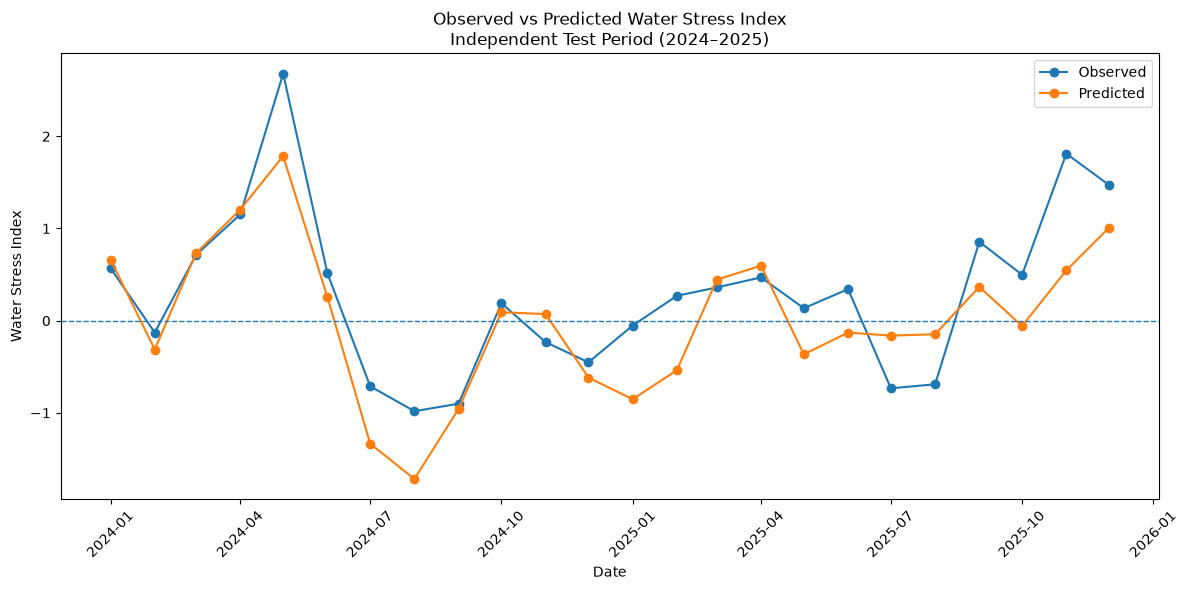

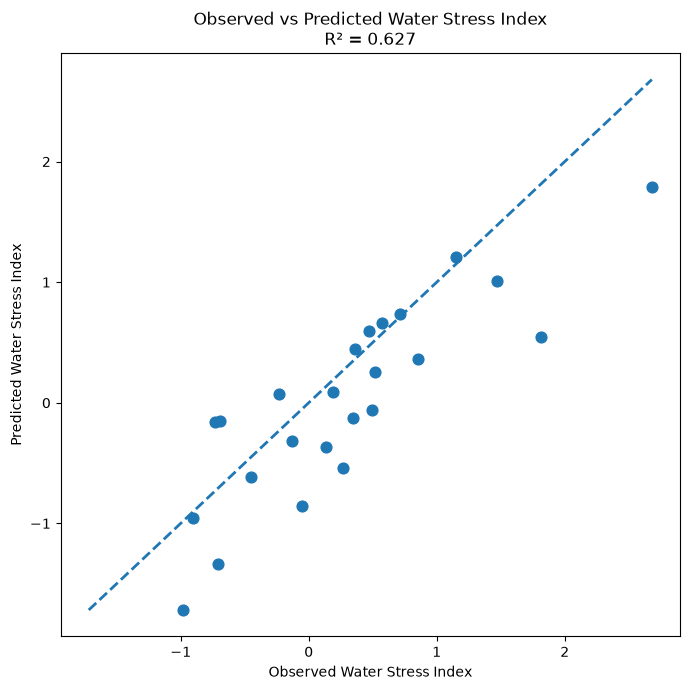

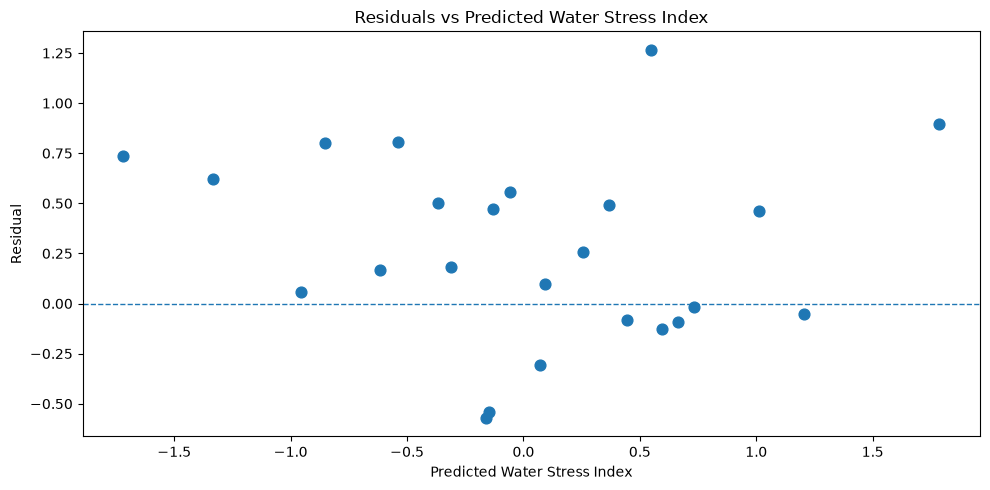

In [226]:
# ============================================================
# FINAL MODEL DIAGNOSTICS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. RESIDUALS
# ------------------------------------------------------------

test_results["residual"] = (
    test_results["actual"]
    - test_results["prediction"]
)

print("=" * 60)
print("RESIDUAL ANALYSIS")
print("=" * 60)

print("Mean residual:",
      test_results["residual"].mean())

print("Residual std:",
      test_results["residual"].std())

print("Mean absolute error:",
      test_results["absolute_error"].mean())

print("Maximum absolute error:",
      test_results["absolute_error"].max())

print("\nLargest errors:")

print(
    test_results[
        [
            "date",
            "actual",
            "prediction",
            "residual",
            "absolute_error"
        ]
    ]
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 2. ACTUAL VS PREDICTED TIME SERIES
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    test_results["date"],
    test_results["actual"],
    marker="o",
    label="Observed"
)

plt.plot(
    test_results["date"],
    test_results["prediction"],
    marker="o",
    label="Predicted"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Water Stress Index")
plt.title(
    "Observed vs Predicted Water Stress Index\n"
    "Independent Test Period (2024–2025)"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 3. OBSERVED VS PREDICTED SCATTER
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    test_results["actual"],
    test_results["prediction"],
    s=60
)

min_value = min(
    test_results["actual"].min(),
    test_results["prediction"].min()
)

max_value = max(
    test_results["actual"].max(),
    test_results["prediction"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Observed Water Stress Index")
plt.ylabel("Predicted Water Stress Index")

plt.title(
    f"Observed vs Predicted Water Stress Index\n"
    f"R² = {test_r2:.3f}"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 4. RESIDUAL PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.scatter(
    test_results["prediction"],
    test_results["residual"],
    s=60
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Predicted Water Stress Index")
plt.ylabel("Residual")

plt.title(
    "Residuals vs Predicted Water Stress Index"
)

plt.tight_layout()

plt.show()

RIDGE MODEL — TEST DIAGNOSTICS
MAE              : 0.4233
RMSE             : 0.5303
R²               : 0.6268
Mean residual    : 0.2738
Residual std     : 0.4639
Maximum error    : 1.2663

ACTUAL VS PREDICTED
      date  actual  prediction  residual  absolute_error
2024-01-01  0.5701      0.6620   -0.0920          0.0920
2024-02-01 -0.1296     -0.3132    0.1836          0.1836
2024-03-01  0.7151      0.7328   -0.0178          0.0178
2024-04-01  1.1527      1.2057   -0.0530          0.0530
2024-05-01  2.6803      1.7858    0.8945          0.8945
2024-06-01  0.5155      0.2574    0.2581          0.2581
2024-07-01 -0.7116     -1.3346    0.6230          0.6230
2024-08-01 -0.9824     -1.7182    0.7358          0.7358
2024-09-01 -0.9006     -0.9560    0.0554          0.0554
2024-10-01  0.1889      0.0911    0.0978          0.0978
2024-11-01 -0.2335      0.0713   -0.3048          0.3048
2024-12-01 -0.4521     -0.6171    0.1649          0.1649
2025-01-01 -0.0528     -0.8530    0.8002          0

C:\Users\Para\AppData\Local\Temp\ipykernel_18908\596688050.py:103: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(4).to_string(index=False)


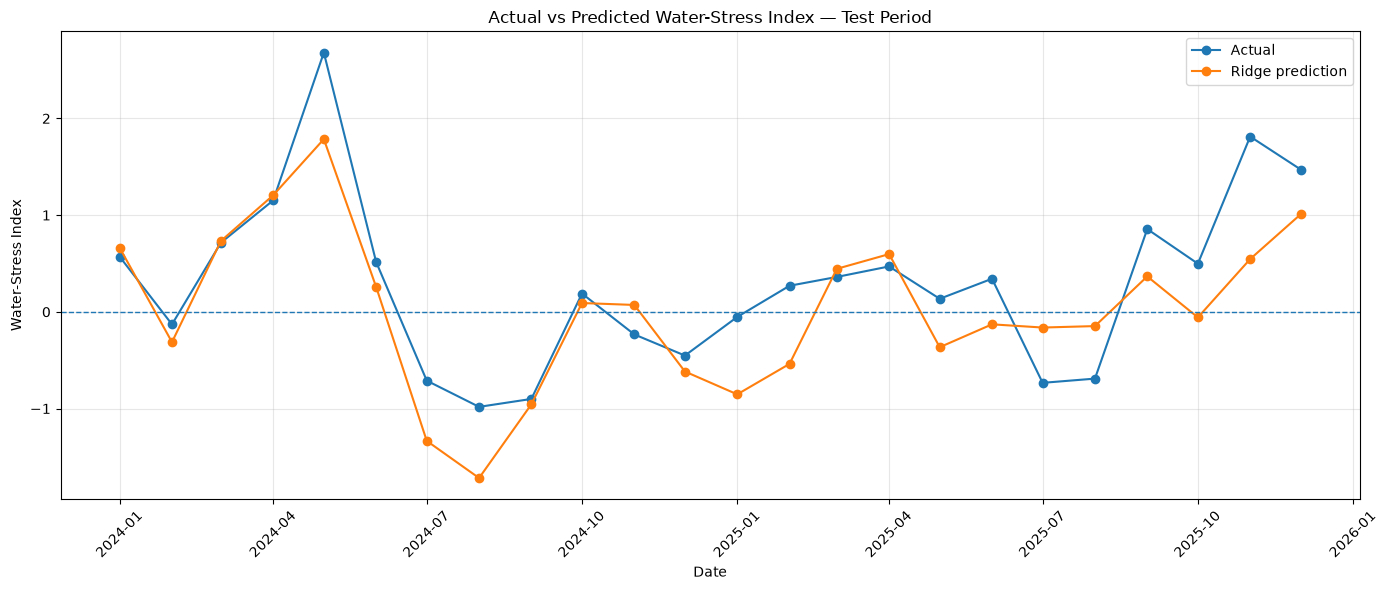

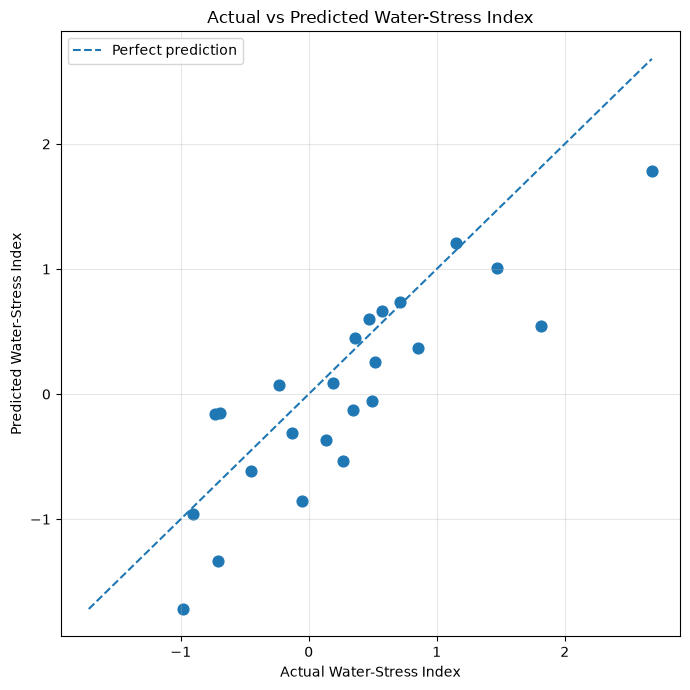

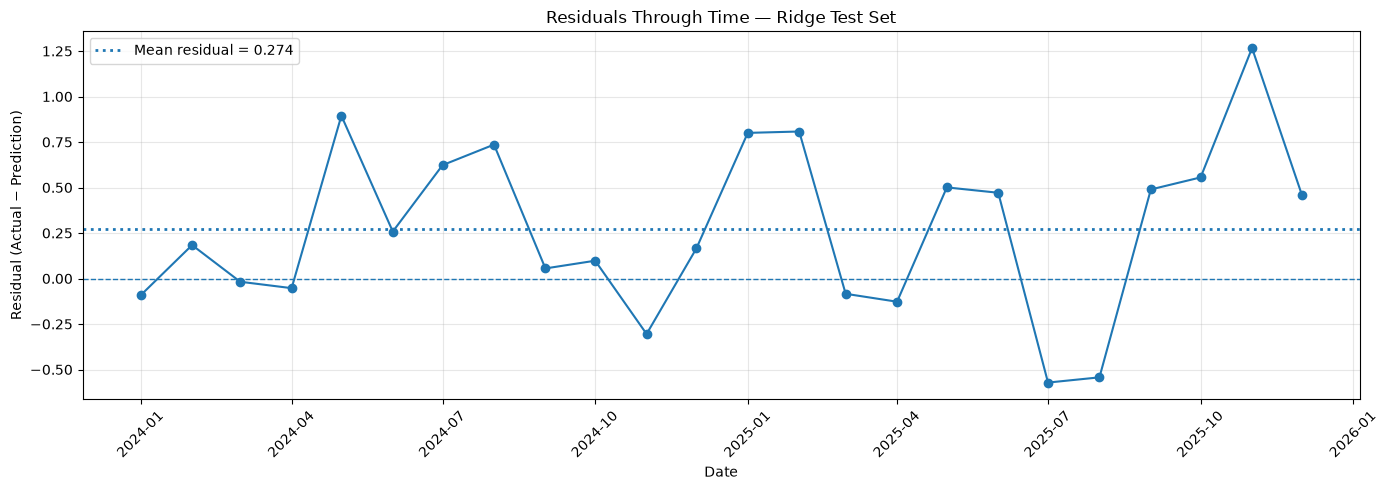

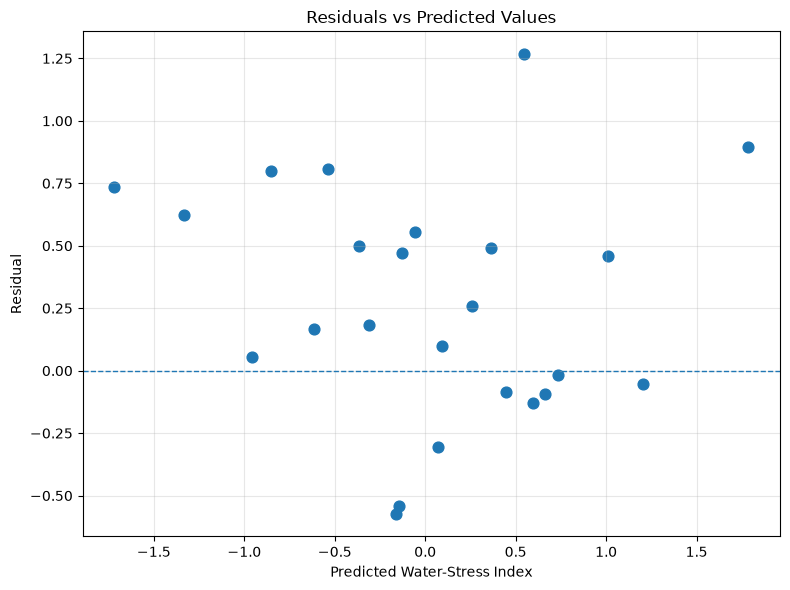

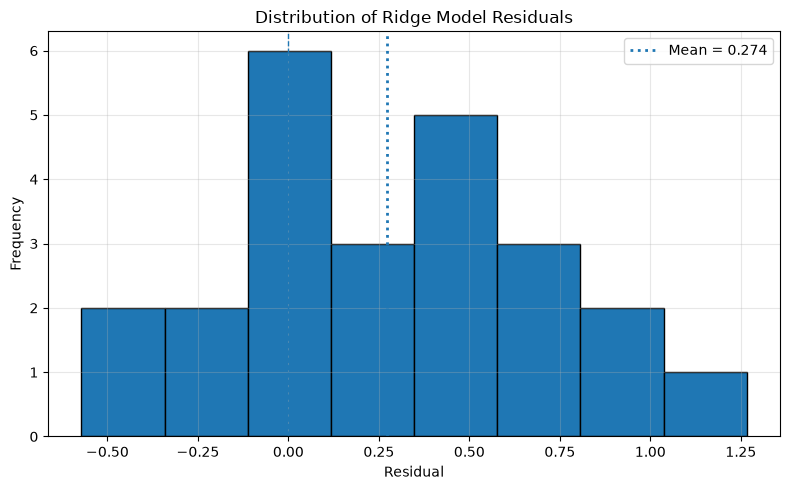


ERROR BY YEAR
 year    MAE   RMSE  Mean_Residual  Max_Error
 2024 0.2901 0.4056         0.2121     0.8945
 2025 0.5565 0.6308         0.3355     1.2663

ERROR BY MONTH
 month    MAE  Mean_Residual
     1 0.4461         0.3541
     2 0.4957         0.4957
     3 0.0509        -0.0509
     4 0.0902        -0.0902
     5 0.6976         0.6976
     6 0.3647         0.3647
     7 0.5974         0.0256
     8 0.6394         0.0964
     9 0.2724         0.2724
    10 0.3267         0.3267
    11 0.7855         0.4807
    12 0.3129         0.3129

PERFORMANCE BY EXTREMES
Extreme observations (|index| >= 1): 4
Non-extreme observations:            20

Extreme MAE : 0.6686
Extreme RMSE: 0.8091

Non-extreme MAE : 0.3742
Non-extreme RMSE: 0.4544

10 LARGEST TEST ERRORS
      date  actual  prediction  residual  absolute_error
2025-11-01  1.8121      0.5458    1.2663          1.2663
2024-05-01  2.6803      1.7858    0.8945          0.8945
2025-02-01  0.2697     -0.5381    0.8077          0.8077
2025

C:\Users\Para\AppData\Local\Temp\ipykernel_18908\596688050.py:389: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(4)


In [227]:
# ============================================================
# RIDGE MODEL — COMPLETE RESIDUAL DIAGNOSTICS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. REBUILD TEST RESULTS SAFELY
# ------------------------------------------------------------

# Make sure predictions are available
if "test_predictions" not in globals():
    test_predictions = final_ridge.predict(X_test)

# Recover test dates from the modelling dataframe
test_dates = df_model.loc[X_test.index, "month_date"].reset_index(drop=True)

actual = pd.Series(
    np.asarray(y_test).ravel(),
    name="actual"
).reset_index(drop=True)

predicted = pd.Series(
    np.asarray(test_predictions).ravel(),
    name="prediction"
).reset_index(drop=True)

test_results = pd.DataFrame({
    "date": test_dates,
    "actual": actual,
    "prediction": predicted
})

# Residual = actual - prediction
test_results["residual"] = (
    test_results["actual"] - test_results["prediction"]
)

test_results["absolute_error"] = (
    test_results["residual"].abs()
)

test_results["squared_error"] = (
    test_results["residual"] ** 2
)

test_results["year"] = test_results["date"].dt.year
test_results["month"] = test_results["date"].dt.month


# ------------------------------------------------------------
# 2. BASIC METRICS
# ------------------------------------------------------------

mae = mean_absolute_error(
    test_results["actual"],
    test_results["prediction"]
)

rmse = np.sqrt(
    mean_squared_error(
        test_results["actual"],
        test_results["prediction"]
    )
)

r2 = r2_score(
    test_results["actual"],
    test_results["prediction"]
)

mean_residual = test_results["residual"].mean()
residual_std = test_results["residual"].std()
max_error = test_results["absolute_error"].max()

print("=" * 60)
print("RIDGE MODEL — TEST DIAGNOSTICS")
print("=" * 60)

print(f"MAE              : {mae:.4f}")
print(f"RMSE             : {rmse:.4f}")
print(f"R²               : {r2:.4f}")
print(f"Mean residual    : {mean_residual:.4f}")
print(f"Residual std     : {residual_std:.4f}")
print(f"Maximum error    : {max_error:.4f}")


# ------------------------------------------------------------
# 3. ACTUAL VS PREDICTED TABLE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ACTUAL VS PREDICTED")
print("=" * 60)

print(
    test_results[
        ["date", "actual", "prediction", "residual", "absolute_error"]
    ].round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 4. PLOT — ACTUAL VS PREDICTED THROUGH TIME
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    test_results["date"],
    test_results["actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    test_results["date"],
    test_results["prediction"],
    marker="o",
    label="Ridge prediction"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Actual vs Predicted Water-Stress Index — Test Period")
plt.xlabel("Date")
plt.ylabel("Water-Stress Index")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. SCATTER — ACTUAL VS PREDICTED
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    test_results["actual"],
    test_results["prediction"],
    s=60
)

# Perfect prediction line
min_value = min(
    test_results["actual"].min(),
    test_results["prediction"].min()
)

max_value = max(
    test_results["actual"].max(),
    test_results["prediction"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual Water-Stress Index")
plt.ylabel("Predicted Water-Stress Index")
plt.title("Actual vs Predicted Water-Stress Index")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. RESIDUALS THROUGH TIME
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    test_results["date"],
    test_results["residual"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    mean_residual,
    linestyle=":",
    linewidth=2,
    label=f"Mean residual = {mean_residual:.3f}"
)

plt.title("Residuals Through Time — Ridge Test Set")
plt.xlabel("Date")
plt.ylabel("Residual (Actual − Prediction)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. RESIDUALS VS PREDICTED VALUES
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    test_results["prediction"],
    test_results["residual"],
    s=60
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Predicted Water-Stress Index")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. RESIDUAL DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    test_results["residual"],
    bins=8,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    mean_residual,
    linestyle=":",
    linewidth=2,
    label=f"Mean = {mean_residual:.3f}"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Ridge Model Residuals")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. ERROR BY YEAR
# ------------------------------------------------------------

year_summary = (
    test_results
    .groupby("year")
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=("squared_error", lambda x: np.sqrt(x.mean())),
        Mean_Residual=("residual", "mean"),
        Max_Error=("absolute_error", "max")
    )
    .reset_index()
)

print("\n" + "=" * 60)
print("ERROR BY YEAR")
print("=" * 60)

print(year_summary.round(4).to_string(index=False))


# ------------------------------------------------------------
# 10. ERROR BY MONTH / SEASON
# ------------------------------------------------------------

month_summary = (
    test_results
    .groupby("month")
    .agg(
        MAE=("absolute_error", "mean"),
        Mean_Residual=("residual", "mean")
    )
    .reset_index()
)

print("\n" + "=" * 60)
print("ERROR BY MONTH")
print("=" * 60)

print(month_summary.round(4).to_string(index=False))


# ------------------------------------------------------------
# 11. EXTREME-WATER-STRESS PERFORMANCE
# ------------------------------------------------------------

# Define extreme observations using |actual| >= 1
extreme_mask = test_results["actual"].abs() >= 1

normal_results = test_results.loc[~extreme_mask]
extreme_results = test_results.loc[extreme_mask]

print("\n" + "=" * 60)
print("PERFORMANCE BY EXTREMES")
print("=" * 60)

print(f"Extreme observations (|index| >= 1): {len(extreme_results)}")
print(f"Non-extreme observations:            {len(normal_results)}")

if len(extreme_results) > 0:
    extreme_mae = mean_absolute_error(
        extreme_results["actual"],
        extreme_results["prediction"]
    )

    extreme_rmse = np.sqrt(
        mean_squared_error(
            extreme_results["actual"],
            extreme_results["prediction"]
        )
    )

    print(f"\nExtreme MAE : {extreme_mae:.4f}")
    print(f"Extreme RMSE: {extreme_rmse:.4f}")

if len(normal_results) > 0:
    normal_mae = mean_absolute_error(
        normal_results["actual"],
        normal_results["prediction"]
    )

    normal_rmse = np.sqrt(
        mean_squared_error(
            normal_results["actual"],
            normal_results["prediction"]
        )
    )

    print(f"\nNon-extreme MAE : {normal_mae:.4f}")
    print(f"Non-extreme RMSE: {normal_rmse:.4f}")


# ------------------------------------------------------------
# 12. LARGEST ERRORS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("10 LARGEST TEST ERRORS")
print("=" * 60)

largest_errors = (
    test_results
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

print(
    largest_errors[
        ["date", "actual", "prediction", "residual", "absolute_error"]
    ]
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 13. BIAS CHECK
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BIAS INTERPRETATION")
print("=" * 60)

if mean_residual > 0.10:
    print(
        "The model shows positive bias: "
        "it tends to UNDERPREDICT the water-stress index."
    )
elif mean_residual < -0.10:
    print(
        "The model shows negative bias: "
        "it tends to OVERPREDICT the water-stress index."
    )
else:
    print(
        "The model shows relatively little systematic bias."
    )

In [229]:
# ============================================================
# BUILD TRAIN / VALIDATION / TEST COMPARISON DATASETS
# ============================================================

# Use the validation variable that actually exists
if "X_validation" in globals():
    X_val_current = X_validation
elif "X_val" in globals():
    X_val_current = X_val
else:
    raise NameError("Neither X_validation nor X_val exists.")

if "y_validation" in globals():
    y_val_current = y_validation
elif "y_val" in globals():
    y_val_current = y_val
else:
    raise NameError("Neither y_validation nor y_val exists.")


# ------------------------------------------------------------
# 1. GET ORIGINAL DATA USING THE SAME INDICES
# ------------------------------------------------------------

train_compare = df_model.loc[X_train.index].copy()
val_compare   = df_model.loc[X_val_current.index].copy()
test_compare  = df_model.loc[X_test.index].copy()


# ------------------------------------------------------------
# 2. ADD ACTUAL TARGET VALUES
# ------------------------------------------------------------

train_compare["actual"] = y_train
val_compare["actual"]   = y_val_current
test_compare["actual"]  = y_test


# ------------------------------------------------------------
# 3. ADD PREDICTIONS
# ------------------------------------------------------------

# These should already exist from your previous modelling steps

if "validation_predictions" in globals():

    # Use Ridge validation predictions if available
    if isinstance(validation_predictions, dict):

        if "Ridge" in validation_predictions:
            val_compare["prediction"] = validation_predictions["Ridge"]
        else:
            # take the first available prediction set
            first_key = list(validation_predictions.keys())[0]
            val_compare["prediction"] = validation_predictions[first_key]

    else:
        val_compare["prediction"] = validation_predictions

elif "val_predictions" in globals():
    val_compare["prediction"] = val_predictions

else:
    print("Validation predictions not found.")


# Test predictions
if "test_predictions" in globals():
    test_compare["prediction"] = test_predictions
else:
    raise NameError("test_predictions does not exist.")


# ------------------------------------------------------------
# 4. RESIDUALS
# ------------------------------------------------------------

if "prediction" in val_compare.columns:
    val_compare["residual"] = (
        val_compare["actual"] - val_compare["prediction"]
    )

    val_compare["absolute_error"] = (
        val_compare["residual"].abs()
    )


test_compare["residual"] = (
    test_compare["actual"] - test_compare["prediction"]
)

test_compare["absolute_error"] = (
    test_compare["residual"].abs()
)


# ------------------------------------------------------------
# 5. SORT BY DATE
# ------------------------------------------------------------

train_compare = train_compare.sort_values("month_date")
val_compare   = val_compare.sort_values("month_date")
test_compare  = test_compare.sort_values("month_date")


# ------------------------------------------------------------
# 6. DISPLAY
# ------------------------------------------------------------

print("=" * 70)
print("TRAIN / VALIDATION / TEST COMPARISON")
print("=" * 70)

print("\nTRAINING PERIOD")
print(
    train_compare["month_date"].min(),
    "to",
    train_compare["month_date"].max()
)

print("Observations:", len(train_compare))


print("\nVALIDATION PERIOD")
print(
    val_compare["month_date"].min(),
    "to",
    val_compare["month_date"].max()
)

print("Observations:", len(val_compare))


print("\nTEST PERIOD")
print(
    test_compare["month_date"].min(),
    "to",
    test_compare["month_date"].max()
)

print("Observations:", len(test_compare))


print("\nTEST RESULTS")
print(
    test_compare[
        ["month_date", "actual", "prediction",
         "residual", "absolute_error"]
    ].round(4).to_string(index=False)
)

TRAIN / VALIDATION / TEST COMPARISON

TRAINING PERIOD
2015-07-01 00:00:00 to 2021-12-01 00:00:00
Observations: 78

VALIDATION PERIOD
2022-01-01 00:00:00 to 2023-12-01 00:00:00
Observations: 24

TEST PERIOD
2024-01-01 00:00:00 to 2025-12-01 00:00:00
Observations: 24

TEST RESULTS
month_date  actual  prediction  residual  absolute_error
2024-01-01  0.5701      0.6620   -0.0920          0.0920
2024-02-01 -0.1296     -0.3132    0.1836          0.1836
2024-03-01  0.7151      0.7328   -0.0178          0.0178
2024-04-01  1.1527      1.2057   -0.0530          0.0530
2024-05-01  2.6803      1.7858    0.8945          0.8945
2024-06-01  0.5155      0.2574    0.2581          0.2581
2024-07-01 -0.7116     -1.3346    0.6230          0.6230
2024-08-01 -0.9824     -1.7182    0.7358          0.7358
2024-09-01 -0.9006     -0.9560    0.0554          0.0554
2024-10-01  0.1889      0.0911    0.0978          0.0978
2024-11-01 -0.2335      0.0713   -0.3048          0.3048
2024-12-01 -0.4521     -0.6171    0.

C:\Users\Para\AppData\Local\Temp\ipykernel_18908\1306573881.py:149: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(4).to_string(index=False)


In [230]:
# ============================================================
# FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 70)
print("FINAL WATER-STRESS ML MODEL PERFORMANCE SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# 1. TEST PERFORMANCE
# ------------------------------------------------------------

test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)

# ------------------------------------------------------------
# 2. PERSISTENCE BASELINE
# ------------------------------------------------------------

# Persistence prediction:
# current prediction = previous observed water-stress index

persistence_predictions = y_test.shift(1)

# First test observation needs the previous month's actual value
previous_actual = y_train.iloc[-1]

persistence_predictions.iloc[0] = previous_actual

baseline_mae = mean_absolute_error(
    y_test,
    persistence_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        persistence_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    persistence_predictions
)

# ------------------------------------------------------------
# 3. IMPROVEMENT OVER BASELINE
# ------------------------------------------------------------

mae_improvement = (
    (baseline_mae - test_mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - test_rmse)
    / baseline_rmse
) * 100

r2_improvement = test_r2 - baseline_r2

# ------------------------------------------------------------
# 4. RESULTS TABLE
# ------------------------------------------------------------

results = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "Final Ridge"
    ],
    "MAE": [
        baseline_mae,
        test_mae
    ],
    "RMSE": [
        baseline_rmse,
        test_rmse
    ],
    "R2": [
        baseline_r2,
        test_r2
    ]
})

print("\nTEST PERFORMANCE")
print(
    results.round(4).to_string(index=False)
)

# ------------------------------------------------------------
# 5. IMPROVEMENT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMPROVEMENT OVER PERSISTENCE BASELINE")
print("=" * 70)

print(f"MAE improvement  : {mae_improvement:.2f}%")
print(f"RMSE improvement : {rmse_improvement:.2f}%")
print(f"R² improvement   : {r2_improvement:.4f}")

# ------------------------------------------------------------
# 6. FINAL MODEL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODEL")
print("=" * 70)

print("Model              : Ridge Regression")
print("Selected features  : 50")
print("Training period    : 2015-07 to 2021-12")
print("Validation period  : 2022-01 to 2023-12")
print("Test period        : 2024-01 to 2025-12")

print("\nFinal test metrics:")
print(f"MAE                : {test_mae:.4f}")
print(f"RMSE               : {test_rmse:.4f}")
print(f"R²                 : {test_r2:.4f}")

print("\nResidual diagnostics:")
print(f"Mean residual      : {np.mean(y_test - test_predictions):.4f}")
print(f"Residual std       : {np.std(y_test - test_predictions):.4f}")
print(
    f"Maximum error      : "
    f"{np.max(np.abs(y_test - test_predictions)):.4f}"
)

FINAL WATER-STRESS ML MODEL PERFORMANCE SUMMARY

TEST PERFORMANCE
               Model    MAE   RMSE     R2
Persistence Baseline 0.6369 0.8514 0.0378
         Final Ridge 0.4233 0.5303 0.6268

IMPROVEMENT OVER PERSISTENCE BASELINE
MAE improvement  : 33.54%
RMSE improvement : 37.72%
R² improvement   : 0.5889

FINAL MODEL
Model              : Ridge Regression
Selected features  : 50
Training period    : 2015-07 to 2021-12
Validation period  : 2022-01 to 2023-12
Test period        : 2024-01 to 2025-12

Final test metrics:
MAE                : 0.4233
RMSE               : 0.5303
R²                 : 0.6268

Residual diagnostics:
Mean residual      : 0.2738
Residual std       : 0.4541
Maximum error      : 1.2663


In [232]:
# ============================================================
# INSPECT FINAL RIDGE PIPELINE
# ============================================================

print("Final Ridge pipeline:")
print(final_ridge)

print("\nPipeline steps:")
print(final_ridge.named_steps)

print("\nStep names:")
print(list(final_ridge.named_steps.keys()))

Final Ridge pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('ridge', Ridge(alpha=0.01))])

Pipeline steps:
{'imputer': SimpleImputer(strategy='median'), 'scaler': StandardScaler(), 'ridge': Ridge(alpha=0.01)}

Step names:
['imputer', 'scaler', 'ridge']


In [233]:
# ============================================================
# FIND RIDGE ESTIMATOR AUTOMATICALLY
# ============================================================

from sklearn.linear_model import Ridge

ridge_estimator = None

for step_name, step in final_ridge.named_steps.items():
    if isinstance(step, Ridge):
        ridge_estimator = step
        print(f"Ridge estimator found in step: '{step_name}'")
        break

if ridge_estimator is None:
    raise ValueError(
        "No Ridge estimator was found inside final_ridge."
    )

print("\nRidge alpha:")
print(ridge_estimator.alpha)

print("\nNumber of coefficients:")
print(len(ridge_estimator.coef_))

Ridge estimator found in step: 'ridge'

Ridge alpha:
0.01

Number of coefficients:
50


In [235]:
# ============================================================
# FIND THE 50 FEATURES USED BY THE FINAL RIDGE MODEL
# ============================================================

print("Available variables related to X:")
print([
    name for name in globals()
    if name.startswith("X_")
])

print("\nFinal Ridge:")
print(final_ridge)

Available variables related to X:
['X_train', 'X_val', 'X_test', 'X_train_model', 'X_val_model', 'X_train_full', 'X_val_full', 'X_train_50', 'X_val_50', 'X_cv', 'X_train_cv', 'X_val_cv', 'X_diag', 'X_train_f2', 'X_val_f2', 'X_train_final', 'X_val_final', 'X_test_final', 'X_val_current']

Final Ridge:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('ridge', Ridge(alpha=0.01))])


In [236]:
# ============================================================
# GET THE 50 FEATURES USED BY FINAL RIDGE
# ============================================================

feature_names = X_train_50.columns.tolist()

print("=" * 70)
print("FINAL RIDGE FEATURE CHECK")
print("=" * 70)

print("Number of feature names:", len(feature_names))
print("Number of Ridge coefficients:", len(ridge_estimator.coef_))

if len(feature_names) != len(ridge_estimator.coef_):
    raise ValueError(
        f"Mismatch: {len(feature_names)} feature names "
        f"but {len(ridge_estimator.coef_)} coefficients."
    )

print("\nFEATURES:")
for i, feature in enumerate(feature_names, 1):
    print(f"{i:02d}. {feature}")

FINAL RIDGE FEATURE CHECK
Number of feature names: 50
Number of Ridge coefficients: 50

FEATURES:
01. pet_3month
02. precipitation_3month
03. temperature_max_c
04. pet_mm_lag1
05. soil_moisture_layer2
06. pet_mm
07. pet_6month
08. precipitation_mm
09. temperature_max_c_lag1
10. pet_mm_lag2
11. soil_moisture_layer1
12. precipitation_mm_lag1
13. precipitation_mm_lag2
14. solar_radiation_lag2
15. solar_radiation_lag1
16. temperature_max_c_lag2
17. soil_moisture_layer2_lag1
18. soil_moisture_layer1_lag2
19. solar_radiation
20. precipitation_6month
21. soil_moisture_layer1_lag1
22. soil_moisture_layer2_lag2
23. surface_runoff_mm_lag2
24. runoff_mm_lag2
25. surface_runoff_mm_lag1
26. temperature_mean_c
27. runoff_mm_lag1
28. surface_runoff_mm
29. temperature_mean_c_lag1
30. runoff_mm
31. temperature_mean_c_lag2
32. soil_moisture_layer2_lag3
33. pet_mm_lag3
34. wind_speed_lag1
35. wind_speed
36. surface_runoff_mm_lag3
37. temperature_max_c_lag3
38. runoff_mm_lag3
39. temperature_min_c
40. tem

In [237]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ridge_estimator.coef_
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

coef_df["Rank"] = range(1, len(coef_df) + 1)

print("=" * 70)
print("FINAL RIDGE COEFFICIENTS — 50 FEATURES")
print("=" * 70)

print(
    coef_df[
        ["Rank", "Feature", "Coefficient", "Absolute_Coefficient"]
    ].round(4).to_string(index=False)
)

print("\n" + "=" * 70)
print("TOP 20 RIDGE FEATURES")
print("=" * 70)

print(
    coef_df.head(20)[
        ["Rank", "Feature", "Coefficient"]
    ].round(4).to_string(index=False)
)

FINAL RIDGE COEFFICIENTS — 50 FEATURES
 Rank                   Feature  Coefficient  Absolute_Coefficient
    1    temperature_min_c_lag2      -2.2602                2.2602
    2   temperature_mean_c_lag2       2.0965                2.0965
    3        temperature_mean_c      -2.0492                2.0492
    4   temperature_mean_c_lag1      -1.7499                1.7499
    5           dewpoint_c_lag1       1.4842                1.4842
    6                dewpoint_c       1.3134                1.3134
    7    surface_runoff_mm_lag1      -1.1654                1.1654
    8           dewpoint_c_lag2       1.0675                1.0675
    9            runoff_mm_lag1       1.0655                1.0655
   10    temperature_max_c_lag2      -1.0431                1.0431
   11           solar_radiation      -0.7127                0.7127
   12            runoff_mm_lag3      -0.7082                0.7082
   13                 month_cos      -0.6886                0.6886
   14    surface_runoff

In [238]:
# ============================================================
# GROUP-LEVEL FEATURE IMPORTANCE — FINAL RIDGE MODEL
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. COPY COEFFICIENT DATA
# ------------------------------------------------------------

group_df = coef_df.copy()

# ------------------------------------------------------------
# 2. DEFINE FEATURE GROUPS
# ------------------------------------------------------------

def assign_feature_group(feature):

    # Temperature
    if feature.startswith("temperature_"):
        return "Temperature"

    # Precipitation
    elif feature.startswith("precipitation_"):
        return "Precipitation"

    # Potential evapotranspiration
    elif feature.startswith("pet_"):
        return "PET"

    # Soil moisture
    elif feature.startswith("soil_moisture_"):
        return "Soil Moisture"

    # Runoff
    elif feature.startswith("surface_runoff_"):
        return "Surface Runoff"

    elif feature.startswith("runoff_"):
        return "Runoff"

    # Solar radiation
    elif feature.startswith("solar_radiation"):
        return "Solar Radiation"

    # Wind
    elif feature.startswith("wind_speed"):
        return "Wind"

    # Dew point
    elif feature.startswith("dewpoint"):
        return "Dew Point"

    # Seasonal variable
    elif feature.startswith("month_"):
        return "Seasonality"

    else:
        return "Other"


group_df["Group"] = group_df["Feature"].apply(assign_feature_group)

# ------------------------------------------------------------
# 3. ABSOLUTE COEFFICIENT
# ------------------------------------------------------------

group_df["Absolute_Coefficient"] = (
    group_df["Coefficient"].abs()
)

# ------------------------------------------------------------
# 4. GROUP SUMMARY
# ------------------------------------------------------------

group_summary = (
    group_df
    .groupby("Group")
    .agg(
        Features=("Feature", "count"),
        Total_Absolute_Coefficient=(
            "Absolute_Coefficient", "sum"
        ),
        Mean_Absolute_Coefficient=(
            "Absolute_Coefficient", "mean"
        ),
        Maximum_Absolute_Coefficient=(
            "Absolute_Coefficient", "max"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# 5. PERCENTAGE OF TOTAL COEFFICIENT MAGNITUDE
# ------------------------------------------------------------

total_abs = group_summary[
    "Total_Absolute_Coefficient"
].sum()

group_summary["Importance_Percent"] = (
    group_summary["Total_Absolute_Coefficient"]
    / total_abs
    * 100
)

# ------------------------------------------------------------
# 6. SORT BY TOTAL IMPORTANCE
# ------------------------------------------------------------

group_summary = (
    group_summary
    .sort_values(
        "Total_Absolute_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. ADD RANK
# ------------------------------------------------------------

group_summary["Rank"] = range(
    1,
    len(group_summary) + 1
)

# ------------------------------------------------------------
# 8. DISPLAY
# ------------------------------------------------------------

print("=" * 80)
print("GROUP-LEVEL FEATURE IMPORTANCE — FINAL RIDGE MODEL")
print("=" * 80)

print(
    group_summary[
        [
            "Rank",
            "Group",
            "Features",
            "Total_Absolute_Coefficient",
            "Mean_Absolute_Coefficient",
            "Maximum_Absolute_Coefficient",
            "Importance_Percent"
        ]
    ]
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 9. CHECK ALL FEATURES WERE ASSIGNED
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE GROUP CHECK")
print("=" * 80)

print(
    group_df[
        ["Feature", "Group"]
    ]
    .sort_values("Group")
    .to_string(index=False)
)

print("\nNumber of features:", len(group_df))
print(
    "Number successfully grouped:",
    group_df["Group"].notna().sum()
)

GROUP-LEVEL FEATURE IMPORTANCE — FINAL RIDGE MODEL
 Rank           Group  Features  Total_Absolute_Coefficient  Mean_Absolute_Coefficient  Maximum_Absolute_Coefficient  Importance_Percent
    1     Temperature        12                     11.8361                     0.9863                        2.2602             38.4400
    2       Dew Point         3                      3.8651                     1.2884                        1.4842             12.5526
    3  Surface Runoff         4                      3.0693                     0.7673                        1.1654              9.9679
    4          Runoff         4                      2.8575                     0.7144                        1.0655              9.2801
    5             PET         6                      2.3823                     0.3970                        0.5864              7.7369
    6 Solar Radiation         4                      2.1265                     0.5316                        0.7127           

In [239]:
# ============================================================
# DIRECTIONAL GROUP ANALYSIS
# ============================================================

direction_summary = (
    group_df
    .groupby("Group")
    .agg(
        Positive_Features=(
            "Coefficient",
            lambda x: (x > 0).sum()
        ),
        Negative_Features=(
            "Coefficient",
            lambda x: (x < 0).sum()
        ),
        Mean_Coefficient=(
            "Coefficient",
            "mean"
        ),
        Sum_Coefficient=(
            "Coefficient",
            "sum"
        )
    )
    .reset_index()
)

direction_summary = (
    direction_summary
    .sort_values(
        "Mean_Coefficient",
        ascending=False
    )
)

print("=" * 80)
print("DIRECTIONAL GROUP ANALYSIS")
print("=" * 80)

print(
    direction_summary
    .round(4)
    .to_string(index=False)
)

DIRECTIONAL GROUP ANALYSIS
          Group  Positive_Features  Negative_Features  Mean_Coefficient  Sum_Coefficient
      Dew Point                  3                  0            1.2884           3.8651
         Runoff                  3                  1            0.3603           1.4411
            PET                  5                  1            0.3429           2.0575
  Precipitation                  4                  1            0.2398           1.1989
  Soil Moisture                  5                  3            0.0342           0.2736
           Wind                  1                  2            0.0006           0.0019
    Temperature                  6                  6           -0.3806          -4.5675
 Surface Runoff                  1                  3           -0.4232          -1.6929
Solar Radiation                  0                  4           -0.5316          -2.1265
    Seasonality                  0                  1           -0.6886          -0

In [241]:
# ============================================================
# VIF / MULTICOLLINEARITY ANALYSIS — FINAL MODEL
# ============================================================

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

print("=" * 70)
print("VIF / MULTICOLLINEARITY ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. IDENTIFY THE FINAL 50 FEATURES
# ------------------------------------------------------------

# We already confirmed these are the features used by the final Ridge
feature_names = X_train_50.columns.tolist()

print(f"\nNumber of features: {len(feature_names)}")

# ------------------------------------------------------------
# 2. USE TRAINING DATA ONLY
# ------------------------------------------------------------

X_vif = X_train_50[feature_names].copy()

print(f"Training observations: {X_vif.shape[0]}")
print(f"Training features: {X_vif.shape[1]}")

# ------------------------------------------------------------
# 3. HANDLE MISSING VALUES
# ------------------------------------------------------------

imputer = SimpleImputer(strategy="median")

X_vif_imputed = pd.DataFrame(
    imputer.fit_transform(X_vif),
    columns=feature_names,
    index=X_vif.index
)

# ------------------------------------------------------------
# 4. STANDARDIZE FEATURES
# ------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_vif_scaled = pd.DataFrame(
    scaler.fit_transform(X_vif_imputed),
    columns=feature_names,
    index=X_vif.index
)

# ------------------------------------------------------------
# 5. CALCULATE VIF MANUALLY
# ------------------------------------------------------------

vif_results = []

for feature in feature_names:

    y = X_vif_scaled[feature]

    other_features = [
        f for f in feature_names
        if f != feature
    ]

    X_other = X_vif_scaled[other_features]

    # R² from regressing this feature against all other features
    from sklearn.linear_model import LinearRegression

    model = LinearRegression()
    model.fit(X_other, y)

    r2 = model.score(X_other, y)

    # Protect against numerical problems
    if r2 >= 0.999999:
        vif = np.inf
    else:
        vif = 1 / (1 - r2)

    vif_results.append({
        "Feature": feature,
        "R2": r2,
        "VIF": vif
    })

vif_df = pd.DataFrame(vif_results)

# ------------------------------------------------------------
# 6. SORT BY VIF
# ------------------------------------------------------------

vif_df = vif_df.sort_values(
    "VIF",
    ascending=False
).reset_index(drop=True)

vif_df["Rank"] = range(1, len(vif_df) + 1)

# ------------------------------------------------------------
# 7. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VIF RESULTS — ALL 50 FEATURES")
print("=" * 70)

print(
    vif_df[
        ["Rank", "Feature", "VIF", "R2"]
    ].round(4).to_string(index=False)
)

# ------------------------------------------------------------
# 8. MULTICOLLINEARITY CLASSIFICATION
# ------------------------------------------------------------

def classify_vif(vif):

    if np.isinf(vif):
        return "Extreme"

    elif vif >= 10:
        return "Severe"

    elif vif >= 5:
        return "High"

    elif vif >= 2.5:
        return "Moderate"

    else:
        return "Low"


vif_df["Multicollinearity"] = vif_df["VIF"].apply(classify_vif)

# ------------------------------------------------------------
# 9. SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MULTICOLLINEARITY SUMMARY")
print("=" * 70)

print(
    vif_df["Multicollinearity"]
    .value_counts()
    .to_string()
)

print("\nHighest VIF:")
print(vif_df.iloc[0][
    ["Feature", "VIF", "Multicollinearity"]
])

print("\nMedian VIF:", round(vif_df["VIF"].median(), 4))
print("Mean VIF:", round(vif_df["VIF"].mean(), 4))

# ------------------------------------------------------------
# 10. FEATURES WITH VIF > 10
# ------------------------------------------------------------

severe_vif = vif_df[vif_df["VIF"] >= 10]

print("\n" + "=" * 70)
print("FEATURES WITH VIF >= 10")
print("=" * 70)

if len(severe_vif) == 0:
    print("None")

else:
    print(
        severe_vif[
            ["Rank", "Feature", "VIF"]
        ].round(4).to_string(index=False)
    )

# ------------------------------------------------------------
# 11. FEATURES WITH VIF > 5
# ------------------------------------------------------------

high_vif = vif_df[vif_df["VIF"] >= 5]

print("\n" + "=" * 70)
print("FEATURES WITH VIF >= 5")
print("=" * 70)

if len(high_vif) == 0:
    print("None")

else:
    print(
        high_vif[
            ["Rank", "Feature", "VIF"]
        ].round(4).to_string(index=False)
    )

VIF / MULTICOLLINEARITY ANALYSIS

Number of features: 50
Training observations: 78
Training features: 50

VIF RESULTS — ALL 50 FEATURES
 Rank                   Feature       VIF     R2
    1                pet_3month       inf 1.0000
    2      precipitation_3month       inf 1.0000
    3               pet_mm_lag1       inf 1.0000
    4                    pet_mm       inf 1.0000
    5               pet_mm_lag2       inf 1.0000
    6          precipitation_mm       inf 1.0000
    7     precipitation_mm_lag2       inf 1.0000
    8     precipitation_mm_lag1       inf 1.0000
    9   temperature_mean_c_lag1 2671.4213 0.9996
   10   temperature_mean_c_lag2 2502.2909 0.9996
   11   temperature_mean_c_lag3 2432.0855 0.9996
   12        temperature_mean_c 2398.7157 0.9996
   13    surface_runoff_mm_lag1 1594.1072 0.9994
   14            runoff_mm_lag1 1466.8218 0.9993
   15    surface_runoff_mm_lag2 1455.0754 0.9993
   16         surface_runoff_mm 1449.9408 0.9993
   17                 runoff_mm

In [242]:
print(df_model.shape)
print(df_model.columns.tolist())
print(df_model.head())

(126, 63)
['month_date', 'precipitation_mm', 'pet_mm', 'temperature_mean_c', 'temperature_min_c', 'temperature_max_c', 'dewpoint_c', 'soil_moisture_layer1', 'soil_moisture_layer2', 'runoff_mm', 'surface_runoff_mm', 'solar_radiation', 'wind_speed', 'surface_pressure_kpa', 'month', 'season', 'precipitation_mm_lag1', 'precipitation_mm_lag2', 'precipitation_mm_lag3', 'pet_mm_lag1', 'pet_mm_lag2', 'pet_mm_lag3', 'temperature_mean_c_lag1', 'temperature_mean_c_lag2', 'temperature_mean_c_lag3', 'temperature_min_c_lag1', 'temperature_min_c_lag2', 'temperature_min_c_lag3', 'temperature_max_c_lag1', 'temperature_max_c_lag2', 'temperature_max_c_lag3', 'dewpoint_c_lag1', 'dewpoint_c_lag2', 'dewpoint_c_lag3', 'soil_moisture_layer1_lag1', 'soil_moisture_layer1_lag2', 'soil_moisture_layer1_lag3', 'soil_moisture_layer2_lag1', 'soil_moisture_layer2_lag2', 'soil_moisture_layer2_lag3', 'runoff_mm_lag1', 'runoff_mm_lag2', 'runoff_mm_lag3', 'surface_runoff_mm_lag1', 'surface_runoff_mm_lag2', 'surface_runoff

In [245]:
# ============================================================
# TRUE 1-MONTH-AHEAD WATER-STRESS FORECAST DATASET
# X(t) -> WSI(t+1)
# ============================================================

import pandas as pd
import numpy as np

# Start from the monthly dataframe already created
df_forecast = (
    df_monthly
    .sort_values("month_date")
    .reset_index(drop=True)
    .copy()
)

# ------------------------------------------------------------
# 1. CREATE TEMPORAL FEATURES AVAILABLE AT MONTH t
# ------------------------------------------------------------

lag_variables = [
    "precipitation_mm",
    "pet_mm",
    "temperature_mean_c",
    "temperature_min_c",
    "temperature_max_c",
    "dewpoint_c",
    "soil_moisture_layer1",
    "soil_moisture_layer2",
    "runoff_mm",
    "surface_runoff_mm",
    "solar_radiation",
    "wind_speed",
    "surface_pressure_kpa"
]

for variable in lag_variables:
    for lag in [1, 2, 3]:
        df_forecast[f"{variable}_lag{lag}"] = (
            df_forecast[variable].shift(lag)
        )

# ------------------------------------------------------------
# 2. ANTECEDENT ACCUMULATED VARIABLES
# These use information available BEFORE / UP TO month t
# ------------------------------------------------------------

df_forecast["precipitation_3month"] = (
    df_forecast["precipitation_mm"]
    .rolling(window=3, min_periods=3)
    .sum()
)

df_forecast["precipitation_6month"] = (
    df_forecast["precipitation_mm"]
    .rolling(window=6, min_periods=6)
    .sum()
)

df_forecast["pet_3month"] = (
    df_forecast["pet_mm"]
    .rolling(window=3, min_periods=3)
    .sum()
)

df_forecast["pet_6month"] = (
    df_forecast["pet_mm"]
    .rolling(window=6, min_periods=6)
    .sum()
)

# ------------------------------------------------------------
# 3. CYCLICAL SEASONAL FEATURES FOR MONTH t
# ------------------------------------------------------------

df_forecast["calendar_month"] = (
    df_forecast["month_date"].dt.month
)

df_forecast["month_sin"] = np.sin(
    2 * np.pi * df_forecast["calendar_month"] / 12
)

df_forecast["month_cos"] = np.cos(
    2 * np.pi * df_forecast["calendar_month"] / 12
)

# ------------------------------------------------------------
# 4. SHIFT TARGET ONE MONTH INTO THE FUTURE
# ------------------------------------------------------------

df_forecast["target_t_plus_1"] = (
    df_forecast["water_stress_index"].shift(-1)
)

# Also keep the date that is actually being forecast
df_forecast["forecast_date"] = (
    df_forecast["month_date"].shift(-1)
)

print("=" * 70)
print("1-MONTH-AHEAD FORECAST DATASET CREATED")
print("=" * 70)

print(
    df_forecast[
        [
            "month_date",
            "forecast_date",
            "water_stress_index",
            "target_t_plus_1"
        ]
    ].tail(10)
)

1-MONTH-AHEAD FORECAST DATASET CREATED
    month_date forecast_date  water_stress_index  target_t_plus_1
122 2025-03-01    2025-04-01            0.360709         0.469423
123 2025-04-01    2025-05-01            0.469423         0.134986
124 2025-05-01    2025-06-01            0.134986         0.342066
125 2025-06-01    2025-07-01            0.342066        -0.734084
126 2025-07-01    2025-08-01           -0.734084        -0.690398
127 2025-08-01    2025-09-01           -0.690398         0.855663
128 2025-09-01    2025-10-01            0.855663         0.497818
129 2025-10-01    2025-11-01            0.497818         1.812108
130 2025-11-01    2025-12-01            1.812108         1.470839
131 2025-12-01           NaT            1.470839              NaN


In [246]:
# ============================================================
# LEAKAGE-FREE t+1 PREDICTOR SET
# ============================================================

target = "target_t_plus_1"

exclude_columns = [
    # Dates / targets
    "month_date",
    "forecast_date",
    "water_stress_index",
    "water_stress_class",
    target,

    # Direct water-balance variables
    "water_balance_mm",
    "water_balance_3month",
    "water_balance_6month",

    # Statistics used to construct the original WSI
    "wb3_mean",
    "wb3_std",

    # Avoid year as a trend shortcut
    "year",

    # Categorical season string
    "season"
]

exclude_columns = [
    col for col in exclude_columns
    if col in df_forecast.columns
]

predictor_columns = [
    col for col in df_forecast.columns
    if col not in exclude_columns
]

print("Predictors before filtering:", len(predictor_columns))

# Keep only rows where:
# 1. future target exists
# 2. all predictor values exist

df_forecast_model = (
    df_forecast
    .dropna(
        subset=[target] + predictor_columns
    )
    .copy()
    .reset_index(drop=True)
)

print("\nFinal t+1 dataset shape:")
print(df_forecast_model.shape)

print("\nPredictors:")
print(len(predictor_columns))

print("\nInput period:")
print(
    df_forecast_model["month_date"].min(),
    "to",
    df_forecast_model["month_date"].max()
)

print("\nForecast target period:")
print(
    df_forecast_model["forecast_date"].min(),
    "to",
    df_forecast_model["forecast_date"].max()
)

print("\nMissing values:")
print(
    df_forecast_model[predictor_columns + [target]]
    .isna()
    .sum()
    .sum()
)

Predictors before filtering: 60

Final t+1 dataset shape:
(126, 72)

Predictors:
60

Input period:
2015-06-01 00:00:00 to 2025-11-01 00:00:00

Forecast target period:
2015-07-01 00:00:00 to 2025-12-01 00:00:00

Missing values:
0


In [247]:
# ============================================================
# CHRONOLOGICAL t+1 TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_mask = (
    df_forecast_model["forecast_date"]
    <= "2021-12-01"
)

val_mask = (
    (df_forecast_model["forecast_date"] >= "2022-01-01")
    &
    (df_forecast_model["forecast_date"] <= "2023-12-01")
)

test_mask = (
    (df_forecast_model["forecast_date"] >= "2024-01-01")
    &
    (df_forecast_model["forecast_date"] <= "2025-12-01")
)

X_train_full = (
    df_forecast_model.loc[
        train_mask,
        predictor_columns
    ].copy()
)

y_train = (
    df_forecast_model.loc[
        train_mask,
        target
    ].copy()
)

X_val_full = (
    df_forecast_model.loc[
        val_mask,
        predictor_columns
    ].copy()
)

y_val = (
    df_forecast_model.loc[
        val_mask,
        target
    ].copy()
)

X_test_full = (
    df_forecast_model.loc[
        test_mask,
        predictor_columns
    ].copy()
)

y_test = (
    df_forecast_model.loc[
        test_mask,
        target
    ].copy()
)

print("=" * 70)
print("TRUE t+1 CHRONOLOGICAL SPLIT")
print("=" * 70)

print("\nTraining:")
print(X_train_full.shape)
print(
    df_forecast_model.loc[
        train_mask,
        "forecast_date"
    ].min(),
    "to",
    df_forecast_model.loc[
        train_mask,
        "forecast_date"
    ].max()
)

print("\nValidation:")
print(X_val_full.shape)
print(
    df_forecast_model.loc[
        val_mask,
        "forecast_date"
    ].min(),
    "to",
    df_forecast_model.loc[
        val_mask,
        "forecast_date"
    ].max()
)

print("\nTest:")
print(X_test_full.shape)
print(
    df_forecast_model.loc[
        test_mask,
        "forecast_date"
    ].min(),
    "to",
    df_forecast_model.loc[
        test_mask,
        "forecast_date"
    ].max()
)

TRUE t+1 CHRONOLOGICAL SPLIT

Training:
(78, 60)
2015-07-01 00:00:00 to 2021-12-01 00:00:00

Validation:
(24, 60)
2022-01-01 00:00:00 to 2023-12-01 00:00:00

Test:
(24, 60)
2024-01-01 00:00:00 to 2025-12-01 00:00:00


In [248]:
# ============================================================
# t+1 FEATURE RANKING — TRAINING DATA ONLY
# ============================================================

train_corr = (
    pd.concat(
        [
            X_train_full,
            y_train.rename(target)
        ],
        axis=1
    )
    .corr(numeric_only=True)[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False)
)

print("=" * 70)
print("TOP 20 t+1 PREDICTORS — TRAINING DATA ONLY")
print("=" * 70)

print(train_corr.head(20))

TOP 20 t+1 PREDICTORS — TRAINING DATA ONLY
pet_mm                       0.300121
temperature_max_c            0.278813
pet_mm_lag1                  0.274141
precipitation_mm             0.270342
precipitation_mm_lag1        0.268241
pet_3month                   0.257311
solar_radiation_lag1         0.250822
solar_radiation              0.240195
temperature_max_c_lag1       0.238803
soil_moisture_layer2         0.228155
soil_moisture_layer1_lag1    0.227049
precipitation_3month         0.223424
pet_6month                   0.220428
soil_moisture_layer1         0.211811
soil_moisture_layer2_lag1    0.189875
surface_runoff_mm_lag1       0.188775
runoff_mm_lag1               0.182123
soil_moisture_layer2_lag3    0.165857
surface_runoff_mm            0.163480
runoff_mm                    0.156990
Name: target_t_plus_1, dtype: float64


In [249]:
# ============================================================
# t+1 FEATURE-COUNT SELECTION
# VALIDATION ONLY — TEST UNTOUCHED
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

feature_counts = [
    5, 10, 15, 20, 30, 40, 50
]

feature_results = []

for n_features in feature_counts:

    n = min(
        n_features,
        len(train_corr)
    )

    selected = (
        train_corr.head(n)
        .index.tolist()
    )

    Xtr = X_train_full[selected]
    Xv = X_val_full[selected]

    model = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "ridge",
            Ridge(alpha=1.0)
        )
    ])

    model.fit(Xtr, y_train)

    pred = model.predict(Xv)

    mae = mean_absolute_error(
        y_val,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            pred
        )
    )

    r2 = r2_score(
        y_val,
        pred
    )

    feature_results.append({
        "Features": n,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

feature_results_df = pd.DataFrame(
    feature_results
)

print("=" * 70)
print("t+1 FEATURE COUNT COMPARISON")
print("=" * 70)

print(
    feature_results_df
    .sort_values("RMSE")
    .round(4)
    .to_string(index=False)
)

best_row = (
    feature_results_df.loc[
        feature_results_df["RMSE"].idxmin()
    ]
)

best_n = int(
    best_row["Features"]
)

selected_features_t1 = (
    train_corr.head(best_n)
    .index.tolist()
)

print("\nBest feature count:", best_n)

print("\nSelected t+1 features:")

for i, f in enumerate(
    selected_features_t1,
    1
):
    print(f"{i:02d}. {f}")

t+1 FEATURE COUNT COMPARISON
 Features    MAE   RMSE      R2
       15 0.7155 1.0135  0.2060
       20 0.7394 1.0242  0.1892
       10 0.8167 1.0616  0.1288
        5 0.8591 1.0869  0.0868
       30 0.8191 1.0882  0.0847
       50 0.8343 1.1091  0.0491
       40 0.8903 1.1580 -0.0365

Best feature count: 15

Selected t+1 features:
01. pet_mm
02. temperature_max_c
03. pet_mm_lag1
04. precipitation_mm
05. precipitation_mm_lag1
06. pet_3month
07. solar_radiation_lag1
08. solar_radiation
09. temperature_max_c_lag1
10. soil_moisture_layer2
11. soil_moisture_layer1_lag1
12. precipitation_3month
13. pet_6month
14. soil_moisture_layer1
15. soil_moisture_layer2_lag1


In [250]:
# ============================================================
# t+1 RIDGE ALPHA TUNING
# ============================================================

alphas = [
    0.01,
    0.05,
    0.1,
    0.5,
    1,
    2,
    5,
    10,
    20,
    50,
    100
]

X_train_selected = (
    X_train_full[
        selected_features_t1
    ].copy()
)

X_val_selected = (
    X_val_full[
        selected_features_t1
    ].copy()
)

alpha_results = []

for alpha in alphas:

    model = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "ridge",
            Ridge(alpha=alpha)
        )
    ])

    model.fit(
        X_train_selected,
        y_train
    )

    pred = model.predict(
        X_val_selected
    )

    alpha_results.append({
        "Alpha": alpha,
        "MAE": mean_absolute_error(
            y_val,
            pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_val,
                pred
            )
        ),
        "R2": r2_score(
            y_val,
            pred
        )
    })

alpha_results_df = pd.DataFrame(
    alpha_results
)

print("=" * 70)
print("t+1 RIDGE HYPERPARAMETER SEARCH")
print("=" * 70)

print(
    alpha_results_df
    .sort_values("RMSE")
    .round(4)
    .to_string(index=False)
)

best_alpha_t1 = (
    alpha_results_df.loc[
        alpha_results_df["RMSE"].idxmin(),
        "Alpha"
    ]
)

print(
    "\nBest t+1 alpha:",
    best_alpha_t1
)

t+1 RIDGE HYPERPARAMETER SEARCH
 Alpha    MAE   RMSE     R2
  2.00 0.7269 1.0124 0.2078
  1.00 0.7155 1.0135 0.2060
  5.00 0.7475 1.0151 0.2035
  0.50 0.7082 1.0151 0.2035
  0.10 0.7029 1.0171 0.2003
  0.05 0.7030 1.0174 0.1998
  0.01 0.7030 1.0177 0.1994
 10.00 0.7828 1.0228 0.1913
 20.00 0.8133 1.0386 0.1662
 50.00 0.8805 1.0820 0.0950
100.00 0.9363 1.1341 0.0058

Best t+1 alpha: 2.0


In [251]:
# ============================================================
# FINAL t+1 TEST EVALUATION
# Train + Validation -> Final Model
# Test period remains 2024-2025
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. LOCK MODEL CONFIGURATION
# ------------------------------------------------------------

print("=" * 70)
print("LOCKED MODEL CONFIGURATION")
print("=" * 70)

print("Selected feature count:", len(selected_features_t1))
print("Selected Ridge alpha:", best_alpha_t1)

print("\nSelected features:")
for i, feature in enumerate(selected_features_t1, 1):
    print(f"{i:02d}. {feature}")


# ------------------------------------------------------------
# 2. COMBINE TRAINING + VALIDATION
# ------------------------------------------------------------

train_val_mask = (
    df_forecast_model["forecast_date"]
    <= "2023-12-01"
)

X_train_val = (
    df_forecast_model.loc[
        train_val_mask,
        selected_features_t1
    ].copy()
)

y_train_val = (
    df_forecast_model.loc[
        train_val_mask,
        target
    ].copy()
)

X_test = (
    df_forecast_model.loc[
        test_mask,
        selected_features_t1
    ].copy()
)

y_test = (
    df_forecast_model.loc[
        test_mask,
        target
    ].copy()
)

print("\nTraining + validation observations:", len(X_train_val))
print("Final test observations:", len(X_test))


# ------------------------------------------------------------
# 3. TRAIN FINAL RIDGE MODEL
# ------------------------------------------------------------

final_ridge = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "ridge",
        Ridge(alpha=best_alpha_t1)
    )
])

final_ridge.fit(
    X_train_val,
    y_train_val
)

ridge_test_pred = final_ridge.predict(
    X_test
)


# ------------------------------------------------------------
# 4. RIDGE TEST METRICS
# ------------------------------------------------------------

ridge_mae = mean_absolute_error(
    y_test,
    ridge_test_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_test_pred
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_test_pred
)


# ------------------------------------------------------------
# 5. PERSISTENCE BASELINE
#
# Forecast WSI(t+1) = observed WSI(t)
# ------------------------------------------------------------

persistence_pred = (
    df_forecast_model.loc[
        test_mask,
        "water_stress_index"
    ]
    .to_numpy()
)

persistence_mae = mean_absolute_error(
    y_test,
    persistence_pred
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        persistence_pred
    )
)

persistence_r2 = r2_score(
    y_test,
    persistence_pred
)


# ------------------------------------------------------------
# 6. CLIMATOLOGICAL / MEAN BASELINE
#
# Predict the mean target observed in training + validation.
# ------------------------------------------------------------

training_mean = y_train_val.mean()

mean_pred = np.full(
    len(y_test),
    training_mean
)

mean_mae = mean_absolute_error(
    y_test,
    mean_pred
)

mean_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        mean_pred
    )
)

mean_r2 = r2_score(
    y_test,
    mean_pred
)


# ------------------------------------------------------------
# 7. COMPARISON TABLE
# ------------------------------------------------------------

test_results = pd.DataFrame([
    {
        "Model": "Ridge ML Forecast",
        "MAE": ridge_mae,
        "RMSE": ridge_rmse,
        "R2": ridge_r2
    },
    {
        "Model": "Persistence Baseline",
        "MAE": persistence_mae,
        "RMSE": persistence_rmse,
        "R2": persistence_r2
    },
    {
        "Model": "Historical Mean Baseline",
        "MAE": mean_mae,
        "RMSE": mean_rmse,
        "R2": mean_r2
    }
])

print("\n" + "=" * 70)
print("FINAL UNTOUCHED TEST RESULTS — 2024-2025")
print("=" * 70)

print(
    test_results
    .sort_values("RMSE")
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 8. SKILL RELATIVE TO PERSISTENCE
# ------------------------------------------------------------

rmse_skill = (
    1 -
    ridge_rmse / persistence_rmse
) * 100

mae_skill = (
    1 -
    ridge_mae / persistence_mae
) * 100

print("\n" + "=" * 70)
print("FORECAST SKILL RELATIVE TO PERSISTENCE")
print("=" * 70)

print(
    f"RMSE improvement: {rmse_skill:.2f}%"
)

print(
    f"MAE improvement:  {mae_skill:.2f}%"
)


# ------------------------------------------------------------
# 9. MONTH-BY-MONTH FORECAST TABLE
# ------------------------------------------------------------

forecast_results = pd.DataFrame({
    "Forecast_Date":
        df_forecast_model.loc[
            test_mask,
            "forecast_date"
        ].values,

    "Observed_WSI":
        y_test.values,

    "Ridge_Forecast":
        ridge_test_pred,

    "Persistence_Forecast":
        persistence_pred
})

forecast_results["Ridge_Error"] = (
    forecast_results["Observed_WSI"]
    - forecast_results["Ridge_Forecast"]
)

forecast_results["Persistence_Error"] = (
    forecast_results["Observed_WSI"]
    - forecast_results["Persistence_Forecast"]
)

print("\n" + "=" * 70)
print("MONTH-BY-MONTH TEST FORECASTS")
print("=" * 70)

print(
    forecast_results
    .round(4)
    .to_string(index=False)
)

LOCKED MODEL CONFIGURATION
Selected feature count: 15
Selected Ridge alpha: 2.0

Selected features:
01. pet_mm
02. temperature_max_c
03. pet_mm_lag1
04. precipitation_mm
05. precipitation_mm_lag1
06. pet_3month
07. solar_radiation_lag1
08. solar_radiation
09. temperature_max_c_lag1
10. soil_moisture_layer2
11. soil_moisture_layer1_lag1
12. precipitation_3month
13. pet_6month
14. soil_moisture_layer1
15. soil_moisture_layer2_lag1

Training + validation observations: 102
Final test observations: 24

FINAL UNTOUCHED TEST RESULTS — 2024-2025
                   Model    MAE   RMSE      R2
       Ridge ML Forecast 0.6287 0.8047  0.1405
    Persistence Baseline 0.6422 0.8528  0.0347
Historical Mean Baseline 0.7134 0.9290 -0.1453

FORECAST SKILL RELATIVE TO PERSISTENCE
RMSE improvement: 5.64%
MAE improvement:  2.11%

MONTH-BY-MONTH TEST FORECASTS
Forecast_Date  Observed_WSI  Ridge_Forecast  Persistence_Forecast  Ridge_Error  Persistence_Error
   2024-01-01        0.5701          0.3730        

C:\Users\Para\AppData\Local\Temp\ipykernel_18908\246908378.py:292: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(4)


In [252]:
# ============================================================
# LEAKAGE-FREE WATER-STRESS INDEX
# TRAINING-PERIOD CLIMATOLOGY ONLY
# ============================================================

import pandas as pd
import numpy as np

# Start from the complete MONTHLY dataset
df_clean_wsi = (
    df_monthly
    .sort_values("month_date")
    .reset_index(drop=True)
    .copy()
)

print("=" * 70)
print("REBUILDING WATER-STRESS INDEX")
print("USING TRAINING-PERIOD CLIMATOLOGY ONLY")
print("=" * 70)

# ------------------------------------------------------------
# 1. ENSURE CALENDAR MONTH EXISTS
# ------------------------------------------------------------

df_clean_wsi["calendar_month"] = (
    df_clean_wsi["month_date"].dt.month
)

# ------------------------------------------------------------
# 2. CHECK 3-MONTH WATER BALANCE EXISTS
# ------------------------------------------------------------

if "water_balance_3month" not in df_clean_wsi.columns:

    df_clean_wsi["water_balance_3month"] = (
        df_clean_wsi["water_balance_mm"]
        .rolling(window=3, min_periods=3)
        .sum()
    )

# ------------------------------------------------------------
# 3. DEFINE TRAINING CLIMATOLOGY
#
# Only observations through December 2021 contribute
# to mean/std calculations.
# ------------------------------------------------------------

climatology_train = df_clean_wsi[
    df_clean_wsi["month_date"] <= "2021-12-01"
].copy()

print(
    "\nClimatology period:",
    climatology_train["month_date"].min(),
    "to",
    climatology_train["month_date"].max()
)

# ------------------------------------------------------------
# 4. CALCULATE MONTH-SPECIFIC TRAINING MEAN / STD
# ------------------------------------------------------------

training_climatology = (
    climatology_train
    .dropna(subset=["water_balance_3month"])
    .groupby("calendar_month")["water_balance_3month"]
    .agg(
        wb3_train_mean="mean",
        wb3_train_std="std"
    )
    .reset_index()
)

print("\nTRAINING CLIMATOLOGY:")
print(
    training_climatology
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 5. APPLY SAME TRAINING CLIMATOLOGY TO ALL YEARS
# ------------------------------------------------------------

df_clean_wsi = df_clean_wsi.merge(
    training_climatology,
    on="calendar_month",
    how="left"
)

# ------------------------------------------------------------
# 6. CONSTRUCT LEAKAGE-FREE INDEX
# ------------------------------------------------------------

df_clean_wsi["water_stress_index_clean"] = (
    (
        df_clean_wsi["water_balance_3month"]
        - df_clean_wsi["wb3_train_mean"]
    )
    /
    df_clean_wsi["wb3_train_std"]
)

# ------------------------------------------------------------
# 7. QUALITY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LEAKAGE-FREE WSI SUMMARY")
print("=" * 70)

print(
    df_clean_wsi[
        "water_stress_index_clean"
    ].describe()
)

print(
    "\nMissing:",
    df_clean_wsi[
        "water_stress_index_clean"
    ].isna().sum()
)

print("\nFirst valid observations:")

print(
    df_clean_wsi[
        [
            "month_date",
            "water_balance_3month",
            "wb3_train_mean",
            "wb3_train_std",
            "water_stress_index_clean"
        ]
    ]
    .dropna()
    .head(12)
    .round(4)
    .to_string(index=False)
)

REBUILDING WATER-STRESS INDEX
USING TRAINING-PERIOD CLIMATOLOGY ONLY

Climatology period: 2015-01-01 00:00:00 to 2021-12-01 00:00:00

TRAINING CLIMATOLOGY:
 calendar_month  wb3_train_mean  wb3_train_std
              1       -398.6579       158.9201
              2       -287.6825       160.1828
              3       -266.7649       155.2436
              4       -277.7504       106.6305
              5       -369.4874        43.9751
              6       -372.8801        31.3989
              7       -389.1788        43.4657
              8       -438.6049        25.1806
              9       -499.8706        24.0016
             10       -543.2090        34.4270
             11       -509.0128       103.6945
             12       -450.7918       146.5579

LEAKAGE-FREE WSI SUMMARY
count    130.000000
mean       0.328572
std        1.271750
min       -1.766915
25%       -0.490740
50%        0.163947
75%        1.064176
max        7.061382
Name: water_stress_index_clean, dtype: float64


C:\Users\Para\AppData\Local\Temp\ipykernel_18908\4191671152.py:140: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(4)


In [254]:
# ============================================================
# FINAL LEAKAGE-FREE t+1 FORECAST DATASET
# X(t) -> CLEAN WSI(t+1)
# ============================================================

import pandas as pd
import numpy as np

df_forecast_clean = (
    df_clean_wsi
    .sort_values("month_date")
    .reset_index(drop=True)
    .copy()
)

# ------------------------------------------------------------
# CREATE LAGGED ENVIRONMENTAL PREDICTORS
# ------------------------------------------------------------

lag_variables = [
    "precipitation_mm",
    "pet_mm",
    "temperature_mean_c",
    "temperature_min_c",
    "temperature_max_c",
    "dewpoint_c",
    "soil_moisture_layer1",
    "soil_moisture_layer2",
    "runoff_mm",
    "surface_runoff_mm",
    "solar_radiation",
    "wind_speed",
    "surface_pressure_kpa"
]

for variable in lag_variables:
    for lag in [1, 2, 3]:
        df_forecast_clean[f"{variable}_lag{lag}"] = (
            df_forecast_clean[variable].shift(lag)
        )

# ------------------------------------------------------------
# ANTECEDENT ACCUMULATIONS
# ------------------------------------------------------------

df_forecast_clean["precipitation_3month"] = (
    df_forecast_clean["precipitation_mm"]
    .rolling(3, min_periods=3)
    .sum()
)

df_forecast_clean["precipitation_6month"] = (
    df_forecast_clean["precipitation_mm"]
    .rolling(6, min_periods=6)
    .sum()
)

df_forecast_clean["pet_3month"] = (
    df_forecast_clean["pet_mm"]
    .rolling(3, min_periods=3)
    .sum()
)

df_forecast_clean["pet_6month"] = (
    df_forecast_clean["pet_mm"]
    .rolling(6, min_periods=6)
    .sum()
)

# ------------------------------------------------------------
# SEASONAL FEATURES
# ------------------------------------------------------------

df_forecast_clean["calendar_month"] = (
    df_forecast_clean["month_date"].dt.month
)

df_forecast_clean["month_sin"] = np.sin(
    2 * np.pi *
    df_forecast_clean["calendar_month"] / 12
)

df_forecast_clean["month_cos"] = np.cos(
    2 * np.pi *
    df_forecast_clean["calendar_month"] / 12
)

# ------------------------------------------------------------
# TRUE FUTURE TARGET
# ------------------------------------------------------------

df_forecast_clean["target_t_plus_1"] = (
    df_forecast_clean[
        "water_stress_index_clean"
    ].shift(-1)
)

df_forecast_clean["forecast_date"] = (
    df_forecast_clean["month_date"].shift(-1)
)

In [255]:
# ============================================================
# FINAL PREDICTOR SET
# ============================================================

target = "target_t_plus_1"

exclude_columns = [
    "month_date",
    "forecast_date",

    # Targets
    "water_stress_index",
    "water_stress_index_clean",
    "water_stress_class",
    target,

    # Direct water-balance information
    "water_balance_mm",
    "water_balance_3month",
    "water_balance_6month",

    # Original climatological statistics
    "wb3_mean",
    "wb3_std",

    # Training climatological statistics
    "wb3_train_mean",
    "wb3_train_std",

    # Other exclusions
    "year",
    "season"
]

exclude_columns = [
    col for col in exclude_columns
    if col in df_forecast_clean.columns
]

predictor_columns = [
    col for col in df_forecast_clean.columns
    if col not in exclude_columns
]

# Numerical predictors only
predictor_columns = [
    col for col in predictor_columns
    if pd.api.types.is_numeric_dtype(
        df_forecast_clean[col]
    )
]

df_forecast_model_clean = (
    df_forecast_clean
    .dropna(
        subset=[target] + predictor_columns
    )
    .reset_index(drop=True)
    .copy()
)

print("=" * 70)
print("FINAL CLEAN FORECAST DATASET")
print("=" * 70)

print(
    "Shape:",
    df_forecast_model_clean.shape
)

print(
    "Number of predictors:",
    len(predictor_columns)
)

print(
    "Input period:",
    df_forecast_model_clean["month_date"].min(),
    "to",
    df_forecast_model_clean["month_date"].max()
)

print(
    "Target period:",
    df_forecast_model_clean["forecast_date"].min(),
    "to",
    df_forecast_model_clean["forecast_date"].max()
)

print(
    "Missing predictor values:",
    df_forecast_model_clean[
        predictor_columns
    ].isna().sum().sum()
)

FINAL CLEAN FORECAST DATASET
Shape: (126, 75)
Number of predictors: 60
Input period: 2015-06-01 00:00:00 to 2025-11-01 00:00:00
Target period: 2015-07-01 00:00:00 to 2025-12-01 00:00:00
Missing predictor values: 0


In [256]:
# ============================================================
# CHRONOLOGICAL SPLIT
# ============================================================

train_mask = (
    df_forecast_model_clean["forecast_date"]
    <= "2021-12-01"
)

val_mask = (
    (df_forecast_model_clean["forecast_date"] >= "2022-01-01")
    &
    (df_forecast_model_clean["forecast_date"] <= "2023-12-01")
)

test_mask = (
    (df_forecast_model_clean["forecast_date"] >= "2024-01-01")
    &
    (df_forecast_model_clean["forecast_date"] <= "2025-12-01")
)

X_train_full = (
    df_forecast_model_clean.loc[
        train_mask,
        predictor_columns
    ].copy()
)

y_train = (
    df_forecast_model_clean.loc[
        train_mask,
        target
    ].copy()
)

X_val_full = (
    df_forecast_model_clean.loc[
        val_mask,
        predictor_columns
    ].copy()
)

y_val = (
    df_forecast_model_clean.loc[
        val_mask,
        target
    ].copy()
)

X_test_full = (
    df_forecast_model_clean.loc[
        test_mask,
        predictor_columns
    ].copy()
)

y_test = (
    df_forecast_model_clean.loc[
        test_mask,
        target
    ].copy()
)

print("=" * 70)
print("FINAL CHRONOLOGICAL SPLIT")
print("=" * 70)

print("Training:", X_train_full.shape)
print("Validation:", X_val_full.shape)
print("Test:", X_test_full.shape)

print("\nTarget statistics:")

print("\nTRAIN")
print(y_train.describe())

print("\nVALIDATION")
print(y_val.describe())

print("\nTEST")
print(y_test.describe())

FINAL CHRONOLOGICAL SPLIT
Training: (78, 60)
Validation: (24, 60)
Test: (24, 60)

Target statistics:

TRAIN
count    78.000000
mean      0.056157
std       0.909410
min      -1.595250
25%      -0.490740
50%       0.015134
75%       0.712070
max       2.045198
Name: target_t_plus_1, dtype: float64

VALIDATION
count    24.000000
mean      0.980841
std       1.551126
min      -1.560962
25%      -0.144520
50%       0.903284
75%       2.053647
max       4.486179
Name: target_t_plus_1, dtype: float64

TEST
count    24.000000
mean      0.798923
std       1.600639
min      -1.049058
25%      -0.060059
50%       0.643675
75%       1.134451
max       7.061382
Name: target_t_plus_1, dtype: float64


In [257]:
# ============================================================
# TRAINING-ONLY FEATURE RANKING
# ============================================================

train_corr = (
    pd.concat(
        [
            X_train_full,
            y_train.rename(target)
        ],
        axis=1
    )
    .corr(numeric_only=True)[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False)
)

print("=" * 70)
print("TOP 20 CLEAN t+1 FEATURES")
print("=" * 70)

print(train_corr.head(20))

TOP 20 CLEAN t+1 FEATURES
soil_moisture_layer1_lag1    0.320963
precipitation_mm_lag1        0.309219
pet_mm                       0.294714
soil_moisture_layer2_lag1    0.279433
precipitation_mm             0.273370
soil_moisture_layer2         0.273284
precipitation_3month         0.270658
soil_moisture_layer1         0.252163
pet_mm_lag1                  0.243140
temperature_max_c            0.238223
surface_runoff_mm_lag1       0.234783
runoff_mm_lag1               0.226109
pet_3month                   0.224319
solar_radiation              0.217722
solar_radiation_lag1         0.196711
temperature_max_c_lag1       0.183702
soil_moisture_layer2_lag3    0.176201
precipitation_6month         0.171787
surface_runoff_mm            0.170073
runoff_mm                    0.163745
Name: target_t_plus_1, dtype: float64


In [258]:
# ============================================================
# FEATURE-COUNT SELECTION
# VALIDATION SET ONLY
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

feature_counts = [
    5, 10, 15, 20, 30, 40, 50
]

feature_results = []

for n_features in feature_counts:

    n = min(
        n_features,
        len(train_corr)
    )

    selected = (
        train_corr.head(n)
        .index.tolist()
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

    model.fit(
        X_train_full[selected],
        y_train
    )

    pred = model.predict(
        X_val_full[selected]
    )

    feature_results.append({
        "Features": n,
        "MAE": mean_absolute_error(
            y_val, pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_val, pred
            )
        ),
        "R2": r2_score(
            y_val, pred
        )
    })

feature_results_df = pd.DataFrame(
    feature_results
)

print("=" * 70)
print("CLEAN t+1 FEATURE COUNT COMPARISON")
print("=" * 70)

print(
    feature_results_df
    .sort_values("RMSE")
    .round(4)
    .to_string(index=False)
)

best_n = int(
    feature_results_df.loc[
        feature_results_df["RMSE"].idxmin(),
        "Features"
    ]
)

selected_features_clean = (
    train_corr.head(best_n)
    .index.tolist()
)

print(
    "\nBest feature count:",
    best_n
)

print("\nSelected features:")

for i, feature in enumerate(
    selected_features_clean,
    1
):
    print(f"{i:02d}. {feature}")

CLEAN t+1 FEATURE COUNT COMPARISON
 Features    MAE   RMSE      R2
       15 0.9645 1.3234  0.2404
       10 1.0335 1.3536  0.2054
       20 1.0220 1.3703  0.1857
       30 1.0221 1.4044  0.1446
       40 1.1197 1.5065  0.0157
       50 1.1257 1.5083  0.0134
        5 1.1817 1.5226 -0.0055

Best feature count: 15

Selected features:
01. soil_moisture_layer1_lag1
02. precipitation_mm_lag1
03. pet_mm
04. soil_moisture_layer2_lag1
05. precipitation_mm
06. soil_moisture_layer2
07. precipitation_3month
08. soil_moisture_layer1
09. pet_mm_lag1
10. temperature_max_c
11. surface_runoff_mm_lag1
12. runoff_mm_lag1
13. pet_3month
14. solar_radiation
15. solar_radiation_lag1


In [259]:
# ============================================================
# FINAL RIDGE ALPHA TUNING
# ============================================================

alphas = [
    0.01, 0.05, 0.1,
    0.5, 1, 2, 5,
    10, 20, 50, 100
]

alpha_results = []

for alpha in alphas:

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(
        X_train_full[selected_features_clean],
        y_train
    )

    pred = model.predict(
        X_val_full[selected_features_clean]
    )

    alpha_results.append({
        "Alpha": alpha,
        "MAE": mean_absolute_error(
            y_val, pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_val, pred
            )
        ),
        "R2": r2_score(
            y_val, pred
        )
    })

alpha_results_df = pd.DataFrame(
    alpha_results
)

print("=" * 70)
print("FINAL CLEAN t+1 RIDGE SEARCH")
print("=" * 70)

print(
    alpha_results_df
    .sort_values("RMSE")
    .round(4)
    .to_string(index=False)
)

best_alpha_clean = (
    alpha_results_df.loc[
        alpha_results_df["RMSE"].idxmin(),
        "Alpha"
    ]
)

print(
    "\nBest alpha:",
    best_alpha_clean
)

FINAL CLEAN t+1 RIDGE SEARCH
 Alpha    MAE   RMSE      R2
  0.05 0.9420 1.3150  0.2500
  0.10 0.9419 1.3152  0.2499
  0.01 0.9431 1.3152  0.2499
  0.50 0.9482 1.3186  0.2459
  1.00 0.9645 1.3234  0.2404
  2.00 0.9828 1.3325  0.2300
  5.00 1.0317 1.3539  0.2050
 10.00 1.0738 1.3790  0.1752
 20.00 1.1101 1.4137  0.1333
 50.00 1.1869 1.4761  0.0551
100.00 1.2405 1.5327 -0.0189

Best alpha: 0.05


In [260]:
# ============================================================
# FINAL PUBLICATION-GRADE t+1 RIDGE FORECAST
# CLEAN TRAINING-ONLY CLIMATOLOGY
# TEST PERIOD: 2024-2025
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. LOCK FINAL MODEL CONFIGURATION
# ------------------------------------------------------------

FINAL_FEATURES = selected_features_clean.copy()
FINAL_ALPHA = best_alpha_clean

print("=" * 75)
print("LOCKED FINAL MODEL")
print("=" * 75)

print("Forecast horizon : 1 month ahead")
print("Number features  :", len(FINAL_FEATURES))
print("Ridge alpha      :", FINAL_ALPHA)

print("\nFeatures:")
for i, feature in enumerate(FINAL_FEATURES, 1):
    print(f"{i:02d}. {feature}")


# ------------------------------------------------------------
# 2. TRAIN FINAL MODEL USING TRAIN + VALIDATION
#    Forecast dates through 2023-12
# ------------------------------------------------------------

train_val_mask = (
    df_forecast_model_clean["forecast_date"]
    <= "2023-12-01"
)

final_test_mask = (
    (df_forecast_model_clean["forecast_date"] >= "2024-01-01")
    &
    (df_forecast_model_clean["forecast_date"] <= "2025-12-01")
)

X_train_val = (
    df_forecast_model_clean.loc[
        train_val_mask,
        FINAL_FEATURES
    ].copy()
)

y_train_val = (
    df_forecast_model_clean.loc[
        train_val_mask,
        target
    ].copy()
)

X_test = (
    df_forecast_model_clean.loc[
        final_test_mask,
        FINAL_FEATURES
    ].copy()
)

y_test = (
    df_forecast_model_clean.loc[
        final_test_mask,
        target
    ].copy()
)


print("\nTraining + validation observations:", len(X_train_val))
print("Final test observations:", len(X_test))

print(
    "\nTraining/validation forecast period:",
    df_forecast_model_clean.loc[
        train_val_mask,
        "forecast_date"
    ].min(),
    "to",
    df_forecast_model_clean.loc[
        train_val_mask,
        "forecast_date"
    ].max()
)

print(
    "Test forecast period:",
    df_forecast_model_clean.loc[
        final_test_mask,
        "forecast_date"
    ].min(),
    "to",
    df_forecast_model_clean.loc[
        final_test_mask,
        "forecast_date"
    ].max()
)


# ------------------------------------------------------------
# 3. FIT FINAL RIDGE PIPELINE
# ------------------------------------------------------------

final_ridge_clean = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "ridge",
        Ridge(alpha=FINAL_ALPHA)
    )
])

final_ridge_clean.fit(
    X_train_val,
    y_train_val
)

ridge_pred = final_ridge_clean.predict(
    X_test
)


# ------------------------------------------------------------
# 4. FINAL RIDGE METRICS
# ------------------------------------------------------------

ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_pred
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)


# ------------------------------------------------------------
# 5. ONE-MONTH PERSISTENCE BASELINE
#
# WSI(t+1) forecast = WSI(t)
# ------------------------------------------------------------

persistence_pred = (
    df_forecast_model_clean.loc[
        final_test_mask,
        "water_stress_index_clean"
    ]
    .to_numpy()
)

persistence_mae = mean_absolute_error(
    y_test,
    persistence_pred
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        persistence_pred
    )
)

persistence_r2 = r2_score(
    y_test,
    persistence_pred
)


# ------------------------------------------------------------
# 6. CLIMATOLOGICAL BASELINE
#
# Because clean WSI is standardized relative to the
# training climatology, WSI = 0 represents climatological
# normal conditions.
# ------------------------------------------------------------

climatology_pred = np.zeros(
    len(y_test)
)

climatology_mae = mean_absolute_error(
    y_test,
    climatology_pred
)

climatology_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        climatology_pred
    )
)

climatology_r2 = r2_score(
    y_test,
    climatology_pred
)


# ------------------------------------------------------------
# 7. FINAL MODEL COMPARISON
# ------------------------------------------------------------

model_comparison = pd.DataFrame([
    {
        "Model": "Final Ridge t+1",
        "MAE": ridge_mae,
        "RMSE": ridge_rmse,
        "R2": ridge_r2
    },
    {
        "Model": "Persistence",
        "MAE": persistence_mae,
        "RMSE": persistence_rmse,
        "R2": persistence_r2
    },
    {
        "Model": "Climatology (WSI=0)",
        "MAE": climatology_mae,
        "RMSE": climatology_rmse,
        "R2": climatology_r2
    }
])

print("\n" + "=" * 75)
print("FINAL INDEPENDENT TEST PERFORMANCE — 2024-2025")
print("=" * 75)

print(
    model_comparison
    .sort_values("RMSE")
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 8. FORECAST SKILL RELATIVE TO BASELINES
# ------------------------------------------------------------

rmse_improvement_persistence = (
    1 - ridge_rmse / persistence_rmse
) * 100

mae_improvement_persistence = (
    1 - ridge_mae / persistence_mae
) * 100

rmse_improvement_climatology = (
    1 - ridge_rmse / climatology_rmse
) * 100


print("\n" + "=" * 75)
print("FORECAST SKILL")
print("=" * 75)

print(
    f"MAE improvement over persistence : "
    f"{mae_improvement_persistence:.2f}%"
)

print(
    f"RMSE improvement over persistence: "
    f"{rmse_improvement_persistence:.2f}%"
)

print(
    f"RMSE improvement over climatology: "
    f"{rmse_improvement_climatology:.2f}%"
)


# ------------------------------------------------------------
# 9. MONTH-BY-MONTH TEST RESULTS
# ------------------------------------------------------------

final_forecasts = pd.DataFrame({
    "forecast_date":
        df_forecast_model_clean.loc[
            final_test_mask,
            "forecast_date"
        ].values,

    "observed":
        y_test.values,

    "ridge_forecast":
        ridge_pred,

    "persistence":
        persistence_pred,

    "climatology":
        climatology_pred
})

final_forecasts["residual"] = (
    final_forecasts["observed"]
    - final_forecasts["ridge_forecast"]
)

final_forecasts["absolute_error"] = (
    final_forecasts["residual"].abs()
)

print("\n" + "=" * 75)
print("MONTH-BY-MONTH FINAL FORECASTS")
print("=" * 75)

display_table = final_forecasts.copy()

# Round only numeric columns to avoid datetime warning
numeric_cols = display_table.select_dtypes(
    include=[np.number]
).columns

display_table[numeric_cols] = (
    display_table[numeric_cols].round(4)
)

print(
    display_table.to_string(index=False)
)


# ------------------------------------------------------------
# 10. RESIDUAL DIAGNOSTICS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FINAL RESIDUAL DIAGNOSTICS")
print("=" * 75)

print(
    "Mean residual:",
    round(
        final_forecasts["residual"].mean(),
        4
    )
)

print(
    "Residual std:",
    round(
        final_forecasts["residual"].std(),
        4
    )
)

print(
    "Maximum absolute error:",
    round(
        final_forecasts["absolute_error"].max(),
        4
    )
)

print("\nLargest prediction errors:")

print(
    final_forecasts
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
    .assign(
        observed=lambda x: x["observed"].round(4),
        ridge_forecast=lambda x: x["ridge_forecast"].round(4),
        residual=lambda x: x["residual"].round(4),
        absolute_error=lambda x: x["absolute_error"].round(4)
    )
    .to_string(index=False)
)


# ------------------------------------------------------------
# 11. TEST TARGET DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("TEST TARGET DISTRIBUTION")
print("=" * 75)

print(y_test.describe())

max_idx = y_test.idxmax()
min_idx = y_test.idxmin()

print("\nMaximum test WSI:")
print(
    df_forecast_model_clean.loc[
        max_idx,
        ["forecast_date", target]
    ]
)

print("\nMinimum test WSI:")
print(
    df_forecast_model_clean.loc[
        min_idx,
        ["forecast_date", target]
    ]
)

LOCKED FINAL MODEL
Forecast horizon : 1 month ahead
Number features  : 15
Ridge alpha      : 0.05

Features:
01. soil_moisture_layer1_lag1
02. precipitation_mm_lag1
03. pet_mm
04. soil_moisture_layer2_lag1
05. precipitation_mm
06. soil_moisture_layer2
07. precipitation_3month
08. soil_moisture_layer1
09. pet_mm_lag1
10. temperature_max_c
11. surface_runoff_mm_lag1
12. runoff_mm_lag1
13. pet_3month
14. solar_radiation
15. solar_radiation_lag1

Training + validation observations: 102
Final test observations: 24

Training/validation forecast period: 2015-07-01 00:00:00 to 2023-12-01 00:00:00
Test forecast period: 2024-01-01 00:00:00 to 2025-12-01 00:00:00

FINAL INDEPENDENT TEST PERFORMANCE — 2024-2025
              Model    MAE   RMSE      R2
    Final Ridge t+1 0.9625 1.3906  0.2124
        Persistence 1.0290 1.7568 -0.2570
Climatology (WSI=0) 1.1358 1.7589 -0.2600

FORECAST SKILL
MAE improvement over persistence : 6.46%
RMSE improvement over persistence: 20.84%
RMSE improvement over cl

In [261]:
# ============================================================
# FINAL PUBLICATION DIAGNOSTICS
# CLEAN t+1 RIDGE MODEL
#
# PURPOSE:
# 1. Sensitivity analysis for May 2024 extreme observation
# 2. Year-specific test performance
# 3. Final standardized Ridge coefficients
#
# IMPORTANT:
# These analyses DO NOT change or re-tune the final model.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 1. VERIFY FINAL MODEL INFORMATION
# ============================================================

print("=" * 75)
print("FINAL MODEL — LOCKED SPECIFICATION")
print("=" * 75)

print("Forecast horizon : 1 month ahead")
print("Model            : Ridge Regression")
print("Ridge alpha      :", FINAL_ALPHA)
print("Features         :", len(FINAL_FEATURES))
print("Test observations:", len(final_forecasts))

print("\nSelected features:")

for i, feature in enumerate(FINAL_FEATURES, 1):
    print(f"{i:02d}. {feature}")


# ============================================================
# 2. ORIGINAL TEST PERFORMANCE
# ============================================================

original_mae = mean_absolute_error(
    final_forecasts["observed"],
    final_forecasts["ridge_forecast"]
)

original_rmse = np.sqrt(
    mean_squared_error(
        final_forecasts["observed"],
        final_forecasts["ridge_forecast"]
    )
)

original_r2 = r2_score(
    final_forecasts["observed"],
    final_forecasts["ridge_forecast"]
)


print("\n" + "=" * 75)
print("ORIGINAL TEST PERFORMANCE — ALL 24 MONTHS")
print("=" * 75)

print(f"MAE : {original_mae:.4f}")
print(f"RMSE: {original_rmse:.4f}")
print(f"R²  : {original_r2:.4f}")


# ============================================================
# 3. SENSITIVITY ANALYSIS — MAY 2024
#
# This does NOT remove May 2024 from the official evaluation.
# It only quantifies how influential this extreme observation
# is on the aggregate test metrics.
# ============================================================

sensitivity_df = final_forecasts[
    final_forecasts["forecast_date"]
    != pd.Timestamp("2024-05-01")
].copy()


sensitivity_mae = mean_absolute_error(
    sensitivity_df["observed"],
    sensitivity_df["ridge_forecast"]
)

sensitivity_rmse = np.sqrt(
    mean_squared_error(
        sensitivity_df["observed"],
        sensitivity_df["ridge_forecast"]
    )
)

sensitivity_r2 = r2_score(
    sensitivity_df["observed"],
    sensitivity_df["ridge_forecast"]
)


sensitivity_results = pd.DataFrame([
    {
        "Evaluation": "Official test — all observations",
        "N": len(final_forecasts),
        "MAE": original_mae,
        "RMSE": original_rmse,
        "R2": original_r2
    },
    {
        "Evaluation": "Sensitivity — excluding May 2024",
        "N": len(sensitivity_df),
        "MAE": sensitivity_mae,
        "RMSE": sensitivity_rmse,
        "R2": sensitivity_r2
    }
])


print("\n" + "=" * 75)
print("SENSITIVITY TO MAY 2024 EXTREME OBSERVATION")
print("=" * 75)

print(
    sensitivity_results
    .round(4)
    .to_string(index=False)
)


mae_change = (
    (original_mae - sensitivity_mae)
    / original_mae
) * 100

rmse_change = (
    (original_rmse - sensitivity_rmse)
    / original_rmse
) * 100


print("\nInfluence of May 2024:")
print(
    f"MAE decreases by {mae_change:.2f}% "
    "when May 2024 is excluded."
)

print(
    f"RMSE decreases by {rmse_change:.2f}% "
    "when May 2024 is excluded."
)


# ============================================================
# 4. YEAR-SPECIFIC PERFORMANCE
# ============================================================

year_df = final_forecasts.copy()

year_df["year"] = (
    pd.to_datetime(
        year_df["forecast_date"]
    ).dt.year
)


year_results = []

for year, group in year_df.groupby("year"):

    mae = mean_absolute_error(
        group["observed"],
        group["ridge_forecast"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            group["observed"],
            group["ridge_forecast"]
        )
    )

    r2 = r2_score(
        group["observed"],
        group["ridge_forecast"]
    )

    mean_residual = (
        group["observed"]
        - group["ridge_forecast"]
    ).mean()

    max_error = (
        group["observed"]
        - group["ridge_forecast"]
    ).abs().max()

    year_results.append({
        "Year": year,
        "N": len(group),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Mean_Residual": mean_residual,
        "Maximum_Error": max_error
    })


year_results = pd.DataFrame(
    year_results
)


print("\n" + "=" * 75)
print("YEAR-SPECIFIC RIDGE PERFORMANCE")
print("=" * 75)

print(
    year_results
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 5. YEAR-SPECIFIC BASELINE COMPARISON
# ============================================================

year_baseline_results = []

for year, group in year_df.groupby("year"):

    # Ridge
    ridge_mae_y = mean_absolute_error(
        group["observed"],
        group["ridge_forecast"]
    )

    ridge_rmse_y = np.sqrt(
        mean_squared_error(
            group["observed"],
            group["ridge_forecast"]
        )
    )

    # Persistence
    persistence_mae_y = mean_absolute_error(
        group["observed"],
        group["persistence"]
    )

    persistence_rmse_y = np.sqrt(
        mean_squared_error(
            group["observed"],
            group["persistence"]
        )
    )

    # Climatology
    climatology_mae_y = mean_absolute_error(
        group["observed"],
        group["climatology"]
    )

    climatology_rmse_y = np.sqrt(
        mean_squared_error(
            group["observed"],
            group["climatology"]
        )
    )

    year_baseline_results.append({
        "Year": year,
        "Ridge_MAE": ridge_mae_y,
        "Persistence_MAE": persistence_mae_y,
        "Climatology_MAE": climatology_mae_y,
        "Ridge_RMSE": ridge_rmse_y,
        "Persistence_RMSE": persistence_rmse_y,
        "Climatology_RMSE": climatology_rmse_y
    })


year_baseline_results = pd.DataFrame(
    year_baseline_results
)


print("\n" + "=" * 75)
print("YEAR-SPECIFIC BASELINE COMPARISON")
print("=" * 75)

print(
    year_baseline_results
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 6. FINAL STANDARDIZED RIDGE COEFFICIENTS
#
# Because StandardScaler occurs before Ridge, these
# coefficients describe changes associated with a
# one-standard-deviation change in each predictor.
# ============================================================

ridge_estimator = (
    final_ridge_clean.named_steps["ridge"]
)

coefficients = (
    ridge_estimator.coef_
)


coef_df_final = pd.DataFrame({
    "Feature": FINAL_FEATURES,
    "Coefficient": coefficients
})

coef_df_final["Absolute_Coefficient"] = (
    coef_df_final["Coefficient"].abs()
)

coef_df_final = (
    coef_df_final
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

coef_df_final["Rank"] = (
    np.arange(
        1,
        len(coef_df_final) + 1
    )
)


print("\n" + "=" * 75)
print("FINAL STANDARDIZED RIDGE COEFFICIENTS")
print("=" * 75)

print(
    coef_df_final[
        [
            "Rank",
            "Feature",
            "Coefficient",
            "Absolute_Coefficient"
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 7. POSITIVE VS NEGATIVE COEFFICIENTS
# ============================================================

positive_features = (
    coef_df_final[
        coef_df_final["Coefficient"] > 0
    ]
)

negative_features = (
    coef_df_final[
        coef_df_final["Coefficient"] < 0
    ]
)


print("\n" + "=" * 75)
print("COEFFICIENT DIRECTION")
print("=" * 75)

print(
    "Positive coefficients:",
    len(positive_features)
)

print(
    "Negative coefficients:",
    len(negative_features)
)


print("\nPositive relationships:")

print(
    positive_features[
        ["Feature", "Coefficient"]
    ]
    .round(4)
    .to_string(index=False)
)


print("\nNegative relationships:")

print(
    negative_features[
        ["Feature", "Coefficient"]
    ]
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 8. CHECK EXTREME OBSERVATIONS
# ============================================================

# |WSI| >= 2 used here only as a diagnostic threshold.
# This does not alter the model or test evaluation.

extreme_df = final_forecasts[
    final_forecasts["observed"].abs() >= 2
].copy()

normal_df = final_forecasts[
    final_forecasts["observed"].abs() < 2
].copy()


print("\n" + "=" * 75)
print("EXTREME-VALUE DIAGNOSTICS")
print("=" * 75)

print(
    "Observations with |WSI| >= 2:",
    len(extreme_df)
)

print(
    "Observations with |WSI| < 2 :",
    len(normal_df)
)


if len(extreme_df) > 0:

    extreme_mae = mean_absolute_error(
        extreme_df["observed"],
        extreme_df["ridge_forecast"]
    )

    extreme_rmse = np.sqrt(
        mean_squared_error(
            extreme_df["observed"],
            extreme_df["ridge_forecast"]
        )
    )

    print("\nExtreme observations:")
    print(
        extreme_df[
            [
                "forecast_date",
                "observed",
                "ridge_forecast",
                "residual",
                "absolute_error"
            ]
        ]
        .round({
            "observed": 4,
            "ridge_forecast": 4,
            "residual": 4,
            "absolute_error": 4
        })
        .to_string(index=False)
    )

    print(
        f"\nExtreme-value MAE : "
        f"{extreme_mae:.4f}"
    )

    print(
        f"Extreme-value RMSE: "
        f"{extreme_rmse:.4f}"
    )


if len(normal_df) > 0:

    normal_mae = mean_absolute_error(
        normal_df["observed"],
        normal_df["ridge_forecast"]
    )

    normal_rmse = np.sqrt(
        mean_squared_error(
            normal_df["observed"],
            normal_df["ridge_forecast"]
        )
    )

    print(
        f"\nNon-extreme MAE : "
        f"{normal_mae:.4f}"
    )

    print(
        f"Non-extreme RMSE: "
        f"{normal_rmse:.4f}"
    )


# ============================================================
# 9. FINAL SUMMARY FOR PAPER
# ============================================================

print("\n" + "=" * 75)
print("PUBLICATION SUMMARY")
print("=" * 75)

print(
    f"""
FINAL MODEL
-----------
Model: Ridge Regression
Forecast horizon: 1 month
Predictors: {len(FINAL_FEATURES)}
Alpha: {FINAL_ALPHA}

INDEPENDENT TEST
----------------
Period: January 2024 - December 2025
N: {len(final_forecasts)}

Ridge MAE:  {original_mae:.4f}
Ridge RMSE: {original_rmse:.4f}
Ridge R²:   {original_r2:.4f}

Persistence RMSE: {persistence_rmse:.4f}
Climatology RMSE: {climatology_rmse:.4f}

RMSE improvement over persistence:
{rmse_improvement_persistence:.2f}%

RMSE improvement over climatology:
{rmse_improvement_climatology:.2f}%

Mean residual:
{final_forecasts["residual"].mean():.4f}

Largest absolute error:
{final_forecasts["absolute_error"].max():.4f}
"""
)

FINAL MODEL — LOCKED SPECIFICATION
Forecast horizon : 1 month ahead
Model            : Ridge Regression
Ridge alpha      : 0.05
Features         : 15
Test observations: 24

Selected features:
01. soil_moisture_layer1_lag1
02. precipitation_mm_lag1
03. pet_mm
04. soil_moisture_layer2_lag1
05. precipitation_mm
06. soil_moisture_layer2
07. precipitation_3month
08. soil_moisture_layer1
09. pet_mm_lag1
10. temperature_max_c
11. surface_runoff_mm_lag1
12. runoff_mm_lag1
13. pet_3month
14. solar_radiation
15. solar_radiation_lag1

ORIGINAL TEST PERFORMANCE — ALL 24 MONTHS
MAE : 0.9625
RMSE: 1.3906
R²  : 0.2124

SENSITIVITY TO MAY 2024 EXTREME OBSERVATION
                      Evaluation  N    MAE   RMSE      R2
Official test — all observations 24 0.9625 1.3906  0.2124
Sensitivity — excluding May 2024 23 0.7815 0.9360 -0.1192

Influence of May 2024:
MAE decreases by 18.80% when May 2024 is excluded.
RMSE decreases by 32.69% when May 2024 is excluded.

YEAR-SPECIFIC RIDGE PERFORMANCE
 Year  N  